
=== κ = 0.005 ===

[NN (true)]  P  |   Test MSE (mean±std)   |   n
  P=10      1.52801 ± 0.0443876    |   3
  P=100     1.53434 ± 0.0479381    |   3
  P=500     1.74066 ± 0.0366327    |   3
  P=750     0.115397 ± 0.0291152    |   3
  P=1000    0.0596822 ± 0.0087475    |   3
  P=2133    0.0256615 ± 0.001901    |   3
  P=3666    0.0206442 ± 0.00244918    |   3
  P=5000    0.0199361 ± 0.000885575    |   3
  P=7500    0.0191738 ± 0.00142148    |   3
  P=10000   0.0187865 ± 0.00118069    |   3

[NN (no ARD)]  P  |   Test MSE (mean±std)   |   n
  P=10      1.4544 ± 0.101274    |   3
  P=100     1.52991 ± 0.0914237    |   3
  P=500     1.26098 ± 0.0487655    |   3
  P=750     1.16382 ± 0.0761584    |   3
  P=1000    0.733939 ± 0.0340188    |   3
  P=2133    0.389415 ± 0.0597388    |   3
  P=3666    0.366803 ± 0.0240815    |   3
  P=10000   0.300203 ± 0.00812959    |   3

[NNGP (ReLU)]  P  |   Test MSE (mean±std)   |   n
  P=10      1.32928 ± 0    |   1
  P=100     1.31762 ± 0    |   1
  P=50

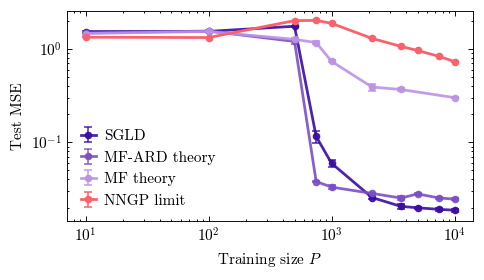

In [19]:
# testMSE_vs_P_three_sources.py
# Load (true NN from training_results.json) + (NN no-ARD) + (NNGP) for ONE kappa,
# then plot Test MSE vs P with **vertical error bars** (SEM) using your slim_plotters.py.
# Also prints mean±std of **test MSE** for each P so you can see scale when yerr is tiny.

from __future__ import annotations
from pathlib import Path
from typing import Dict, Any, List, Tuple, Optional
import json
import math
import numpy as np
import matplotlib.pyplot as plt
import sys, importlib.util

# ---------------- slim_plotters import (file or module) ----------------
def import_slim_plotters(slim_plotters_path: str | None = None):
    """
    Try to import `slim_plotters` as a normal module. If that fails:
      - If slim_plotters_path is a directory, use <dir>/slim_plotters.py
      - If it's a file, import exactly that file.
    Returns: (apply, color, SciencePlotter, PlotStyle)
    """
    try:
        from slim_plotters import apply, color, SciencePlotter, PlotStyle
        return apply, color, SciencePlotter, PlotStyle
    except Exception:
        pass  # fallback below

    if slim_plotters_path is None:
        raise ModuleNotFoundError("No module named 'slim_plotters' and no slim_plotters_path provided.")

    p = Path(slim_plotters_path).expanduser().resolve()
    if p.is_dir():
        p = p / "slim_plotters.py"
    if not p.exists():
        raise FileNotFoundError(f"slim_plotters.py not found at: {p}")

    # easiest: add its folder to sys.path then import
    sys.path.insert(0, str(p.parent))
    try:
        from slim_plotters import apply, color, SciencePlotter, PlotStyle
        return apply, color, SciencePlotter, PlotStyle
    except Exception:
        spec = importlib.util.spec_from_file_location("slim_plotters", str(p))
        if spec is None or spec.loader is None:
            raise ImportError(f"Could not load spec for: {p}")
        mod = importlib.util.module_from_spec(spec)
        spec.loader.exec_module(mod)
        sys.modules["slim_plotters"] = mod
        return mod.apply, mod.color, mod.SciencePlotter, mod.PlotStyle


# ============================ utilities ================================
def _fmt_float_key(x: float, ndigits: int = 8) -> str:
    return f"{float(x):.{ndigits}f}"

def _flatten_once(x):
    out = []
    if isinstance(x, list):
        for t in x:
            if isinstance(t, list):
                out.extend(t)
            else:
                out.append(t)
    else:
        out = [x]
    return out

def _mS_scalar_from_vector(v: List[float]) -> float:
    """
    Turn (possibly multi-mode) vector into scalar:
      - if 1 value -> that value
      - if multiple -> L2 norm across modes (comparable scalar)
    """
    if v is None:
        return float('nan')
    flat = [float(u) for u in _flatten_once(v)]
    if len(flat) == 0:
        return float('nan')
    if len(flat) == 1:
        return float(flat[0])
    return float(np.linalg.norm(flat))

def _infer_P_from_name(name: str) -> Optional[int]:
    # handles ..._P1000_... or ..._Ptr1000_...
    import re
    m = re.search(r"_P(\d+)_", name)
    if m:
        return int(m.group(1))
    m = re.search(r"_Ptr(\d+)_", name)
    if m:
        return int(m.group(1))
    return None

def _to_xy_keys(model_dict: Dict[int, Dict[str, float]],
                mean_key: str,
                sem_key: str) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Generic pull x=P, y=<mean_key>, e=<sem_key> arrays (sorted by P).
    """
    if not model_dict:
        return np.array([]), np.array([]), np.array([])
    P_sorted = sorted(model_dict.keys())
    x = np.array(P_sorted, dtype=float)
    y = np.array([model_dict[P].get(mean_key, np.nan) for P in P_sorted], dtype=float)
    e = np.array([model_dict[P].get(sem_key,  np.nan) for P in P_sorted], dtype=float)
    return x, y, e


# ======================== loaders: TRUE NN =============================
def build_summary_mse(results_path: str | Path,
                      kappa_ndigits: int = 8
                     ) -> Dict[int, Dict[str, Dict[int, Dict[str, float]]]]:
    """
    Replicates your notebook helper:
    summary[P][kappa_str][exp_id] = {"train_mse","test_mse","m_S"}
    """
    path = Path(results_path)
    with path.open("r") as f:
        data = json.load(f)
    if not isinstance(data, list):
        raise ValueError("Expected JSON list of records in training_results.json")
    summary: Dict[int, Dict[str, Dict[int, Dict[str, float]]]] = {}
    best_epochs: Dict[tuple, int] = {}
    for rec in data:
        P = int(rec["P"])
        kappa_key = _fmt_float_key(rec["kappa_0"], ndigits=kappa_ndigits)
        exp_id = int(rec["exp_id"])
        epochs_run = int(rec.get("epochs_run", -1))
        train_mse = float(rec["train_mse"])
        test_mse  = float(rec["test_mse"])
        if "final_eval_mS" in rec:
            m_s = float(rec["final_eval_mS"])
        elif "init_eval_mS" in rec:
            m_s = float(rec["init_eval_mS"])
        else:
            m_s = float("nan")
        key = (P, kappa_key, exp_id)
        if key in best_epochs and epochs_run <= best_epochs[key]:
            continue
        summary.setdefault(P, {}).setdefault(kappa_key, {})[exp_id] = {
            "train_mse": train_mse,
            "test_mse": test_mse,
            "m_S": m_s,
        }
        best_epochs[key] = epochs_run
    return summary

def agg_true_nn(summary: Dict[int, Dict[str, Dict[int, Dict[str, float]]]],
                kappa: float, kappa_ndigits: int = 8) -> Dict[int, Dict[str, float]]:
    """
    Aggregate ONE kappa across exp_id -> stats per P:
      returns {
        P: {
          "mS_mean","mS_sem",
          "test_mean","test_std","test_sem","n_exp"
        }
      }
    """
    kkey = _fmt_float_key(kappa, ndigits=kappa_ndigits)
    out: Dict[int, Dict[str, float]] = {}
    for P, kappas in summary.items():
        if kkey not in kappas:
            continue
        exps = kappas[kkey]
        mS_arr   = np.array([float(v["m_S"])      for v in exps.values() if np.isfinite(v["m_S"])], dtype=float)
        test_arr = np.array([float(v["test_mse"]) for v in exps.values() if np.isfinite(v["test_mse"])], dtype=float)

        if mS_arr.size == 0 and test_arr.size == 0:
            continue

        # m_S stats (kept for parity)
        if mS_arr.size:
            mS_mean = float(mS_arr.mean())
            mS_sem  = float(mS_arr.std(ddof=1)/np.sqrt(mS_arr.size)) if mS_arr.size > 1 else 0.0
        else:
            mS_mean, mS_sem = float("nan"), float("nan")

        # test mse stats
        if test_arr.size:
            t_mean = float(test_arr.mean())
            t_std  = float(test_arr.std(ddof=1)) if test_arr.size > 1 else 0.0
            t_sem  = float(t_std/np.sqrt(test_arr.size)) if test_arr.size > 1 else 0.0
            n_exp  = int(test_arr.size)
        else:
            t_mean, t_std, t_sem, n_exp = float("nan"), 0.0, float("nan"), 0

        out[int(P)] = {
            "mS_mean": mS_mean, "mS_sem": mS_sem,
            "test_mean": t_mean, "test_std": t_std, "test_sem": t_sem,
            "n_exp": n_exp
        }
    return out


# ========================= loaders: NNGP ===============================
def load_nngp_one_kappa(nngp_dir: str | Path, kappa: float) -> Dict[int, Dict[str, float]]:
    """
    Load NNGP JSONs and return {P: {"mS_mean","mS_sem","test_mean","test_std","test_sem","n_exp"}}
    Matches your notebook util:
      - test MSE: summary.final_eval.eval_mse_total
      - train MSE: summary.final_train.train_mse (unused for plot but harmless to read)
      - m_S: scalar via eval_mS_vec (single) or sqrt(eval_mS_norm2) (multi)
    If multiple files map to the same (P, κ), keep the one with lower test_mse,
    tie-breaking by lower 'resid_norm_last'.
    """
    def _pick_ms(final_eval: Dict[str, Any]) -> float:
        vec = final_eval.get("eval_mS_vec", [])
        if isinstance(vec, list) and len(vec) == 1:
            return float(vec[0])
        ms2 = final_eval.get("eval_mS_norm2", None)
        if ms2 is None:
            return float("nan")
        try:
            ms2f = float(ms2)
        except Exception:
            return float("nan")
        return math.sqrt(ms2f) if math.isfinite(ms2f) and ms2f >= 0 else float("nan")

    root = Path(nngp_dir)
    files = [p for p in root.glob("nngp_relu_composite_*.json") if p.name != "sweep_index.json"]

    # Keep best per (P, kappa_str): lower test_mse, tie-break on resid
    best: Dict[int, Tuple[float, float, Dict[str, float]]] = {}  # P -> (test_mse, resid, metrics)

    kkey_target = _fmt_float_key(kappa, ndigits=8)
    for fp in files:
        try:
            with fp.open("r") as f:
                obj = json.load(f)
        except Exception:
            continue

        summ = obj.get("summary", {})
        try:
            kkey = _fmt_float_key(float(summ["kappa"]), ndigits=8)
            if kkey != kkey_target:
                continue
        except Exception:
            continue

        try:
            P = int(summ["P_train"])
        except Exception:
            continue

        final_eval = summ.get("final_eval", {})
        final_train = summ.get("final_train", {})

        # --- pull metrics using your notebook schema
        test_mse = final_eval.get("eval_mse_total", None)
        if test_mse is None:
            # tolerate alternate key just in case
            test_mse = summ.get("test_mse", None)
        if test_mse is None:
            # if truly missing, skip this file (prevents NaNs and “n=0”)
            continue
        try:
            test_mse = float(test_mse)
        except Exception:
            continue

        m_S = _pick_ms(final_eval)

        # residual for tie-break
        resid = summ.get("resid_norm_last", float("inf"))
        try:
            resid = float(resid)
        except Exception:
            resid = float("inf")

        metrics = {
            "mS_mean": float(m_S),
            "mS_sem":  0.0,               # deterministic dump
            "test_mean": float(test_mse),
            "test_std":  0.0,
            "test_sem":  0.0,
            "n_exp":     1,
            # (optionally keep train if you want to inspect)
            "train_mse": float(final_train.get("train_mse", float("nan"))),
        }

        keep = False
        if P not in best:
            keep = True
        else:
            old_test, old_resid, _ = best[P]
            if (test_mse < old_test) or (math.isclose(test_mse, old_test) and resid < old_resid):
                keep = True
        if keep:
            best[P] = (test_mse, resid, metrics)

    # materialize output dict
    out: Dict[int, Dict[str, float]] = {}
    for P, (_, _, metrics) in best.items():
        out[int(P)] = {k: v for k, v in metrics.items() if k in
                       ("mS_mean", "mS_sem", "test_mean", "test_std", "test_sem", "n_exp")}
    return out


# ===================== loaders: NN (no-ARD / +ARD) ====================
def _choose_best_file_per_P(candidates: List[Path], kappa: float) -> Dict[int, Path]:
    """
    When multiple files exist for the same (P, κ), keep the one with lower test-MSE,
    tie-breaking on lower train-MSE. test-MSE ≈ 2 * last(traj.half_mse_empirical),
    with fallbacks to per-exp or test_mse_small.
    """
    best: Dict[int, Tuple[float, float, Path]] = {}  # P -> (test_mse, train_mse, path)
    for fp in candidates:
        try:
            with fp.open("r") as f:
                obj = json.load(f)
        except Exception:
            continue
        cfg = obj.get("config", {})
        k = float(cfg.get("kappa", "nan"))
        if not np.isfinite(k) or abs(k - float(kappa)) > 1e-15:
            continue
        P = _infer_P_from_name(fp.name)
        if P is None:
            continue

        traj = obj.get("traj", {})
        train = float(traj.get("train_mse", [float('inf')])[-1]) if traj.get("train_mse") else float('inf')

        # derive test mse
        if isinstance(traj.get("half_mse_empirical"), list) and traj["half_mse_empirical"]:
            test = 2.0 * float(traj["half_mse_empirical"][-1])
        elif isinstance(traj.get("half_mse_empirical_per_exp"), list) and traj["half_mse_empirical_per_exp"] and isinstance(traj["half_mse_empirical_per_exp"][-1], list):
            test = 2.0 * float(np.mean(traj["half_mse_empirical_per_exp"][-1]))
        else:
            test = float(traj.get("test_mse_small", [float('inf')])[-1])

        keep = False
        if P not in best:
            keep = True
        else:
            old_test, old_train, _ = best[P]
            if (test < old_test) or (math.isclose(test, old_test) and train < old_train):
                keep = True
        if keep:
            best[P] = (float(test), float(train), fp)
    return {P: path for P, (_, _, path) in best.items()}

def load_sgld_one_kappa(root_dir: str | Path, kappa: float) -> Dict[int, Dict[str, float]]:
    """
    Recursively scan root for rs_aw_ard_sgld_FAST_*.json with this κ.
    Choose best file per P. From the chosen file, compute per-exp stats at final step:
      - m_S: L2 across modes, then mean/SEM across E (kept for parity)
      - test MSE: 2 * half_mse_empirical_per_exp (if available), then mean/std/SEM across E
    Returns { P: {"mS_mean","mS_sem","test_mean","test_std","test_sem","n_exp"} }.
    """
    root = Path(root_dir)
    files = list(root.rglob("rs_aw_ard_sgld_FAST_*.json"))
    chosen = _choose_best_file_per_P(files, kappa)

    results: Dict[int, Dict[str, float]] = {}
    for P, fp in chosen.items():
        try:
            with fp.open("r") as f:
                obj = json.load(f)
        except Exception:
            continue
        traj = obj.get("traj", {})

        # ---- m_S per-exp array (final, optional)
        mS_per_exp = []
        mS_pe_list = traj.get("m_S_per_exp")
        if isinstance(mS_pe_list, list) and mS_pe_list and isinstance(mS_pe_list[-1], list):
            for exp_item in mS_pe_list[-1]:
                flat = [float(u) for u in _flatten_once(exp_item)]
                if len(flat) == 0:
                    mS_per_exp.append(float('nan'))
                elif len(flat) == 1:
                    mS_per_exp.append(float(flat[0]))
                else:
                    mS_per_exp.append(float(np.linalg.norm(flat)))
        else:
            mS_vec_list = traj.get("m_S", [])
            mS_scalar = _mS_scalar_from_vector(mS_vec_list[-1]) if mS_vec_list else float('nan')
            mS_per_exp = [mS_scalar]

        mS_arr = np.array([v for v in mS_per_exp if np.isfinite(v)], dtype=float)
        if mS_arr.size > 0:
            mS_mean = float(mS_arr.mean())
            mS_sem  = float(mS_arr.std(ddof=1) / np.sqrt(mS_arr.size)) if mS_arr.size > 1 else 0.0
        else:
            mS_mean, mS_sem = float('nan'), float('nan')

        # ---- test MSE per-exp (if available)
        test_arr = None
        hmse_pe = traj.get("half_mse_empirical_per_exp")
        if isinstance(hmse_pe, list) and hmse_pe and isinstance(hmse_pe[-1], list):
            test_arr = 2.0 * np.array([float(x) for x in hmse_pe[-1]], dtype=float)
        elif isinstance(traj.get("half_mse_empirical"), list) and traj["half_mse_empirical"]:
            test_arr = np.array([2.0 * float(traj["half_mse_empirical"][-1])], dtype=float)
        elif isinstance(traj.get("test_mse_small"), list) and traj["test_mse_small"]:
            test_arr = np.array([float(traj["test_mse_small"][-1])], dtype=float)

        if test_arr is not None and test_arr.size:
            test_arr = test_arr[np.isfinite(test_arr)]
            n_exp = int(test_arr.size)
            test_mean = float(np.nanmean(test_arr)) if n_exp else float('nan')
            test_std  = float(np.nanstd(test_arr, ddof=1)) if n_exp > 1 else 0.0
            test_sem  = float(test_std/np.sqrt(n_exp)) if n_exp > 1 else 0.0
        else:
            test_mean, test_std, test_sem, n_exp = float('nan'), 0.0, float('nan'), 0

        results[int(P)] = {
            "mS_mean": mS_mean, "mS_sem": mS_sem,
            "test_mean": test_mean, "test_std": test_std, "test_sem": test_sem,
            "n_exp": n_exp
        }
    return results


# ============================== printing ===============================
def _print_series_stats(label: str, series: Dict[int, Dict[str, float]]):
    if not series:
        print(f"[{label}] (no data)")
        return
    print(f"\n[{label}]  P  |   Test MSE (mean±std)   |   n")
    for P in sorted(series.keys()):
        s = series[P]
        t_mean = s.get("test_mean", float('nan'))
        t_std  = s.get("test_std",  0.0)
        n_exp  = int(s.get("n_exp", 0))
        print(f"  P={P:<6d}  {t_mean:.6g} ± {t_std:.6g}    |   {n_exp}")


# ============================== plotting ===============================
def _normalize_color(c):
    """
    Accept hex '#RRGGBB', RGB tuple in [0,1] or [0,255], or named mpl color.
    Returns something matplotlib can use.
    """
    if isinstance(c, tuple) and len(c) == 3:
        if max(c) > 1.0:
            return tuple([v/255.0 for v in c])
        return c
    return c  # hex or name

def plot_testMSE_vs_P_with_errorbars(
    *,
    kappa: float,
    true_nn_results_json: str | Path,
    sgld_noard_root: str | Path,
    nngp_dir: str | Path,
    # ---- NEW: optional 4th series (e.g., ARD=4) ----
    sgld_alt_root: Optional[str | Path] = None,

    slim_plotters_path: Optional[str] = None,
    theme: str = "light",

    # ----- layout controls -----
    fig_width: float = 3.6,
    aspect: float = 1.35,          # width / height
    ylog: bool = False,

    # ----- legend & labels -----
    legend_loc: str = "lower right",
    legend_title: Optional[str] = None,
    xlabel: str = r"Training size $P$",
    ylabel: str = r"Test MSE",
    title: Optional[str] = None,   # None => no title

    # ----- colors (hex or RGB tuples) -----
    color_true_nn = "#FFB463",     # orange
    color_no_ard  = "#d1001d",     # red
    color_nngp    = "#01B5EB",     # blue
    # ---- NEW: color for 4th series ----
    color_alt     = "#2ec4b6",     # teal-ish

    # ----- labels (so you can rename legend entries) -----
    label_true_nn: str = "SGLD",
    label_no_ard:  str = "MF theory",
    label_nngp:    str = "NNGP limit",
    # ---- NEW: label for 4th series ----
    label_alt:     str = "NN (+ARD)",

    # ----- errorbar / line style -----
    capsize: float = 2.5,
    elinewidth: float = 1.0,
    ealpha: float = 0.9,
    markersize: float = 4.0,
    linewidth: float = 1.8,

    # ----- print stats -----
    print_stats: bool = True,
):
    # import style & apply theme
    apply, color, SciencePlotter, PlotStyle = import_slim_plotters(slim_plotters_path)
    apply(theme=theme)

    # 1) TRUE NN
    nn_summary = build_summary_mse(true_nn_results_json)
    nn_true = agg_true_nn(nn_summary, kappa=kappa)

    # 2) NN no-ARD (SGLD)
    nn_noard = load_sgld_one_kappa(sgld_noard_root, kappa)

    # 3) NNGP
    nngp = load_nngp_one_kappa(nngp_dir, kappa)

    # 4) Optional extra SGLD series (e.g., ARD=4)
    nn_alt = {}
    if sgld_alt_root is not None:
        nn_alt = load_sgld_one_kappa(sgld_alt_root, kappa)

    # optionally print stats to console (mean±std; error bars use SEM)
    if print_stats:
        print(f"\n=== κ = {kappa:g} ===")
        _print_series_stats("NN (true)",    nn_true)
        _print_series_stats("NN (no ARD)",  nn_noard)
        _print_series_stats("NNGP (ReLU)",  nngp)
        if nn_alt:
            _print_series_stats("NN (alt)", nn_alt)

    # arrays (use mean=test_mean, err=test_sem)
    x1, y1, e1 = _to_xy_keys(nn_true,  mean_key="test_mean", sem_key="test_sem")
    x2, y2, e2 = _to_xy_keys(nn_noard, mean_key="test_mean", sem_key="test_sem")
    x3, y3, e3 = _to_xy_keys(nngp,     mean_key="test_mean", sem_key="test_sem")
    x4, y4, e4 = _to_xy_keys(nn_alt,   mean_key="test_mean", sem_key="test_sem") if nn_alt else (np.array([]),)*3

    # figure size from width & aspect
    fig_h = max(1e-6, fig_width / float(aspect))
    fig, ax = plt.subplots(figsize=(fig_width, fig_h))

    # prepare colors
    c1 = _normalize_color(color_true_nn)
    c2 = _normalize_color(color_no_ard)
    c3 = _normalize_color(color_nngp)
    c4 = _normalize_color(color_alt)

    # plot with **vertical** error bars only (SEM on test MSE)
    if x1.size:
        ax.errorbar(x1, y1, yerr=e1, fmt='o-', color=c1, ms=markersize, lw=linewidth,
                    capsize=capsize, elinewidth=elinewidth, alpha=ealpha, label=label_true_nn, zorder=3)
    

    if x4.size:
        ax.errorbar(x4, y4, yerr=e4, fmt='o-', color=c4, ms=markersize, lw=linewidth,
                    capsize=capsize, elinewidth=elinewidth, alpha=ealpha, label=label_alt, zorder=3)

    if x2.size:
        ax.errorbar(x2, y2, yerr=e2, fmt='o-', color=c2, ms=markersize, lw=linewidth,
                    capsize=capsize, elinewidth=elinewidth, alpha=ealpha, label=label_no_ard, zorder=3)
    
    
    if x3.size:
        ax.errorbar(x3, y3, yerr=e3, fmt='o-', color=c3, ms=markersize, lw=linewidth,
                    capsize=capsize, elinewidth=elinewidth, alpha=elinewidth, label=label_nngp, zorder=3)

    # axes
    ax.set_xscale("log")
    if ylog:
        ax.set_yscale("log")
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

    # legend
    leg = ax.legend(loc=legend_loc, frameon=False)
    if legend_title is not None and leg is not None:
        leg.set_title(legend_title)

    # optional title (off by default)
    if title:
        ax.set_title(title, pad=6)

    ax.grid(False)
    plt.tight_layout()
    fig.savefig("/home/goring/mean_field_langevin/plots/plots/generror3.svg", bbox_inches="tight")

    return fig, {"nn_true": nn_true, "nn_noard": nn_noard, "nngp": nngp, "nn_alt": nn_alt}



if __name__ == "__main__":
    SLIM_PLOTTERS_FILE = "/home/goring/mean_field_langevin/plots_utils/slim_plotters.py"

    KAPPA = 5e-3
    TRUE_NN_RESULTS = "/home/goring/mean_field_langevin/Langevin_training/results_paper1/d35_k4_lrdecay_5e-3test2/d35_k4/training_results.json"

    NO_ARD_ROOT = "/home/goring/mean_field_langevin/MCMC_composite/results_d35k4hm_paper_final_conv2_long_fin_noard_fix"
    NNGP_DIR    = "/home/goring/mean_field_langevin/MCMC_composite/results_NNGP/d35_k4_5e-3_paper"

    # your existing ARD=4-type folder (or any other alt SGLD family)
    ALT_ROOT = "/home/goring/mean_field_langevin/MCMC_composite/results_d35k4hm_paper_final_ard=4_fin/5e-3"

    fig, data = plot_testMSE_vs_P_with_errorbars(
        kappa=KAPPA,
        true_nn_results_json=TRUE_NN_RESULTS,
        sgld_noard_root=NO_ARD_ROOT,
        nngp_dir=NNGP_DIR,
        # ---- pass the 4th dataset path here ----
        sgld_alt_root=ALT_ROOT,
        slim_plotters_path=SLIM_PLOTTERS_FILE,

        # layout
        theme="light",
        fig_width=4.5,
        aspect=1.7,
        ylog=True,

        # legend / labels (customize freely)
        legend_loc="lower left",
        legend_title="",
        label_true_nn="SGLD",
        label_no_ard="MF theory",
        label_nngp="NNGP limit",
        label_alt="MF-ARD theory",

        # colors — customize all four
        # color_true_nn="#00BFA6",
        # color_no_ard ="#a37cf0",
        # color_nngp   ="#F9626C",
        # color_alt    ="#3A0CA3",  #00BFA6 3A0CA3


        color_true_nn="#3A0CA3",
        color_no_ard ="#BC92E5",
        color_nngp   ="#F9626C",
        color_alt    ="#7B4FC4",  #00BFA6 3A
        # errorbar style
        capsize=2.5,
        elinewidth=1.0,
        ealpha=0.9,
        markersize=4.0,
        linewidth=1.8,

        # labels
        xlabel=r"Training size $P$",
        ylabel=r"Test MSE",
        title=None,

        # print per-P MSE stats to stdout (mean±std)
        print_stats=True,
    )

    out_path = f"testMSE_vs_P_kappa_{KAPPA:g}_errbars.png"
    fig.savefig(out_path, dpi=300, bbox_inches="tight")
    print(f"\n[saved] {out_path}")
    plt.show()



/tmp/ipykernel_2278977/1662920537.py:261: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()
/home/goring/miniconda3/envs/env_jax_new/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 183 (\N{MIDDLE DOT}) missing from font(s) cmr10.
  fig.canvas.print_figure(bytes_io, **kw)


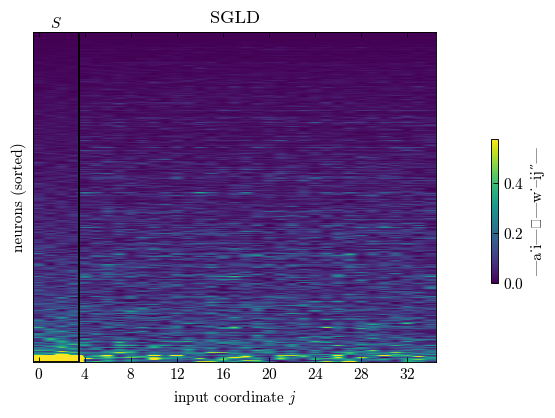

In [19]:
# =========================
# Row-sorted |W| maps (neurons × input-coords)
# =========================
import os, glob, math
import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# ---------- Loading helpers ----------
def find_latest_model(model_dir, prefix="final_model_", ext=".pt"):
    files = glob.glob(os.path.join(model_dir, f"{prefix}*{ext}"))
    if not files:
        raise FileNotFoundError(f"No {prefix}*{ext} files found in: {model_dir}")
    files.sort(key=os.path.getmtime)
    return files[-1]

def load_WA_from_state_dict(path, map_location="cpu"):
    """
    Loads a state_dict and returns (W, a) as CPU tensors.
    Expects W shape (d, N), a shape (N,) or (N,1).
    """
    sd = torch.load(path, map_location=map_location)
    if isinstance(sd, dict) and 'w' in sd and 'a' in sd:
        W = sd['w'].detach().cpu()
        a = sd['a'].detach().cpu()
    elif isinstance(sd, dict) and 'state_dict' in sd:
        st = sd['state_dict']
        W = st['w'].detach().cpu()
        a = st['a'].detach().cpu()
    else:
        keys = list(sd.keys())
        key_w = next(k for k in keys if k.endswith('w') and sd[k].ndim == 2)
        key_a = next(k for k in keys if k.endswith('a') and sd[k].ndim >= 1)
        W = sd[key_w].detach().cpu()
        a = sd[key_a].detach().cpu()
    if a.ndim > 1:
        a = a.view(-1)
    return W, a

# ---------- Small utils ----------
def _as_sorted_unique_ints(idx_like):
    """Accepts list/tuple/set/np array of indices; returns sorted unique np.int64 array."""
    arr = np.array(list(idx_like), dtype=np.int64).ravel()
    arr = np.unique(arr)
    return arr

def _contiguous_runs(idxs):
    """Given sorted unique ints, yield (start, end) inclusive runs."""
    if len(idxs) == 0:
        return []
    runs = []
    start = prev = int(idxs[0])
    for v in idxs[1:]:
        v = int(v)
        if v == prev + 1:
            prev = v
            continue
        runs.append((start, prev))
        start = prev = v
    runs.append((start, prev))
    return runs

# ---------- Core scoring ----------
def neuron_scores(W_np, a_np, S, score="abs-sum"):
    """
    Compute specialization scores s_i to sort neurons (columns of W).
    W_np: (d, N)
    a_np: (N,)
    S: iterable of column indices (input coords) in teacher support
    score:
      - 'abs-sum' : s_i = |a_i| * sum_{j in S} |w_{ji}|
      - 'signed-sum' : s_i = |a_i * sum_{j in S} w_{ji}|
      - 'l2' : s_i = |a_i| * sqrt( sum_{j in S} w_{ji}^2 )
      - 'a-only' : s_i = |a_i|
    Returns s: (N,)
    """
    d, N = W_np.shape
    S_idx = _as_sorted_unique_ints(S)
    S_idx = S_idx[(S_idx >= 0) & (S_idx < d)]
    if S_idx.size == 0:
        # fall back to |a_i|
        return np.abs(a_np)

    WS = W_np[S_idx, :]  # (|S|, N)
    if score == "abs-sum":
        s = np.abs(a_np) * np.sum(np.abs(WS), axis=0)
    elif score == "signed-sum":
        s = np.abs(a_np * np.sum(WS, axis=0))
    elif score == "l2":
        s = np.abs(a_np) * np.sqrt(np.sum(WS * WS, axis=0))
    elif score == "a-only":
        s = np.abs(a_np)
    else:
        raise ValueError(f"Unknown score='{score}'")
    return s

# ---------- Plotting ----------
def plot_row_sorted_W_map(W, a, S, *,
                          title=None,
                          use_ai_weight=True,
                          score="abs-sum",
                          vmax_percentile=99.5,
                          cmap="viridis",
                          draw_bracket=True,
                          show_colorbar=False,
                          ax=None):
    """
    Make a single panel of the row-sorted |W| (or |a_i|*|W|) map.
    Rows = neurons i (sorted by s_i desc), Columns = input coords j.
    A vertical bracket highlights S.
    """
    # Ensure numpy
    W_np = W.detach().cpu().numpy() if torch.is_tensor(W) else np.asarray(W)
    a_np = a.detach().cpu().numpy() if torch.is_tensor(a) else np.asarray(a)
    if a_np.ndim > 1:
        a_np = a_np.reshape(-1)

    d, N = W_np.shape
    # Matrix to display: |W^T| or |a|*|W^T|
    M = np.abs(W_np.T)  # (N, d)
    if use_ai_weight:
        M = (np.abs(a_np)[:, None]) * M

    # Sort rows by specialization score
    s = neuron_scores(W_np, a_np, S, score=score)  # (N,)
    order = np.argsort(-s)  # descending
    M_sorted = M[order, :]

    # Choose display scaling
    vmax = np.percentile(M_sorted, vmax_percentile) if M_sorted.size else 1.0
    if vmax <= 0 or not np.isfinite(vmax):
        vmax = 1.0

    # Create axis if needed
    created_fig = False
    if ax is None:
        created_fig = True
        plt.figure(figsize=(4.2, 4.2))
        ax = plt.gca()

    im = ax.imshow(M_sorted, origin="lower", aspect="auto", vmin=0.0, vmax=vmax, cmap=cmap)
    if title:
        ax.set_title(title)
    ax.set_xlabel("input coordinate $j$")
    ax.set_ylabel("neurons (sorted)")

    # Ticks (kept light)
    ax.set_xticks(np.arange(0, d, max(1, d // 8)))
    ax.set_yticks([])

    # Draw bracket/boxes over S
    if draw_bracket:
        S_idx = _as_sorted_unique_ints(S)
        S_idx = S_idx[(S_idx >= 0) & (S_idx < d)]
        for (j0, j1) in _contiguous_runs(S_idx):
            # Rectangle spans all rows (0..N-1) and columns j0..j1
            rect = Rectangle((j0 - 0.5, -0.5),
                             width=(j1 - j0 + 1),
                             height=M_sorted.shape[0],
                             fill=False, linewidth=1.2)
            ax.add_patch(rect)
        if S_idx.size > 0:
            ax.text(np.mean(S_idx), M_sorted.shape[0] + 2, "$S$",
                    ha="center", va="bottom", fontsize=10)

    if show_colorbar and created_fig:
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    if created_fig:
        plt.tight_layout()
        plt.show()

    return ax, im

def plot_models_row_sorted_W_maps(model_specs, S, *,
                                  score="abs-sum",
                                  use_ai_weight=True,
                                  vmax_mode="global",  # 'global' or 'per-panel'
                                  vmax_percentile=99.5,
                                  ncols=None,
                                  figsize_per_panel=(4.2, 4.2),
                                  cmap="viridis",
                                  savefig=None,
                                  show=True):
    """
    model_specs: list of dicts, each with:
      {
        "title": "SGLD", 
        "path": "/path/to/model.pt"
      }
    S: iterable of input-coordinate indices for the teacher support
    score: how to sort neurons (see neuron_scores)
    use_ai_weight: multiply rows by |a_i| if True
    vmax_mode: 'global' => same color scale across panels (recommended);
               'per-panel' => each panel scaled independently
    """
    # Load all models
    data = []
    for spec in model_specs:
        W, a = load_WA_from_state_dict(spec["path"])
        data.append({"title": spec.get("title", os.path.basename(spec["path"])),
                     "W": W, "a": a})

    # Compute global vmax if requested
    global_vmax = None
    if vmax_mode == "global":
        vals = []
        for item in data:
            W_np = item["W"].detach().cpu().numpy()
            a_np = item["a"].detach().cpu().numpy().reshape(-1)
            M = np.abs(W_np.T)
            if use_ai_weight:
                M = (np.abs(a_np)[:, None]) * M
            vals.append(M.ravel())
        all_vals = np.concatenate(vals) if vals else np.array([1.0])
        global_vmax = np.percentile(all_vals, vmax_percentile)
        if not np.isfinite(global_vmax) or global_vmax <= 0:
            global_vmax = 1.0

    # Layout
    K = len(data)
    if ncols is None:
        ncols = min(K, 4)
    nrows = int(np.ceil(K / ncols))
    fig_w = figsize_per_panel[0] * ncols
    fig_h = figsize_per_panel[1] * nrows
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(fig_w, fig_h),
                             squeeze=False)
    axes = axes.ravel()

    # Plot each
    ims = []
    for ax, item in zip(axes, data):
        vmax = global_vmax if vmax_mode == "global" else None
        # If per-panel, we compute inside the helper; otherwise pass shared vmax.
        # To pass shared vmax we’ll set it right after getting the AxesImage.
        ax, im = plot_row_sorted_W_map(item["W"], item["a"], S,
                                       title=item["title"],
                                       use_ai_weight=use_ai_weight,
                                       score=score,
                                       vmax_percentile=vmax_percentile if vmax is None else 100,  # dummy if using shared
                                       cmap=cmap,
                                       draw_bracket=True,
                                       show_colorbar=False,
                                       ax=ax)
        if vmax is not None:
            im.set_clim(0.0, vmax)
        ims.append(im)

    # Remove empty axes if any
    for k in range(K, len(axes)):
        fig.delaxes(axes[k])

    # Optional single shared colorbar (nice for 'global' vmax)
    if vmax_mode == "global":
        cbar = fig.colorbar(ims[0], ax=[ax for ax in axes[:K]],
                            fraction=0.025, pad=0.02)
        cbar.set_label("|a_i|·|w_{ij}|" if use_ai_weight else "|w_{ij}|")

    fig.tight_layout()
    if savefig:
        fig.savefig(savefig, dpi=200, bbox_inches="tight")
    if show:
        plt.show()
    return fig

# =========================
# ==== Example usage ======
# =========================
if __name__ == "__main__":
    # Define teacher support S (0-based indices). Example: first four coords {0,1,2,3}.
    S = [0, 1, 2, 3]

    # Point to your model files (one per theory).
    # Replace with your paths; titles appear above each thumbnail.
    model_specs = [
        #{"title": "NNGP (ref)",   "path": "/path/to/nngp_model.pt"},
        #{"title": "MF",           "path": "/path/to/mf_model.pt"},
        #{"title": "MF-ARD",       "path": "/path/to/mf_ard_model.pt"},
        {"title": "SGLD",         "path": "/home/goring/mean_field_langevin/Langevin_training/results_paper1/d35_k4_lrdecay_5e-3test2/d35_k4/final_model_P_10000_d_35_k_4_exp_2_kappa_0.005000_eta0_2.000000e-03_etaf_5.000000e-04_gamma_0.500000.pt"},
    ]

    # If you only have one file right now, you can test with a single-entry list.

    # Plot 3–4 side-by-side thumbnails, globally matched color scale
    plot_models_row_sorted_W_maps(
        model_specs=model_specs,
        S=S,
        score="abs-sum",          # 'abs-sum' | 'signed-sum' | 'l2' | 'a-only'
        use_ai_weight=True,       # True => pixels are |a_i|·|w_{ij}|
        vmax_mode="global",       # shared color scaling across panels
        vmax_percentile=99.5,     # robust upper clipping
        ncols=4,                  # up to 4 across
        figsize_per_panel=(3.9, 3.9),
        cmap="viridis",
        savefig=None,             # e.g. "row_sorted_W_maps.png"
        show=True
    )


Loading: /home/goring/mean_field_langevin/Langevin_training/results_paper1/d35_k4_lrdecay_5e-3test2/d35_k4/final_model_P_10000_d_35_k_4_exp_2_kappa_0.005000_eta0_2.000000e-03_etaf_5.000000e-04_gamma_0.500000.pt
W: (35, 512) | a: (512,)


/tmp/ipykernel_2278977/1297695210.py:98: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  norm, cmap = Normalize(0.0, vmax), get_cmap("viridis")


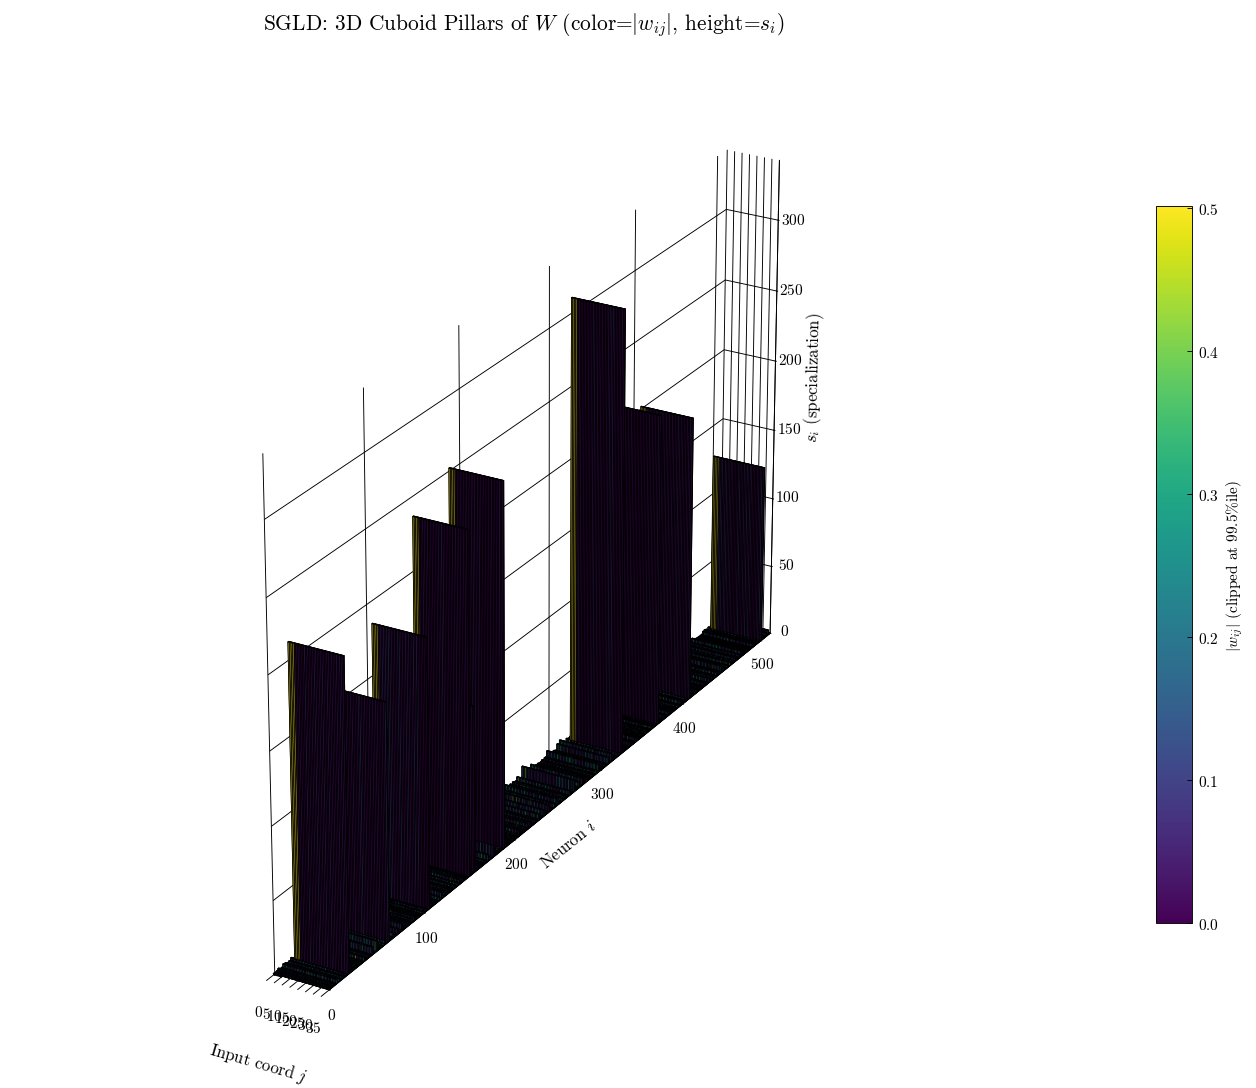

In [55]:
# --- 3D cuboid pillars: proper rectangular blocks for each weight (i,j) ----
import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.cm import get_cmap, ScalarMappable
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

def load_WA_from_state_dict(path, map_location="cpu"):
    sd = torch.load(path, map_location=map_location)
    if isinstance(sd, dict) and 'w' in sd and 'a' in sd:
        W, a = sd['w'].detach().cpu(), sd['a'].detach().cpu()
    elif isinstance(sd, dict) and 'state_dict' in sd:
        st = sd['state_dict']; W, a = st['w'].detach().cpu(), st['a'].detach().cpu()
    else:
        keys = list(sd.keys())
        key_w = next(k for k in keys if k.endswith('w') and sd[k].ndim == 2)
        key_a = next(k for k in keys if k.endswith('a') and sd[k].ndim >= 1)
        W, a = sd[key_w].detach().cpu(), sd[key_a].detach().cpu()
    if a.ndim > 1: a = a.view(-1)
    return W, a

def _sorted_unique_ints(idxs, lo=0, hi=None):
    arr = np.array(list(idxs), dtype=np.int64).ravel()
    if hi is not None: arr = arr[(arr >= lo) & (arr < hi)]
    else:              arr = arr[(arr >= lo)]
    return np.unique(arr)

def neuron_specialization_scores(W_np, a_np, S, mode="abs-sum"):
    d, N = W_np.shape
    S_idx = _sorted_unique_ints(S, lo=0, hi=d)
    if S_idx.size == 0: return np.abs(a_np)
    WS = W_np[S_idx, :]
    if mode == "abs-sum":   return np.abs(a_np) * np.sum(np.abs(WS), axis=0)
    if mode == "signed-sum":return np.abs(a_np * np.sum(WS, axis=0))
    if mode == "l2":        return np.abs(a_np) * np.sqrt(np.sum(WS*WS, axis=0))
    if mode == "a-only":    return np.abs(a_np)
    raise ValueError("unknown mode")

def create_cuboid(x0, y0, z0, dx, dy, dz):
    """Create vertices for a cuboid."""
    # Define the 8 vertices of a cuboid
    vertices = [
        [x0, y0, z0],
        [x0 + dx, y0, z0],
        [x0 + dx, y0 + dy, z0],
        [x0, y0 + dy, z0],
        [x0, y0, z0 + dz],
        [x0 + dx, y0, z0 + dz],
        [x0 + dx, y0 + dy, z0 + dz],
        [x0, y0 + dy, z0 + dz]
    ]
    
    # Define the 6 faces of the cuboid
    faces = [
        [vertices[0], vertices[1], vertices[5], vertices[4]],  # front
        [vertices[2], vertices[3], vertices[7], vertices[6]],  # back
        [vertices[0], vertices[3], vertices[7], vertices[4]],  # left
        [vertices[1], vertices[2], vertices[6], vertices[5]],  # right
        [vertices[0], vertices[1], vertices[2], vertices[3]],  # bottom
        [vertices[4], vertices[5], vertices[6], vertices[7]]   # top
    ]
    
    return faces

def plot_W_cuboids_3d(
    W, a, S,
    *,
    spec_mode="abs-sum",
    height_percentile=99.0,     # robust normalization for s_i
    height_scale=150.0,         # global height multiplier
    alpha=0.85,                 # opacity of cuboids
    vmax_percentile=99.5,       # clip |w_ij| for colors
    width_frac_x=0.8,          # cuboid width as fraction of cell (x)
    width_frac_y=0.8,          # cuboid width as fraction of cell (y)
    edgecolor='black',
    linewidth=0.5,
    elev=25, azim=-60,         # camera angles
    figsize=(14, 10),
    downsample_rows=1,          # >1 to render faster
    downsample_cols=1,
    savefig=None, show=True
):
    # arrays
    W_np = W.detach().cpu().numpy() if torch.is_tensor(W) else np.asarray(W)
    a_np = a.detach().cpu().numpy() if torch.is_tensor(a) else np.asarray(a).reshape(-1)
    d, N = W_np.shape
    absW = np.abs(W_np)

    # row heights (specialization)
    s = neuron_specialization_scores(W_np, a_np, S, mode=spec_mode)
    denom = max(np.percentile(s, height_percentile), 1e-12)
    z_heights = height_scale * (s / denom)

    # colors from |w_ij|
    vmax = np.percentile(absW, vmax_percentile) if absW.size else 1.0
    if not np.isfinite(vmax) or vmax <= 0: vmax = 1.0
    norm, cmap = Normalize(0.0, vmax), get_cmap("viridis")

    # cuboid dimensions
    dx = float(width_frac_x)
    dy = float(width_frac_y)

    js = np.arange(d)[::max(1, int(downsample_cols))]
    is_ = np.arange(N)[::max(1, int(downsample_rows))]

    fig = plt.figure(figsize=figsize)
    ax = fig.add_subplot(111, projection='3d')
    ax.view_init(elev=elev, azim=azim)

    # Create all cuboids
    all_faces = []
    face_colors = []
    
    for i in is_:
        z = float(z_heights[i])
        if z < 0.01: continue  # Skip very small pillars
        
        y0 = i + (1.0 - dy)/2  # Center the cuboid in the cell
        for j in js:
            x0 = j + (1.0 - dx)/2  # Center the cuboid in the cell
            
            # Create cuboid faces
            faces = create_cuboid(x0, y0, 0, dx, dy, z)
            all_faces.extend(faces)
            
            # Get color for this weight
            rgba = list(cmap(norm(absW[j, i])))
            rgba[3] = alpha
            
            # Add color for each face (6 faces per cuboid)
            for _ in range(6):
                face_colors.append(rgba)
    
    # Create the collection of all cuboids
    cuboid_collection = Poly3DCollection(all_faces, 
                                        facecolors=face_colors,
                                        edgecolors=edgecolor,
                                        linewidths=linewidth)
    ax.add_collection3d(cuboid_collection)

    # Clean background
    ax.xaxis.pane.set_visible(False)
    ax.yaxis.pane.set_visible(False)
    ax.zaxis.pane.set_visible(False)
    ax.grid(True, alpha=0.3)
    
    # Set limits
    ax.set_xlim(0, d)
    ax.set_ylim(0, N)
    ax.set_zlim(0, max(z_heights) * 1.1)
    
    # Adjust aspect ratio for long plots
    if N > 100:
        ax.set_box_aspect([d/35, N/35, max(z_heights)/35])

    # Labels
    ax.set_title(r"SGLD: 3D Cuboid Pillars of $W$ (color=$|w_{ij}|$, height=$s_i$)", 
                 fontsize=14, pad=15)
    ax.set_xlabel("Input coord $j$", fontsize=11, labelpad=10)
    ax.set_ylabel("Neuron $i$", fontsize=11, labelpad=10)
    ax.set_zlabel(r"$s_i$ (specialization)", fontsize=11, labelpad=10)

    # Add ground plane grid
    xx, yy = np.meshgrid(np.linspace(0, d, 2), np.linspace(0, N, 2))
    ax.plot_surface(xx, yy, np.zeros_like(xx), alpha=0.1, color='gray')

    # Highlight S region with a bracket on the ground
    S_idx = _sorted_unique_ints(S, lo=0, hi=d)
    if S_idx.size:
        j0, j1 = int(S_idx.min()), int(S_idx.max())
        # Draw bracket
        bracket_z = 0
        ax.plot([j0, j0], [0, N], [bracket_z, bracket_z], 'k-', linewidth=2)
        ax.plot([j1+1, j1+1], [0, N], [bracket_z, bracket_z], 'k-', linewidth=2)
        ax.plot([j0, j1+1], [0, 0], [bracket_z, bracket_z], 'k-', linewidth=2)
        ax.plot([j0, j1+1], [N, N], [bracket_z, bracket_z], 'k-', linewidth=2)
        
        # Add S label
        ax.text((j0+j1+1)/2.0, N + N*0.02, 0, "S", ha="center", va="bottom", 
                fontsize=12, fontweight='bold')

    # Colorbar
    sm = ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, shrink=0.7, pad=0.08)
    cbar.set_label(r"$|w_{{ij}}|$ (clipped at {}%ile)".format(vmax_percentile), 
                   fontsize=10)

    plt.tight_layout()
    if savefig: 
        fig.savefig(savefig, dpi=300, bbox_inches="tight", facecolor='white')
    if show: 
        plt.show()
    return fig, ax

# --- Example usage -----------------------------------------------------------
if __name__ == "__main__":
    MODEL_FILE = "/home/goring/mean_field_langevin/Langevin_training/results_paper1/d35_k4_lrdecay_5e-3test2/d35_k4/final_model_P_10000_d_35_k_4_exp_2_kappa_0.005000_eta0_2.000000e-03_etaf_5.000000e-04_gamma_0.500000.pt"
    S = [0, 1, 2, 3]

    print("Loading:", MODEL_FILE)
    W, a = load_WA_from_state_dict(MODEL_FILE)
    print(f"W: {tuple(W.shape)} | a: {tuple(a.shape)}")

    plot_W_cuboids_3d(
        W, a, S,
        spec_mode="abs-sum",
        height_percentile=99.0,
        height_scale=200.0,
        alpha=0.85,           # More opaque for better visibility
        vmax_percentile=99.5,
        width_frac_x=0.8,     # Larger blocks for clearer cuboid look
        width_frac_y=0.8,
        edgecolor='black',    # Clear black edges
        linewidth=0.5,        # Visible edges
        elev=25, azim=-60,
        figsize=(14, 10),
        downsample_rows=1,
        downsample_cols=1,
        savefig=None, 
        show=True
    )

Loading: /home/goring/mean_field_langevin/Langevin_training/results_paper1/d35_k4_lrdecay_5e-3test2/d35_k4/final_model_P_10000_d_35_k_4_exp_2_kappa_0.005000_eta0_2.000000e-03_etaf_5.000000e-04_gamma_0.500000.pt
W: (35, 512) | a: (512,)


/tmp/ipykernel_2278977/598293190.py:106: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  norm, cmap = Normalize(0.0, vmax), get_cmap("inferno")
/tmp/ipykernel_2278977/598293190.py:185: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


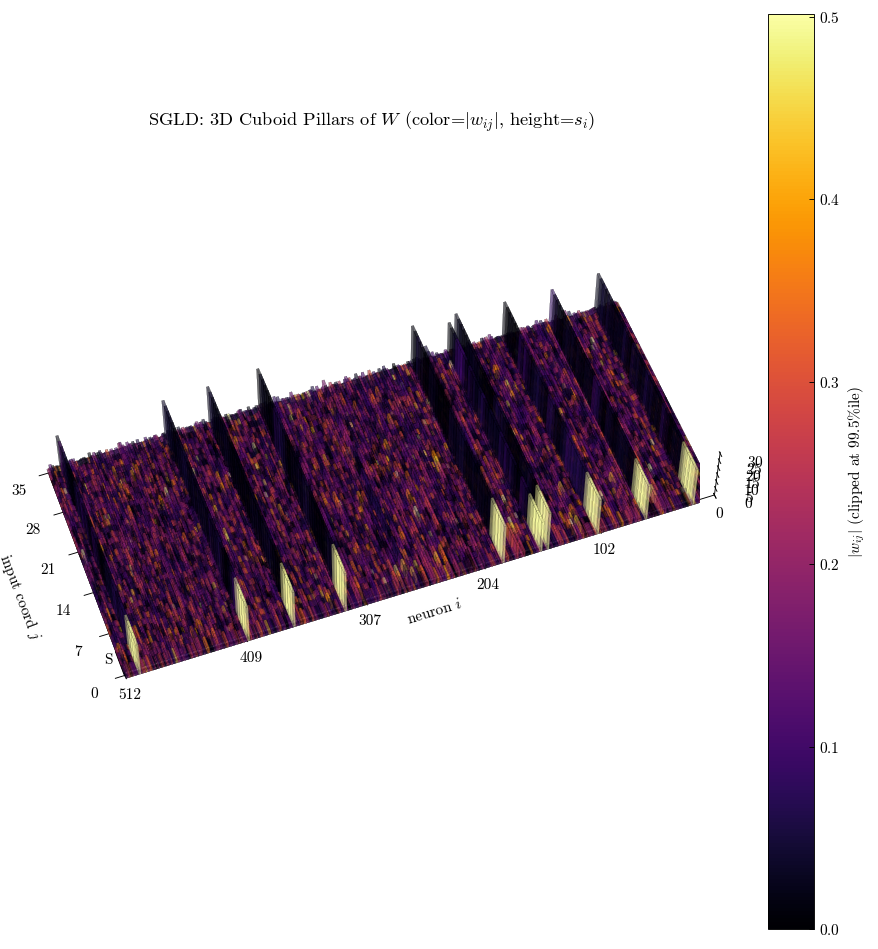

In [105]:
# --- 3D cuboid pillars: proper rectangular blocks for each weight (i,j) ----
import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.cm import get_cmap, ScalarMappable
from mpl_toolkits.mplot3d.art3d import Poly3DCollection


def load_WA_from_state_dict(path, map_location="cpu"):
    sd = torch.load(path, map_location=map_location)
    if isinstance(sd, dict) and 'w' in sd and 'a' in sd:
        W, a = sd['w'].detach().cpu(), sd['a'].detach().cpu()
    elif isinstance(sd, dict) and 'state_dict' in sd:
        st = sd['state_dict']; W, a = st['w'].detach().cpu(), st['a'].detach().cpu()
    else:
        keys = list(sd.keys())
        key_w = next(k for k in keys if k.endswith('w') and sd[k].ndim == 2)
        key_a = next(k for k in keys if k.endswith('a') and sd[k].ndim >= 1)
        W, a = sd[key_w].detach().cpu(), sd[key_a].detach().cpu()
    if a.ndim > 1: a = a.view(-1)
    return W, a


def _sorted_unique_ints(idxs, lo=0, hi=None):
    arr = np.array(list(idxs), dtype=np.int64).ravel()
    if hi is not None: arr = arr[(arr >= lo) & (arr < hi)]
    else:              arr = arr[(arr >= lo)]
    return np.unique(arr)


def neuron_specialization_scores(W_np, a_np, S, mode="abs-sum"):
    d, N = W_np.shape
    S_idx = _sorted_unique_ints(S, lo=0, hi=d)
    if S_idx.size == 0: return np.abs(a_np)
    WS = W_np[S_idx, :]
    if mode == "abs-sum":    return np.abs(a_np) * np.sum(np.abs(WS), axis=0)
    if mode == "signed-sum": return np.abs(a_np * np.sum(WS, axis=0))
    if mode == "l2":         return np.abs(a_np) * np.sqrt(np.sum(WS*WS, axis=0))
    if mode == "a-only":     return np.abs(a_np)
    raise ValueError("unknown mode")


def create_cuboid(x0, y0, z0, dx, dy, dz):
    v = [
        [x0,      y0,      z0],
        [x0+dx,   y0,      z0],
        [x0+dx,   y0+dy,   z0],
        [x0,      y0+dy,   z0],
        [x0,      y0,      z0+dz],
        [x0+dx,   y0,      z0+dz],
        [x0+dx,   y0+dy,   z0+dz],
        [x0,      y0+dy,   z0+dz],
    ]
    return [
        [v[0], v[1], v[5], v[4]],  # +x
        [v[2], v[3], v[7], v[6]],  # -x
        [v[0], v[3], v[7], v[4]],  # +y
        [v[1], v[2], v[6], v[5]],  # -y
        [v[0], v[1], v[2], v[3]],  # bottom
        [v[4], v[5], v[6], v[7]],  # top
    ]


def plot_W_cuboids_3d(
    W, a, S,
    *,
    spec_mode="abs-sum",
    height_percentile=99.0,
    height_scale=150.0,
    alpha=0.85,
    vmax_percentile=99.5,

    # stretch / squish cell sizes (x = input coord j, y = neuron i)
    cell_size_x=6.0,
    cell_size_y=0.5,

    # footprint inside each cell
    width_frac_x=0.8,
    width_frac_y=0.8,

    edgecolor='black',
    linewidth=0.3,
    elev=25, azim=-60,
    figsize=(14, 10),
    downsample_rows=1,
    downsample_cols=1,
    axis_index_ticks=True,   # <-- relabel ticks as indices 0..d and 0..N
    savefig=None, show=True
):
    # to numpy
    W_np = W.detach().cpu().numpy() if torch.is_tensor(W) else np.asarray(W)
    a_np = a.detach().cpu().numpy() if torch.is_tensor(a) else np.asarray(a).reshape(-1)
    d, N = W_np.shape
    absW = np.abs(W_np)

    # heights (per row), using log scale
    s = neuron_specialization_scores(W_np, a_np, S, mode=spec_mode)
    s_log = np.log1p(s)
    denom = max(np.percentile(s_log, height_percentile), 1e-12)
    z_heights = height_scale * (s_log / denom)

    # colors from |w_ij|
    vmax = np.percentile(absW, vmax_percentile) if absW.size else 1.0
    if not np.isfinite(vmax) or vmax <= 0: vmax = 1.0
    norm, cmap = Normalize(0.0, vmax), get_cmap("inferno")

    # physical pillar sizes inside each cell
    px = float(cell_size_x) * float(width_frac_x)
    py = float(cell_size_y) * float(width_frac_y)

    js = np.arange(d)[::max(1, int(downsample_cols))]
    is_ = np.arange(N)[::max(1, int(downsample_rows))]

    fig = plt.figure(figsize=figsize)
    ax = fig.add_subplot(111, projection='3d')
    ax.view_init(elev=elev, azim=azim)

    # build all cuboids
    all_faces, face_colors = [], []
    for i in is_:
        z = float(z_heights[i])
        if z < 1e-6:
            continue
        y_cell0 = i * cell_size_y
        y0 = y_cell0 + (cell_size_y - py) / 2.0
        for j in js:
            x_cell0 = j * cell_size_x
            x0 = x_cell0 + (cell_size_x - px) / 2.0
            faces = create_cuboid(x0, y0, 0.0, px, py, z)
            all_faces.extend(faces)
            rgba = list(cmap(norm(absW[j, i]))); rgba[3] = alpha
            face_colors.extend([rgba] * 6)

    coll = Poly3DCollection(all_faces, facecolors=face_colors,
                            edgecolors=edgecolor, linewidths=linewidth)
    ax.add_collection3d(coll)

    # remove all background panes and grids
    for p in (ax.xaxis.pane, ax.yaxis.pane, ax.zaxis.pane):
        p.set_visible(False)
    ax.grid(False)

    # axis limits (physical units)
    Xmax = d * cell_size_x
    Ymax = N * cell_size_y
    Zmax = max(z_heights) * 1.1 if len(z_heights) else 1.0
    ax.set_xlim(0, Xmax)
    ax.set_ylim(0, Ymax)
    ax.set_zlim(0, Zmax)
    ax.set_box_aspect([Xmax, Ymax, Zmax])

    # labels
    ax.set_title(r"SGLD: 3D Cuboid Pillars of $W$ (color=$|w_{ij}|$, height=$s_i$)", pad=12)
    ax.set_xlabel("input coord $j$")
    ax.set_ylabel("neuron $i$")
    ax.set_zlabel(r"$s_i$ (specialization)")

    # optional: relabel ticks in index units rather than physical units
    if axis_index_ticks:
        # x ticks as j indices
        xt = np.linspace(0, Xmax, 6)
        ax.set_xticks(xt)
        ax.set_xticklabels((xt / cell_size_x).astype(int))
        # y ticks as i indices
        yt = np.linspace(0, Ymax, 6)
        ax.set_yticks(yt)
        ax.set_yticklabels((yt / cell_size_y).astype(int))

    # bracket S on ground (z=0)
    S_idx = _sorted_unique_ints(S, lo=0, hi=d)
    if S_idx.size:
        j0, j1 = int(S_idx.min()), int(S_idx.max())
        x0, x1 = j0 * cell_size_x, (j1 + 1) * cell_size_x
        ax.plot([x0, x1, x1, x0, x0],
                [0,   0,  Ymax, Ymax, 0],
                [0,   0,   0,    0,   0], color='k', linewidth=1.6)
        ax.text((x0+x1)/2.0, Ymax + 0.02*Ymax, 0, "S", ha="center", va="bottom")

    # colorbar
    sm = ScalarMappable(norm=norm, cmap=cmap); sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, shrink=0.72, pad=0.08)
    cbar.set_label(r"$|w_{{ij}}|$ (clipped at {}%ile)".format(vmax_percentile))

    plt.tight_layout()
    if savefig:
        fig.savefig(savefig, dpi=300, bbox_inches="tight", facecolor="white")
    if show:
        plt.show()
    return fig, ax


# --- Example usage -----------------------------------------------------------
if __name__ == "__main__":
    MODEL_FILE = "/home/goring/mean_field_langevin/Langevin_training/results_paper1/d35_k4_lrdecay_5e-3test2/d35_k4/final_model_P_10000_d_35_k_4_exp_2_kappa_0.005000_eta0_2.000000e-03_etaf_5.000000e-04_gamma_0.500000.pt"
    S = [0, 1, 2, 3]

    print("Loading:", MODEL_FILE)
    W, a = load_WA_from_state_dict(MODEL_FILE)
    print(f"W: {tuple(W.shape)} | a: {tuple(a.shape)}")

    plot_W_cuboids_3d(
        W, a, S,
        spec_mode="abs-sum",
        height_percentile=99.0,
        height_scale=25.0,
        alpha=0.35,
        vmax_percentile=99.5,
        cell_size_x=3.0,
        cell_size_y=0.5,
        width_frac_x=2.0,      # can be >1 if you want chunky pillars
        width_frac_y=2.0,
        edgecolor='black',
        linewidth=0.05,
        elev=55, azim=160,
        figsize=(10, 15),
        downsample_rows=1,
        downsample_cols=1,
        axis_index_ticks=True,  # <- relabel y axis in 0..N
        savefig=None,
        show=True
    )


KeyError: 'ij'

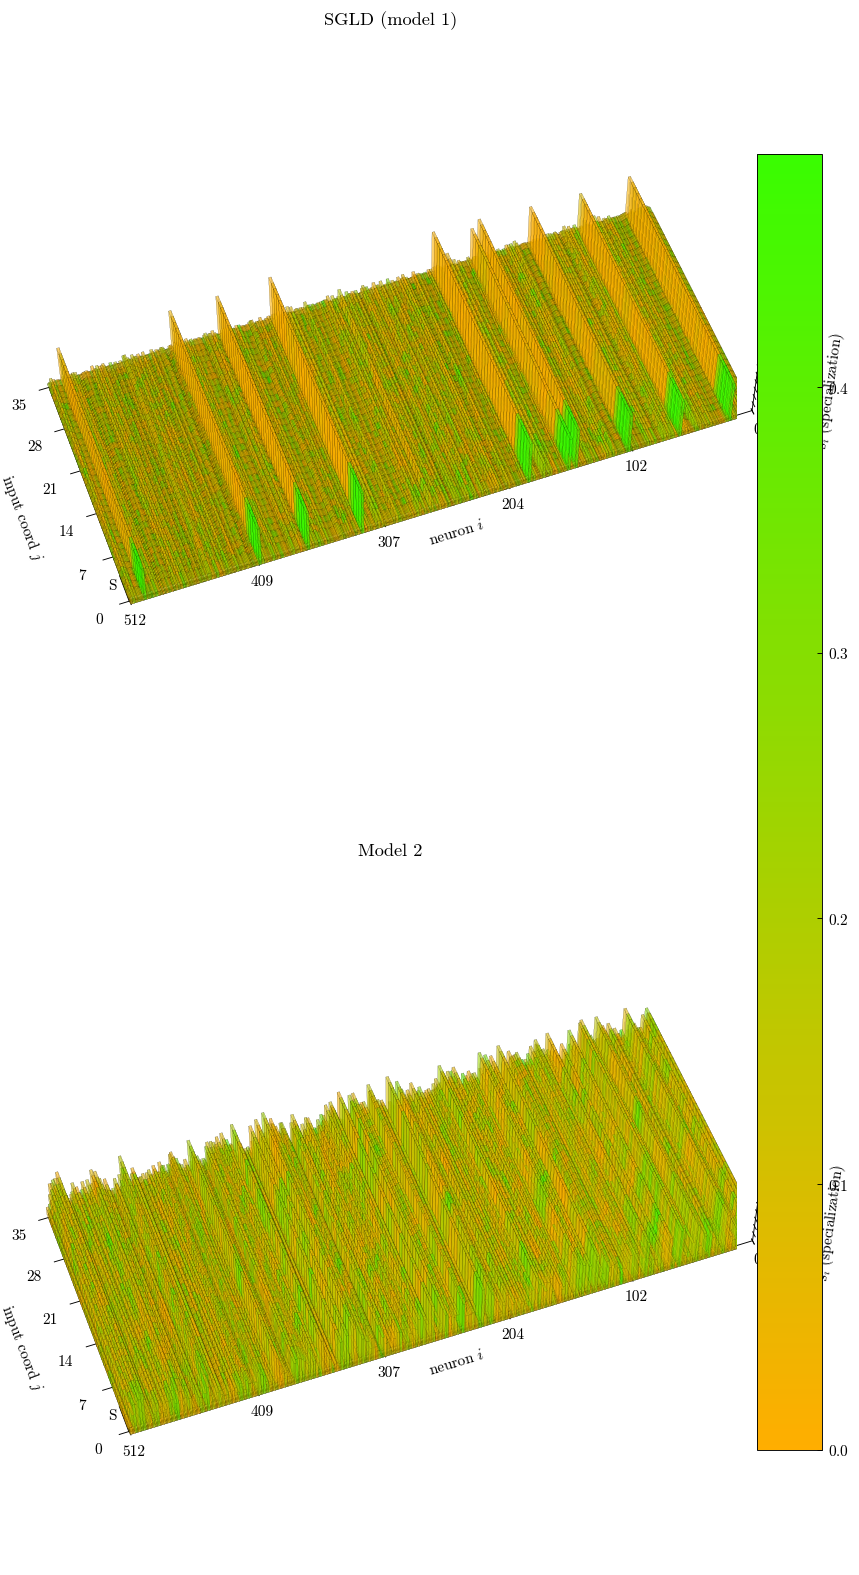

In [107]:
# --- 3D cuboid pillars: two-figure stack with shared colormap/colorbar (SVG) ---
import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from matplotlib.colors import LinearSegmentedColormap
from mpl_toolkits.mplot3d.art3d import Poly3DCollection


# ---------------- I/O ----------------
def load_WA_from_state_dict(path, map_location="cpu"):
    sd = torch.load(path, map_location=map_location)
    if isinstance(sd, dict) and 'w' in sd and 'a' in sd:
        W, a = sd['w'].detach().cpu(), sd['a'].detach().cpu()
    elif isinstance(sd, dict) and 'state_dict' in sd:
        st = sd['state_dict']; W, a = st['w'].detach().cpu(), st['a'].detach().cpu()
    else:
        keys = list(sd.keys())
        key_w = next(k for k in keys if k.endswith('w') and sd[k].ndim == 2)
        key_a = next(k for k in keys if k.endswith('a') and sd[k].ndim >= 1)
        W, a = sd[key_w].detach().cpu(), sd[key_a].detach().cpu()
    if a.ndim > 1:
        a = a.view(-1)
    return W, a


# --------------- utils ----------------
def _sorted_unique_ints(idxs, lo=0, hi=None):
    arr = np.array(list(idxs), dtype=np.int64).ravel()
    if hi is not None:
        arr = arr[(arr >= lo) & (arr < hi)]
    else:
        arr = arr[(arr >= lo)]
    return np.unique(arr)


def neuron_specialization_scores(W_np, a_np, S, mode="abs-sum"):
    d, N = W_np.shape
    S_idx = _sorted_unique_ints(S, lo=0, hi=d)
    if S_idx.size == 0:
        return np.abs(a_np)
    WS = W_np[S_idx, :]
    if mode == "abs-sum":
        return np.abs(a_np) * np.sum(np.abs(WS), axis=0)
    if mode == "signed-sum":
        return np.abs(a_np * np.sum(WS, axis=0))
    if mode == "l2":
        return np.abs(a_np) * np.sqrt(np.sum(WS * WS, axis=0))
    if mode == "a-only":
        return np.abs(a_np)
    raise ValueError("unknown mode")


def create_cuboid(x0, y0, z0, dx, dy, dz):
    v = [
        [x0,      y0,      z0],
        [x0+dx,   y0,      z0],
        [x0+dx,   y0+dy,   z0],
        [x0,      y0+dy,   z0],
        [x0,      y0,      z0+dz],
        [x0+dx,   y0,      z0+dz],
        [x0+dx,   y0+dy,   z0+dz],
        [x0,      y0+dy,   z0+dz],
    ]
    return [
        [v[0], v[1], v[5], v[4]],  # +x
        [v[2], v[3], v[7], v[6]],  # -x
        [v[0], v[3], v[7], v[4]],  # +y
        [v[1], v[2], v[6], v[5]],  # -y
        [v[0], v[1], v[2], v[3]],  # bottom
        [v[4], v[5], v[6], v[7]],  # top
    ]


def make_two_color_cmap(hex_left="#0000ff", hex_right="#ffcc00", name="twohex"):
    """
    Linear 2-stop colormap from two hex colors.
    """
    return LinearSegmentedColormap.from_list(name, [hex_left, hex_right])


# --------------- core renderer (draws onto a given 3D axis) ----------------
def draw_W_cuboids_on_axis(
    ax,
    W, a, S,
    *,
    norm, cmap,                            # shared across plots
    spec_mode="abs-sum",
    height_percentile=99.0,
    height_scale=25.0,
    alpha=0.35,
    # ground geometry
    cell_size_x=3.0,
    cell_size_y=0.5,
    width_frac_x=2.0,
    width_frac_y=2.0,
    edgecolor="black",
    linewidth=0.05,
    elev=55, azim=160,
    axis_index_ticks=True,
    title=None
):
    # arrays
    W_np = W.detach().cpu().numpy() if torch.is_tensor(W) else np.asarray(W)
    a_np = a.detach().cpu().numpy() if torch.is_tensor(a) else np.asarray(a).reshape(-1)
    d, N = W_np.shape
    absW = np.abs(W_np)

    # heights (log specialisation)
    s = neuron_specialization_scores(W_np, a_np, S, mode=spec_mode)
    s_log = np.log1p(s)
    denom = max(np.percentile(s_log, height_percentile), 1e-12)
    z_heights = height_scale * (s_log / denom)

    # pillar footprint
    px = float(cell_size_x) * float(width_frac_x)
    py = float(cell_size_y) * float(width_frac_y)

    js = np.arange(d)
    is_ = np.arange(N)

    ax.view_init(elev=elev, azim=azim)

    # build all cuboids
    all_faces, face_colors = [], []
    for i in is_:
        z = float(z_heights[i])
        if z < 1e-6:
            continue
        y_cell0 = i * cell_size_y
        y0 = y_cell0 + (cell_size_y - py) / 2.0
        for j in js:
            x_cell0 = j * cell_size_x
            x0 = x_cell0 + (cell_size_x - px) / 2.0
            faces = create_cuboid(x0, y0, 0.0, px, py, z)
            all_faces.extend(faces)
            rgba = list(cmap(norm(absW[j, i]))); rgba[3] = alpha
            face_colors.extend([rgba] * 6)

    coll = Poly3DCollection(all_faces, facecolors=face_colors,
                            edgecolors=edgecolor, linewidths=linewidth)
    ax.add_collection3d(coll)

    # remove all panes / grids
    for p in (ax.xaxis.pane, ax.yaxis.pane, ax.zaxis.pane):
        p.set_visible(False)
    ax.grid(False)

    # limits in *physical* units
    Xmax = d * cell_size_x
    Ymax = N * cell_size_y
    Zmax = max(z_heights) * 1.1 if len(z_heights) else 1.0
    ax.set_xlim(0, Xmax)
    ax.set_ylim(0, Ymax)
    ax.set_zlim(0, Zmax)
    ax.set_box_aspect([Xmax, Ymax, Zmax])

    # labels
    if title:
        ax.set_title(title, pad=10)
    ax.set_xlabel("input coord $j$")
    ax.set_ylabel("neuron $i$")
    ax.set_zlabel(r"$s_i$ (specialization)")

    # re-label ticks as indices
    if axis_index_ticks:
        xt = np.linspace(0, Xmax, 6)
        ax.set_xticks(xt)
        ax.set_xticklabels((xt / cell_size_x).astype(int))
        yt = np.linspace(0, Ymax, 6)
        ax.set_yticks(yt)
        ax.set_yticklabels((yt / cell_size_y).astype(int))

    # bracket S on ground
    S_idx = _sorted_unique_ints(S, lo=0, hi=d)
    if S_idx.size:
        j0, j1 = int(S_idx.min()), int(S_idx.max())
        x0, x1 = j0 * cell_size_x, (j1 + 1) * cell_size_x
        ax.plot([x0, x1, x1, x0, x0],
                [0,   0,  Ymax, Ymax, 0],
                [0,   0,   0,    0,   0], color='k', linewidth=1.6)
        ax.text((x0 + x1) / 2.0, Ymax + 0.02 * Ymax, 0,
                "S", ha="center", va="bottom")


# --------------- convenience wrapper: single or two models with shared colorbar ---------------
def plot_one_or_two_models(
    model1, S, *,
    model2=None,
    # colormap & normalization
    color_left="#3300ff", color_right="#ffcc00",
    vmax_percentile=99.5,
    # rendering (passed to draw function)
    spec_mode="abs-sum",
    height_percentile=99.0,
    height_scale=25.0,
    alpha=0.35,
    cell_size_x=3.0,
    cell_size_y=0.5,
    width_frac_x=2.0,
    width_frac_y=2.0,
    edgecolor='black',
    linewidth=0.05,
    elev=55, azim=160,
    axis_index_ticks=True,
    # figure options
    figsize=(12, 18),
    save_svg_path=None
):
    """
    model1, model2: either (W, a) tuple or a filepath to load.
    """
    # Load tensors
    if isinstance(model1, str):
        W1, a1 = load_WA_from_state_dict(model1)
        title1 = "SGLD (model 1)"
    else:
        W1, a1 = model1
        title1 = "Model 1"

    if model2 is not None:
        if isinstance(model2, str):
            W2, a2 = load_WA_from_state_dict(model2)
            title2 = "Model 2"
        else:
            W2, a2 = model2
            title2 = "Model 2"
    else:
        W2 = a2 = None

    # Build shared colormap and normalization from joint data
    cmap = make_two_color_cmap(color_left, color_right)

    absW1 = np.abs(W1.detach().cpu().numpy())
    if W2 is not None:
        absW2 = np.abs(W2.detach().cpu().numpy())
        joint = np.concatenate([absW1.ravel(), absW2.ravel()])
    else:
        joint = absW1.ravel()

    vmax = np.percentile(joint, vmax_percentile) if joint.size else 1.0
    if not np.isfinite(vmax) or vmax <= 0:
        vmax = 1.0
    norm = Normalize(0.0, float(vmax))

    # Figure and axes
    if W2 is None:
        fig = plt.figure(figsize=(figsize[0], figsize[1] / 2))
        ax1 = fig.add_subplot(111, projection='3d')
        draw_W_cuboids_on_axis(
            ax1, W1, a1, S,
            norm=norm, cmap=cmap,
            spec_mode=spec_mode,
            height_percentile=height_percentile,
            height_scale=height_scale,
            alpha=alpha,
            cell_size_x=cell_size_x, cell_size_y=cell_size_y,
            width_frac_x=width_frac_x, width_frac_y=width_frac_y,
            edgecolor=edgecolor, linewidth=linewidth,
            elev=elev, azim=azim,
            axis_index_ticks=axis_index_ticks,
            title="SGLD"
        )
        axes = [ax1]
    else:
        fig = plt.figure(figsize=figsize)
        gs = fig.add_gridspec(nrows=2, ncols=1, height_ratios=[1, 1])
        ax1 = fig.add_subplot(gs[0, 0], projection='3d')
        ax2 = fig.add_subplot(gs[1, 0], projection='3d')

        draw_W_cuboids_on_axis(
            ax1, W1, a1, S,
            norm=norm, cmap=cmap,
            spec_mode=spec_mode,
            height_percentile=height_percentile,
            height_scale=height_scale,
            alpha=alpha,
            cell_size_x=cell_size_x, cell_size_y=cell_size_y,
            width_frac_x=width_frac_x, width_frac_y=width_frac_y,
            edgecolor=edgecolor, linewidth=linewidth,
            elev=elev, azim=azim,
            axis_index_ticks=axis_index_ticks,
            title=title1
        )
        draw_W_cuboids_on_axis(
            ax2, W2, a2, S,
            norm=norm, cmap=cmap,
            spec_mode=spec_mode,
            height_percentile=height_percentile,
            height_scale=height_scale,
            alpha=alpha,
            cell_size_x=cell_size_x, cell_size_y=cell_size_y,
            width_frac_x=width_frac_x, width_frac_y=width_frac_y,
            edgecolor=edgecolor, linewidth=linewidth,
            elev=elev, azim=azim,
            axis_index_ticks=axis_index_ticks,
            title=title2
        )
        axes = [ax1, ax2]

    # Single shared colorbar
    sm = ScalarMappable(norm=norm, cmap=cmap); sm.set_array([])
    cbar = fig.colorbar(sm, ax=axes, shrink=0.85, pad=0.02)
    cbar.set_label(r"$|w_{ij}|$ (clipped at joint {}%ile)".format(vmax_percentile))

    plt.tight_layout()
    if save_svg_path:
        fig.savefig(save_svg_path, format="svg", dpi=300, bbox_inches="tight", facecolor="white")
    plt.show()
    return fig


# ------------------------ Example usage --------------------------------------
if __name__ == "__main__":
    # Required inputs
    MODEL_FILE_1 = "/home/goring/mean_field_langevin/Langevin_training/results_paper1/d35_k4_lrdecay_5e-3test2/d35_k4/final_model_P_10000_d_35_k_4_exp_2_kappa_0.005000_eta0_2.000000e-03_etaf_5.000000e-04_gamma_0.500000.pt"
    # Optional comparison model (set to None to plot only the first)
    MODEL_FILE_2 = "/home/goring/mean_field_langevin/Langevin_training/results_paper1/d35_k4_lrdecay_5e-3test2/d35_k4/final_model_P_10_d_35_k_4_exp_2_kappa_0.005000_eta0_2.000000e-03_etaf_5.000000e-04_gamma_0.500000.pt"  # e.g. "/path/to/other_model.pt"
    S = [0, 1, 2, 3]

    # Two hex colors for the gradient colormap
    HEX_LEFT  = "#FFAE00"   # teal
    HEX_RIGHT = "#39FD01"   # orange

#"#39FD01", color_final="#636A6B",
    # Where to save the stacked SVG (or None to skip saving)
    SAVE_SVG = "/tmp/sgld_W_cuboids.svg"

    plot_one_or_two_models(
        MODEL_FILE_1, S,
        model2=MODEL_FILE_2,
        color_left=HEX_LEFT, color_right=HEX_RIGHT,  # <-- your 2-color gradient
        vmax_percentile=99.5,
        spec_mode="abs-sum",
        height_percentile=99.0,
        height_scale=25.0,
        alpha=0.35,
        cell_size_x=3.0,
        cell_size_y=0.5,
        width_frac_x=2.0,
        width_frac_y=2.0,
        edgecolor='black',
        linewidth=0.05,
        elev=55, azim=160,
        axis_index_ticks=True,
        figsize=(12, 18),             # 2 rows stacked
        save_svg_path=SAVE_SVG        # <-- SVG output
    )


/tmp/ipykernel_2278977/1832389736.py:308: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipykernel_2278977/1832389736.py:308: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


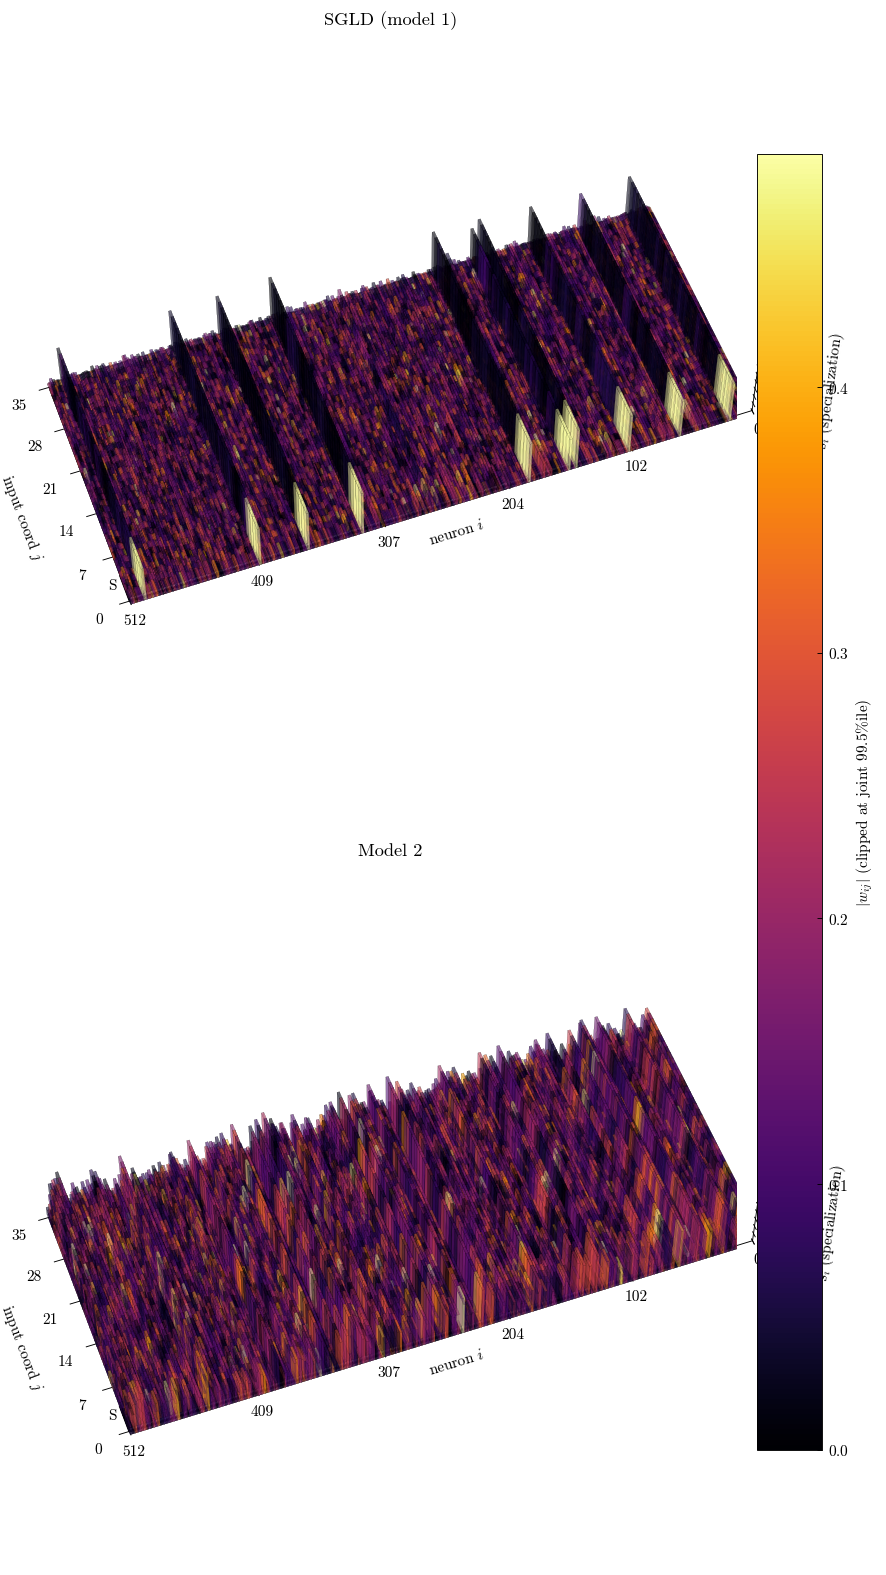

In [109]:
# --- 3D cuboid pillars: two-figure stack with shared colormap/colorbar (SVG) ---
import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize, LinearSegmentedColormap
from matplotlib.cm import ScalarMappable
from mpl_toolkits.mplot3d.art3d import Poly3DCollection


# ---------------- I/O ----------------
def load_WA_from_state_dict(path, map_location="cpu"):
    sd = torch.load(path, map_location=map_location)
    if isinstance(sd, dict) and 'w' in sd and 'a' in sd:
        W, a = sd['w'].detach().cpu(), sd['a'].detach().cpu()
    elif isinstance(sd, dict) and 'state_dict' in sd:
        st = sd['state_dict']; W, a = st['w'].detach().cpu(), st['a'].detach().cpu()
    else:
        keys = list(sd.keys())
        key_w = next(k for k in keys if k.endswith('w') and sd[k].ndim == 2)
        key_a = next(k for k in keys if k.endswith('a') and sd[k].ndim >= 1)
        W, a = sd[key_w].detach().cpu(), sd[key_a].detach().cpu()
    if a.ndim > 1:
        a = a.view(-1)
    return W, a


# --------------- utils ----------------
def _sorted_unique_ints(idxs, lo=0, hi=None):
    arr = np.array(list(idxs), dtype=np.int64).ravel()
    if hi is not None:
        arr = arr[(arr >= lo) & (arr < hi)]
    else:
        arr = arr[(arr >= lo)]
    return np.unique(arr)


def neuron_specialization_scores(W_np, a_np, S, mode="abs-sum"):
    d, N = W_np.shape
    S_idx = _sorted_unique_ints(S, lo=0, hi=d)
    if S_idx.size == 0:
        return np.abs(a_np)
    WS = W_np[S_idx, :]
    if mode == "abs-sum":
        return np.abs(a_np) * np.sum(np.abs(WS), axis=0)
    if mode == "signed-sum":
        return np.abs(a_np * np.sum(WS, axis=0))
    if mode == "l2":
        return np.abs(a_np) * np.sqrt(np.sum(WS * WS, axis=0))
    if mode == "a-only":
        return np.abs(a_np)
    raise ValueError("unknown mode")


def create_cuboid(x0, y0, z0, dx, dy, dz):
    v = [
        [x0,      y0,      z0],
        [x0+dx,   y0,      z0],
        [x0+dx,   y0+dy,   z0],
        [x0,      y0+dy,   z0],
        [x0,      y0,      z0+dz],
        [x0+dx,   y0,      z0+dz],
        [x0+dx,   y0+dy,   z0+dz],
        [x0,      y0+dy,   z0+dz],
    ]
    return [
        [v[0], v[1], v[5], v[4]],  # +x
        [v[2], v[3], v[7], v[6]],  # -x
        [v[0], v[3], v[7], v[4]],  # +y
        [v[1], v[2], v[6], v[5]],  # -y
        [v[0], v[1], v[2], v[3]],  # bottom
        [v[4], v[5], v[6], v[7]],  # top
    ]


def make_two_color_cmap(hex_left="#0000ff", hex_right="#ffcc00", name="twohex"):
    """Linear 2-stop colormap from two hex colors."""
    return LinearSegmentedColormap.from_list(name, [hex_left, hex_right])


# --------------- core renderer (draws onto a given 3D axis) ----------------
def draw_W_cuboids_on_axis(
    ax,
    W, a, S,
    *,
    norm, cmap,                            # shared across plots
    spec_mode="abs-sum",
    height_percentile=99.0,
    height_scale=25.0,
    alpha=0.35,
    # ground geometry
    cell_size_x=3.0,
    cell_size_y=0.5,
    width_frac_x=2.0,
    width_frac_y=2.0,
    edgecolor="black",
    linewidth=0.05,
    elev=55, azim=160,
    axis_index_ticks=True,
    title=None
):
    # arrays
    W_np = W.detach().cpu().numpy() if torch.is_tensor(W) else np.asarray(W)
    a_np = a.detach().cpu().numpy() if torch.is_tensor(a) else np.asarray(a).reshape(-1)
    d, N = W_np.shape
    absW = np.abs(W_np)

    # heights (log specialisation)
    s = neuron_specialization_scores(W_np, a_np, S, mode=spec_mode)
    s_log = np.log1p(s)
    denom = max(np.percentile(s_log, height_percentile), 1e-12)
    z_heights = height_scale * (s_log / denom)

    # pillar footprint
    px = float(cell_size_x) * float(width_frac_x)
    py = float(cell_size_y) * float(width_frac_y)

    js = np.arange(d)
    is_ = np.arange(N)

    ax.view_init(elev=elev, azim=azim)

    # build all cuboids
    all_faces, face_colors = [], []
    for i in is_:
        z = float(z_heights[i])
        if z < 1e-6:
            continue
        y_cell0 = i * cell_size_y
        y0 = y_cell0 + (cell_size_y - py) / 2.0
        for j in js:
            x_cell0 = j * cell_size_x
            x0 = x_cell0 + (cell_size_x - px) / 2.0
            faces = create_cuboid(x0, y0, 0.0, px, py, z)
            all_faces.extend(faces)
            rgba = list(cmap(norm(absW[j, i]))); rgba[3] = alpha
            face_colors.extend([rgba] * 6)

    coll = Poly3DCollection(all_faces, facecolors=face_colors,
                            edgecolors=edgecolor, linewidths=linewidth)
    ax.add_collection3d(coll)

    # remove all panes / grids
    for p in (ax.xaxis.pane, ax.yaxis.pane, ax.zaxis.pane):
        p.set_visible(False)
    ax.grid(False)

    # limits in *physical* units
    Xmax = d * cell_size_x
    Ymax = N * cell_size_y
    Zmax = max(z_heights) * 1.1 if len(z_heights) else 1.0
    ax.set_xlim(0, Xmax)
    ax.set_ylim(0, Ymax)
    ax.set_zlim(0, Zmax)
    ax.set_box_aspect([Xmax, Ymax, Zmax])

    # labels
    if title:
        ax.set_title(title, pad=10)
    ax.set_xlabel("input coord $j$")
    ax.set_ylabel("neuron $i$")
    ax.set_zlabel(r"$s_i$ (specialization)")

    # re-label ticks as indices
    if axis_index_ticks:
        xt = np.linspace(0, Xmax, 6)
        ax.set_xticks(xt)
        ax.set_xticklabels((xt / cell_size_x).astype(int))
        yt = np.linspace(0, Ymax, 6)
        ax.set_yticks(yt)
        ax.set_yticklabels((yt / cell_size_y).astype(int))

    # bracket S on ground
    S_idx = _sorted_unique_ints(S, lo=0, hi=d)
    if S_idx.size:
        j0, j1 = int(S_idx.min()), int(S_idx.max())
        x0, x1 = j0 * cell_size_x, (j1 + 1) * cell_size_x
        ax.plot([x0, x1, x1, x0, x0],
                [0,   0,  Ymax, Ymax, 0],
                [0,   0,   0,    0,   0], color='k', linewidth=1.6)
        ax.text((x0 + x1) / 2.0, Ymax + 0.02 * Ymax, 0,
                "S", ha="center", va="bottom")


# --------------- convenience wrapper: single or two models with shared colorbar ---------------
def plot_one_or_two_models(
    model1, S, *,
    model2=None,
    # colormap & normalization
    cmap_name="inferno",         # <- default back to inferno
    hex_left=None, hex_right=None,  # set both to use a 2-hex gradient instead
    vmax_percentile=99.5,
    # rendering (passed to draw function)
    spec_mode="abs-sum",
    height_percentile=99.0,
    height_scale=25.0,
    alpha=0.35,
    cell_size_x=3.0,
    cell_size_y=0.5,
    width_frac_x=2.0,
    width_frac_y=2.0,
    edgecolor='black',
    linewidth=0.05,
    elev=55, azim=160,
    axis_index_ticks=True,
    # figure options
    figsize=(12, 18),
    save_svg_path=None
):
    """
    model1, model2: either (W, a) tuple or a filepath to load.
    """
    # Load tensors
    if isinstance(model1, str):
        W1, a1 = load_WA_from_state_dict(model1)
        title1 = "SGLD (model 1)"
    else:
        W1, a1 = model1
        title1 = "Model 1"

    if model2 is not None:
        if isinstance(model2, str):
            W2, a2 = load_WA_from_state_dict(model2)
            title2 = "Model 2"
        else:
            W2, a2 = model2
            title2 = "Model 2"
    else:
        W2 = a2 = None

    # Build shared colormap and normalization from joint data
    if hex_left is not None and hex_right is not None:
        cmap = make_two_color_cmap(hex_left, hex_right)
    else:
        cmap = plt.get_cmap(cmap_name)

    absW1 = np.abs(W1.detach().cpu().numpy())
    if W2 is not None:
        absW2 = np.abs(W2.detach().cpu().numpy())
        joint = np.concatenate([absW1.ravel(), absW2.ravel()])
    else:
        joint = absW1.ravel()

    vmax = np.percentile(joint, vmax_percentile) if joint.size else 1.0
    if not np.isfinite(vmax) or vmax <= 0:
        vmax = 1.0
    norm = Normalize(0.0, float(vmax))

    # Figure and axes
    if W2 is None:
        fig = plt.figure(figsize=(figsize[0], figsize[1] / 2))
        ax1 = fig.add_subplot(111, projection='3d')
        draw_W_cuboids_on_axis(
            ax1, W1, a1, S,
            norm=norm, cmap=cmap,
            spec_mode=spec_mode,
            height_percentile=height_percentile,
            height_scale=height_scale,
            alpha=alpha,
            cell_size_x=cell_size_x, cell_size_y=cell_size_y,
            width_frac_x=width_frac_x, width_frac_y=width_frac_y,
            edgecolor=edgecolor, linewidth=linewidth,
            elev=elev, azim=azim,
            axis_index_ticks=axis_index_ticks,
            title="SGLD"
        )
        axes = [ax1]
    else:
        fig = plt.figure(figsize=figsize)
        gs = fig.add_gridspec(nrows=2, ncols=1, height_ratios=[1, 1])
        ax1 = fig.add_subplot(gs[0, 0], projection='3d')
        ax2 = fig.add_subplot(gs[1, 0], projection='3d')

        draw_W_cuboids_on_axis(
            ax1, W1, a1, S,
            norm=norm, cmap=cmap,
            spec_mode=spec_mode,
            height_percentile=height_percentile,
            height_scale=height_scale,
            alpha=alpha,
            cell_size_x=cell_size_x, cell_size_y=cell_size_y,
            width_frac_x=width_frac_x, width_frac_y=width_frac_y,
            edgecolor=edgecolor, linewidth=linewidth,
            elev=elev, azim=azim,
            axis_index_ticks=axis_index_ticks,
            title=title1
        )
        draw_W_cuboids_on_axis(
            ax2, W2, a2, S,
            norm=norm, cmap=cmap,
            spec_mode=spec_mode,
            height_percentile=height_percentile,
            height_scale=height_scale,
            alpha=alpha,
            cell_size_x=cell_size_x, cell_size_y=cell_size_y,
            width_frac_x=width_frac_x, width_frac_y=width_frac_y,
            edgecolor=edgecolor, linewidth=linewidth,
            elev=elev, azim=azim,
            axis_index_ticks=axis_index_ticks,
            title=title2
        )
        axes = [ax1, ax2]

    # Single shared colorbar (escape {ij} for .format)
    sm = ScalarMappable(norm=norm, cmap=cmap); sm.set_array([])
    cbar = fig.colorbar(sm, ax=axes, shrink=0.85, pad=0.02)
    cbar.set_label(r"$|w_{{ij}}|$ (clipped at joint {}%ile)".format(vmax_percentile))

    plt.tight_layout()
    if save_svg_path:
        fig.savefig(save_svg_path, format="svg", dpi=300, bbox_inches="tight", facecolor="white")
    plt.show()
    return fig


# ------------------------ Example usage --------------------------------------
if __name__ == "__main__":
    # Primary model
    MODEL_FILE_1 = "/home/goring/mean_field_langevin/Langevin_training/results_paper1/d35_k4_lrdecay_5e-3test2/d35_k4/final_model_P_10000_d_35_k_4_exp_2_kappa_0.005000_eta0_2.000000e-03_etaf_5.000000e-04_gamma_0.500000.pt"
    # Optional comparison model; set to None to plot only the first
    MODEL_FILE_2 = "/home/goring/mean_field_langevin/Langevin_training/results_paper1/d35_k4_lrdecay_5e-3test2/d35_k4/final_model_P_10_d_35_k_4_exp_2_kappa_0.005000_eta0_2.000000e-03_etaf_5.000000e-04_gamma_0.500000.pt"

    S = [0, 1, 2, 3]  # feature set bracket

    # Where to save the stacked SVG (or None to skip saving)
    SAVE_SVG = "/home/goring/mean_field_langevin/plots/plots/sgld_W_cuboids.svg"

    plot_one_or_two_models(
        MODEL_FILE_1, S,
        model2=MODEL_FILE_2,
        cmap_name="inferno",          # <- back to inferno
        # hex_left="#FFAE00", hex_right="#39FD01",  # (optional) 2-hex gradient if you want it
        vmax_percentile=99.5,
        spec_mode="abs-sum",
        height_percentile=99.0,
        height_scale=25.0,
        alpha=0.35,
        cell_size_x=3.0,
        cell_size_y=0.5,
        width_frac_x=2.0,
        width_frac_y=2.0,
        edgecolor='black',
        linewidth=0.05,
        elev=55, azim=160,
        axis_index_ticks=True,
        figsize=(12, 18),             # 2 rows stacked
        save_svg_path=SAVE_SVG        # SVG output
    )


/tmp/ipykernel_3565628/2079726408.py:328: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipykernel_3565628/2079726408.py:328: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


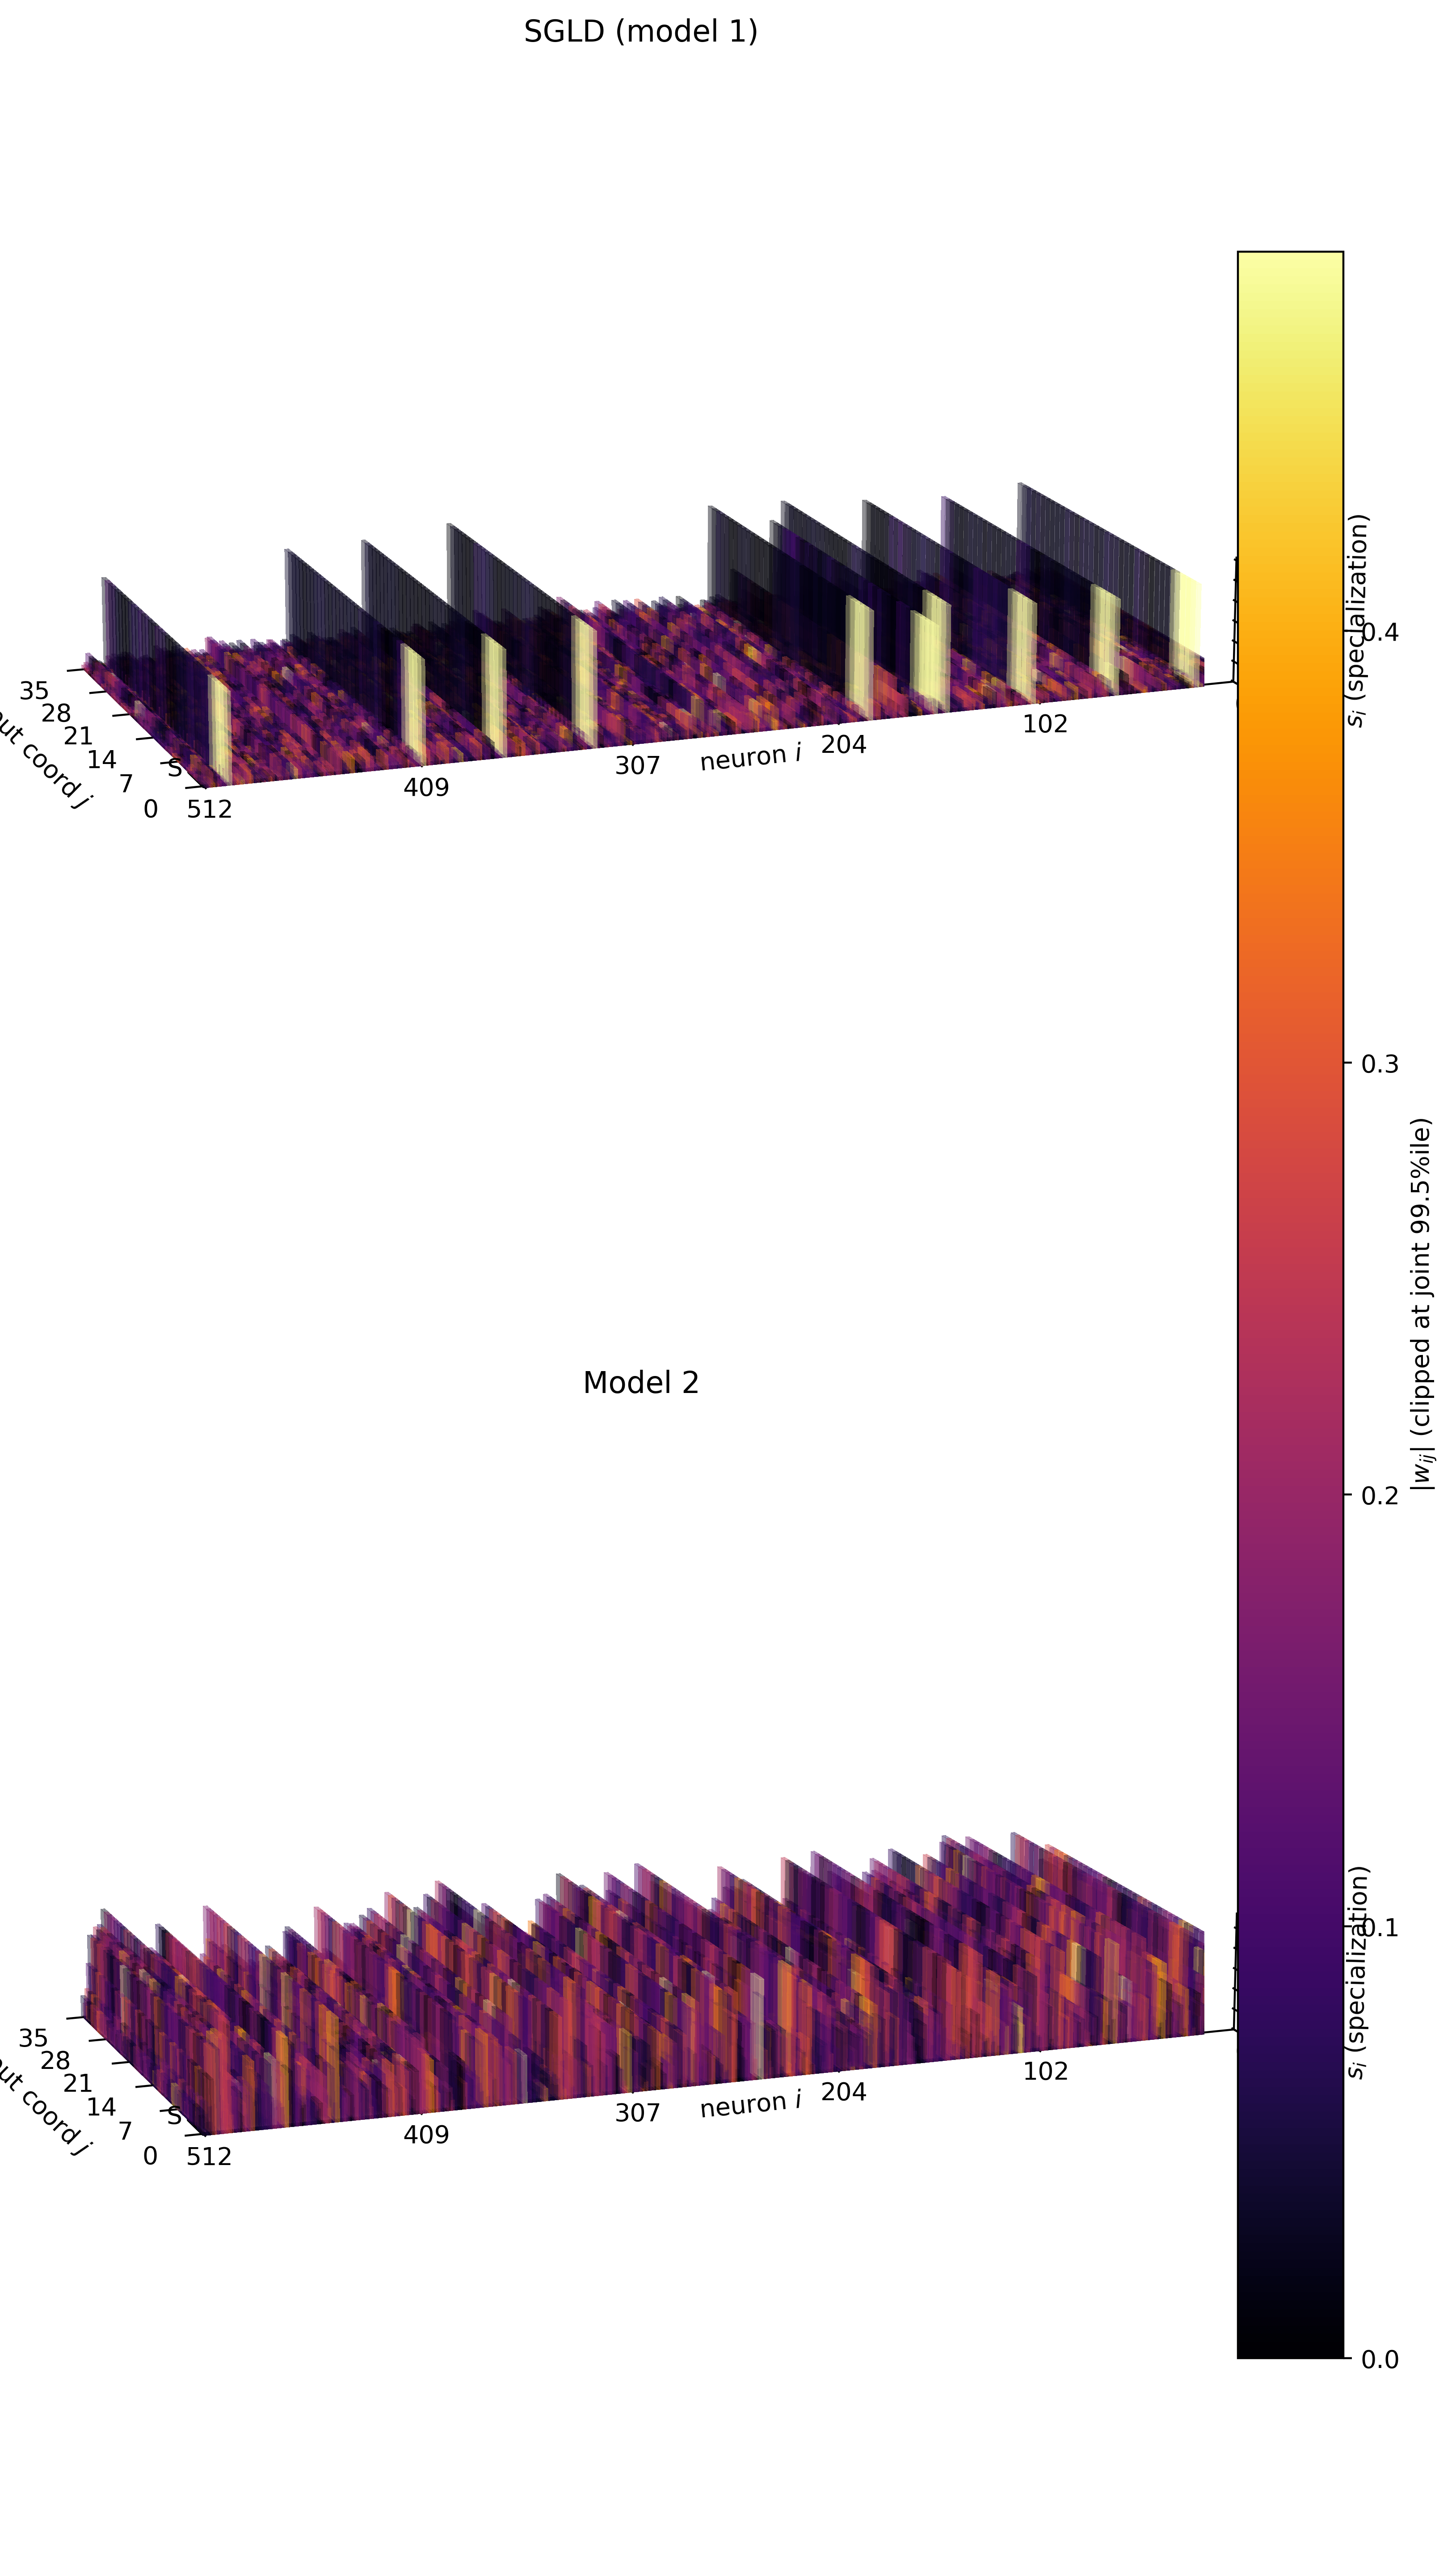

In [3]:
# --- 3D cuboid pillars: two-figure stack with shared colormap/colorbar (SVG) ---
import numpy as np
import torch
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize, LinearSegmentedColormap
from matplotlib.cm import ScalarMappable
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

# Keep text as real text in SVG (smaller files)
mpl.rcParams['svg.fonttype'] = 'none'

# ---------------- I/O ----------------
def load_WA_from_state_dict(path, map_location="cpu"):
    sd = torch.load(path, map_location=map_location)
    if isinstance(sd, dict) and 'w' in sd and 'a' in sd:
        W, a = sd['w'].detach().cpu(), sd['a'].detach().cpu()
    elif isinstance(sd, dict) and 'state_dict' in sd:
        st = sd['state_dict']; W, a = st['w'].detach().cpu(), st['a'].detach().cpu()
    else:
        keys = list(sd.keys())
        key_w = next(k for k in keys if k.endswith('w') and sd[k].ndim == 2)
        key_a = next(k for k in keys if k.endswith('a') and sd[k].ndim >= 1)
        W, a = sd[key_w].detach().cpu(), sd[key_a].detach().cpu()
    if a.ndim > 1:
        a = a.view(-1)
    return W, a

# --------------- utils ----------------
def _sorted_unique_ints(idxs, lo=0, hi=None):
    arr = np.array(list(idxs), dtype=np.int64).ravel()
    if hi is not None:
        arr = arr[(arr >= lo) & (arr < hi)]
    else:
        arr = arr[(arr >= lo)]
    return np.unique(arr)

def neuron_specialization_scores(W_np, a_np, S, mode="abs-sum"):
    d, N = W_np.shape
    S_idx = _sorted_unique_ints(S, lo=0, hi=d)
    if S_idx.size == 0:
        return np.abs(a_np)
    WS = W_np[S_idx, :]
    if mode == "abs-sum":
        return np.abs(a_np) * np.sum(np.abs(WS), axis=0)
    if mode == "signed-sum":
        return np.abs(a_np * np.sum(WS, axis=0))
    if mode == "l2":
        return np.abs(a_np) * np.sqrt(np.sum(WS * WS, axis=0))
    if mode == "a-only":
        return np.abs(a_np)
    raise ValueError("unknown mode")

def create_cuboid(x0, y0, z0, dx, dy, dz):
    v = [
        [x0,      y0,      z0],
        [x0+dx,   y0,      z0],
        [x0+dx,   y0+dy,   z0],
        [x0,      y0+dy,   z0],
        [x0,      y0,      z0+dz],
        [x0+dx,   y0,      z0+dz],
        [x0+dx,   y0+dy,   z0+dz],
        [x0,      y0+dy,   z0+dz],
    ]
    return [
        [v[0], v[1], v[5], v[4]],  # +x
        [v[2], v[3], v[7], v[6]],  # -x
        [v[0], v[3], v[7], v[4]],  # +y
        [v[1], v[2], v[6], v[5]],  # -y
        [v[0], v[1], v[2], v[3]],  # bottom
        [v[4], v[5], v[6], v[7]],  # top
    ]

def make_two_color_cmap(hex_left="#0000ff", hex_right="#ffcc00", name="twohex"):
    return LinearSegmentedColormap.from_list(name, [hex_left, hex_right])

# --------------- core renderer (draws onto a given 3D axis) ----------------
def draw_W_cuboids_on_axis(
    ax,
    W, a, S,
    *,
    norm, cmap,                            # shared across plots
    spec_mode="abs-sum",
    height_percentile=99.0,
    height_scale=25.0,
    alpha=0.35,
    # ground geometry
    cell_size_x=3.0,
    cell_size_y=0.5,
    width_frac_x=2.0,
    width_frac_y=2.0,
    edgecolor="black",
    linewidth=0.05,
    elev=55, azim=160,
    axis_index_ticks=True,
    title=None,
    # --- SVG friendliness ---
    rasterize_cuboids=True,        # rasterize heavy geometry into the SVG
    rasterize_dpi=300,             # effective resolution for rasterized layer
    antialiased=False,             # reduce SVG verbosity a bit
):
    # arrays
    W_np = W.detach().cpu().numpy() if torch.is_tensor(W) else np.asarray(W)
    a_np = a.detach().cpu().numpy() if torch.is_tensor(a) else np.asarray(a).reshape(-1)
    d, N = W_np.shape
    absW = np.abs(W_np)

    # heights (log specialisation)
    s = neuron_specialization_scores(W_np, a_np, S, mode=spec_mode)
    s_log = np.log1p(s)
    denom = max(np.percentile(s_log, height_percentile), 1e-12)
    z_heights = height_scale * (s_log / denom)

    # pillar footprint
    px = float(cell_size_x) * float(width_frac_x)
    py = float(cell_size_y) * float(width_frac_y)

    js = np.arange(d)
    is_ = np.arange(N)

    ax.view_init(elev=elev, azim=azim)

    # build all cuboids
    all_faces, face_colors = [], []
    for i in is_:
        z = float(z_heights[i])
        if z < 1e-6:
            continue
        y_cell0 = i * cell_size_y
        y0 = y_cell0 + (cell_size_y - py) / 2.0
        for j in js:
            x_cell0 = j * cell_size_x
            x0 = x_cell0 + (cell_size_x - px) / 2.0
            faces = create_cuboid(x0, y0, 0.0, px, py, z)
            all_faces.extend(faces)
            rgba = list(cmap(norm(absW[j, i]))); rgba[3] = alpha
            face_colors.extend([rgba] * 6)

    coll = Poly3DCollection(
        all_faces,
        facecolors=face_colors,
        edgecolors=edgecolor,
        linewidths=linewidth,
        antialiased=antialiased,
    )
    if rasterize_cuboids:
        # This turns the entire collection into a single embedded bitmap in the SVG.
        coll.set_rasterized(True)
    ax.add_collection3d(coll)

    # remove all panes / grids
    for p in (ax.xaxis.pane, ax.yaxis.pane, ax.zaxis.pane):
        p.set_visible(False)
    ax.grid(False)

    # limits in *physical* units
    Xmax = d * cell_size_x
    Ymax = N * cell_size_y
    Zmax = max(z_heights) * 1.1 if len(z_heights) else 1.0
    ax.set_xlim(0, Xmax)
    ax.set_ylim(0, Ymax)
    ax.set_zlim(0, Zmax)
    ax.set_box_aspect([Xmax, Ymax, Zmax])

    # labels
    if title:
        ax.set_title(title, pad=10)
    ax.set_xlabel("input coord $j$")
    ax.set_ylabel("neuron $i$")
    ax.set_zlabel(r"$s_i$ (specialization)")

    # re-label ticks as indices
    if axis_index_ticks:
        xt = np.linspace(0, Xmax, 6)
        ax.set_xticks(xt)
        ax.set_xticklabels((xt / cell_size_x).astype(int))
        yt = np.linspace(0, Ymax, 6)
        ax.set_yticks(yt)
        ax.set_yticklabels((yt / cell_size_y).astype(int))

    # bracket S on ground
    S_idx = _sorted_unique_ints(S, lo=0, hi=d)
    if S_idx.size:
        j0, j1 = int(S_idx.min()), int(S_idx.max())
        x0, x1 = j0 * cell_size_x, (j1 + 1) * cell_size_x
        ax.plot([x0, x1, x1, x0, x0],
                [0,   0,  Ymax, Ymax, 0],
                [0,   0,   0,    0,   0], color='k', linewidth=1.6)
        ax.text((x0 + x1) / 2.0, Ymax + 0.02 * Ymax, 0,
                "S", ha="center", va="bottom")

    # If rasterizing, set figure DPI to control embedded image resolution
    if rasterize_cuboids:
        plt.gcf().set_dpi(rasterize_dpi)

# --------------- convenience wrapper: single or two models with shared colorbar ---------------
def plot_one_or_two_models(
    model1, S, *,
    model2=None,
    # colormap & normalization
    cmap_name="inferno",         # default back to inferno
    hex_left=None, hex_right=None,  # set both to use a 2-hex gradient instead
    vmax_percentile=99.5,
    # rendering (passed to draw function)
    spec_mode="abs-sum",
    height_percentile=99.0,
    height_scale=25.0,
    alpha=0.35,
    cell_size_x=3.0,
    cell_size_y=0.5,
    width_frac_x=2.0,
    width_frac_y=2.0,
    edgecolor='black',
    linewidth=0.05,
    elev=55, azim=160,
    axis_index_ticks=True,
    # SVG friendliness
    rasterize_cuboids=True,
    rasterize_dpi=300,
    # figure options
    figsize=(12, 18),
    save_svg_path=None,
    save_svgz=False,            # write compressed SVG (.svgz)
):
    """model1, model2: either (W, a) tuple or a filepath to load."""
    # Load tensors
    if isinstance(model1, str):
        W1, a1 = load_WA_from_state_dict(model1)
        title1 = "SGLD (model 1)"
    else:
        W1, a1 = model1
        title1 = "Model 1"

    if model2 is not None:
        if isinstance(model2, str):
            W2, a2 = load_WA_from_state_dict(model2)
            title2 = "Model 2"
        else:
            W2, a2 = model2
            title2 = "Model 2"
    else:
        W2 = a2 = None

    # Colormap + normalization from joint data
    if hex_left is not None and hex_right is not None:
        cmap = make_two_color_cmap(hex_left, hex_right)
    else:
        cmap = plt.get_cmap(cmap_name)

    absW1 = np.abs(W1.detach().cpu().numpy())
    if W2 is not None:
        absW2 = np.abs(W2.detach().cpu().numpy())
        joint = np.concatenate([absW1.ravel(), absW2.ravel()])
    else:
        joint = absW1.ravel()

    vmax = np.percentile(joint, vmax_percentile) if joint.size else 1.0
    if not np.isfinite(vmax) or vmax <= 0:
        vmax = 1.0
    norm = Normalize(0.0, float(vmax))

    # Figure and axes
    if W2 is None:
        fig = plt.figure(figsize=(figsize[0], figsize[1] / 2))
        ax1 = fig.add_subplot(111, projection='3d')
        draw_W_cuboids_on_axis(
            ax1, W1, a1, S,
            norm=norm, cmap=cmap,
            spec_mode=spec_mode,
            height_percentile=height_percentile,
            height_scale=height_scale,
            alpha=alpha,
            cell_size_x=cell_size_x, cell_size_y=cell_size_y,
            width_frac_x=width_frac_x, width_frac_y=width_frac_y,
            edgecolor=edgecolor, linewidth=linewidth,
            elev=elev, azim=azim,
            axis_index_ticks=axis_index_ticks,
            title="SGLD",
            rasterize_cuboids=rasterize_cuboids,
            rasterize_dpi=rasterize_dpi,
        )
        axes = [ax1]
    else:
        fig = plt.figure(figsize=figsize)
        gs = fig.add_gridspec(nrows=2, ncols=1, height_ratios=[1, 1])
        ax1 = fig.add_subplot(gs[0, 0], projection='3d')
        ax2 = fig.add_subplot(gs[1, 0], projection='3d')

        draw_W_cuboids_on_axis(
            ax1, W1, a1, S,
            norm=norm, cmap=cmap,
            spec_mode=spec_mode,
            height_percentile=height_percentile,
            height_scale=height_scale,
            alpha=alpha,
            cell_size_x=cell_size_x, cell_size_y=cell_size_y,
            width_frac_x=width_frac_x, width_frac_y=width_frac_y,
            edgecolor=edgecolor, linewidth=linewidth,
            elev=elev, azim=azim,
            axis_index_ticks=axis_index_ticks,
            title=title1,
            rasterize_cuboids=rasterize_cuboids,
            rasterize_dpi=rasterize_dpi,
        )
        draw_W_cuboids_on_axis(
            ax2, W2, a2, S,
            norm=norm, cmap=cmap,
            spec_mode=spec_mode,
            height_percentile=height_percentile,
            height_scale=height_scale,
            alpha=alpha,
            cell_size_x=cell_size_x, cell_size_y=cell_size_y,
            width_frac_x=width_frac_x, width_frac_y=width_frac_y,
            edgecolor=edgecolor, linewidth=linewidth,
            elev=elev, azim=azim,
            axis_index_ticks=axis_index_ticks,
            title=title2,
            rasterize_cuboids=rasterize_cuboids,
            rasterize_dpi=rasterize_dpi,
        )
        axes = [ax1, ax2]

    # Single shared colorbar (escape {ij} for .format)
    sm = ScalarMappable(norm=norm, cmap=cmap); sm.set_array([])
    cbar = fig.colorbar(sm, ax=axes, shrink=0.85, pad=0.02)
    cbar.set_label(r"$|w_{{ij}}|$ (clipped at joint {}%ile)".format(vmax_percentile))

    plt.tight_layout()
    if save_svg_path:
        if save_svgz_path := (save_svg_path + "z" if save_svgz and not save_svg_path.endswith("z") else
                              save_svg_path if not save_svgz else save_svg_path):
            fmt = "svgz" if save_svgz else "svg"
            fig.savefig(save_svgz_path, format=fmt, dpi=rasterize_dpi,
                        bbox_inches="tight", facecolor="white")
    plt.show()
    return fig

# ------------------------ Example usage --------------------------------------
if __name__ == "__main__":
    MODEL_FILE_1 = "/home/goring/mean_field_langevin/Langevin_training/results_paper1/d35_k4_lrdecay_5e-3test2/d35_k4/final_model_P_10000_d_35_k_4_exp_2_kappa_0.005000_eta0_2.000000e-03_etaf_5.000000e-04_gamma_0.500000.pt"
    MODEL_FILE_2 = "/home/goring/mean_field_langevin/Langevin_training/results_paper1/d35_k4_lrdecay_5e-3test2/d35_k4/final_model_P_10_d_35_k_4_exp_2_kappa_0.005000_eta0_2.000000e-03_etaf_5.000000e-04_gamma_0.500000.pt"
    S = [0, 1, 2, 3]
    SAVE_SVG = "/home/goring/mean_field_langevin/plots/plots/sgld_W_cuboids2.svg"

    plot_one_or_two_models(
        MODEL_FILE_1, S,
        model2=MODEL_FILE_2,
        cmap_name="inferno",
        vmax_percentile=99.5,
        spec_mode="abs-sum",
        height_percentile=99.0,
        height_scale=25.0,
        alpha=0.25,
        cell_size_x=3.0,
        cell_size_y=0.5,
        width_frac_x=2.0,
        width_frac_y=2.0,
        edgecolor='none',        # drop edges: much smaller SVG
        linewidth=0.0,
        elev=15, azim=160,
        axis_index_ticks=True,
        figsize=(12, 18),
        save_svg_path=SAVE_SVG,
        save_svgz=False,          # write compressed SVG (.svgz)
        rasterize_cuboids=True,  # embed cuboids as a bitmap
        rasterize_dpi=400,       # adjust for quality/size tradeoff
    )


In [ ]:
# --- 3D cuboid pillars: two-figure stack with shared colormap/colorbar (SVG) ---
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize, LinearSegmentedColormap
from matplotlib.cm import ScalarMappable
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

# Keep text as real text in SVG (smaller files)
mpl.rcParams['svg.fonttype'] = 'none'

# ---------------- I/O ----------------
def load_WA_from_state_dict(path, map_location="cpu"):
    sd = torch.load(path, map_location=map_location)
    if isinstance(sd, dict) and 'w' in sd and 'a' in sd:
        W, a = sd['w'].detach().cpu(), sd['a'].detach().cpu()
    elif isinstance(sd, dict) and 'state_dict' in sd:
        st = sd['state_dict']; W, a = st['w'].detach().cpu(), st['a'].detach().cpu()
    else:
        keys = list(sd.keys())
        key_w = next(k for k in keys if k.endswith('w') and sd[k].ndim == 2)
        key_a = next(k for k in keys if k.endswith('a') and sd[k].ndim >= 1)
        W, a = sd[key_w].detach().cpu(), sd[key_a].detach().cpu()
    if a.ndim > 1:
        a = a.view(-1)
    return W, a

# --------------- utils ----------------
def _sorted_unique_ints(idxs, lo=0, hi=None):
    arr = np.array(list(idxs), dtype=np.int64).ravel()
    if hi is not None:
        arr = arr[(arr >= lo) & (arr < hi)]
    else:
        arr = arr[(arr >= lo)]
    return np.unique(arr)

def neuron_specialization_scores(W_np, a_np, S, mode="abs-sum"):
    d, N = W_np.shape
    S_idx = _sorted_unique_ints(S, lo=0, hi=d)
    if S_idx.size == 0:
        return np.abs(a_np)
    WS = W_np[S_idx, :]
    if mode == "abs-sum":
        return np.abs(a_np) * np.sum(np.abs(WS), axis=0)
    if mode == "signed-sum":
        return np.abs(a_np * np.sum(WS, axis=0))
    if mode == "l2":
        return np.abs(a_np) * np.sqrt(np.sum(WS * WS, axis=0))
    if mode == "a-only":
        return np.abs(a_np)
    raise ValueError("unknown mode")

def create_cuboid(x0, y0, z0, dx, dy, dz):
    v = [
        [x0,      y0,      z0],
        [x0+dx,   y0,      z0],
        [x0+dx,   y0+dy,   z0],
        [x0,      y0+dy,   z0],
        [x0,      y0,      z0+dz],
        [x0+dx,   y0,      z0+dz],
        [x0+dx,   y0+dy,   z0+dz],
        [x0,      y0+dy,   z0+dz],
    ]
    return [
        [v[0], v[1], v[5], v[4]],  # +x
        [v[2], v[3], v[7], v[6]],  # -x
        [v[0], v[3], v[7], v[4]],  # +y
        [v[1], v[2], v[6], v[5]],  # -y
        [v[0], v[1], v[2], v[3]],  # bottom
        [v[4], v[5], v[6], v[7]],  # top
    ]

def make_two_color_cmap(hex_left="#0000ff", hex_right="#ffcc00", name="twohex"):
    return LinearSegmentedColormap.from_list(name, [hex_left, hex_right])

# --- Walsh coefficient m_S heights (no log scaling) ---
def _get_phi(phi):
    """Return an activation callable. Accepts a callable or one of:
       'relu', 'tanh', 'erf', 'sigmoid', 'gelu', 'identity'."""
    if callable(phi):
        return phi
    name = str(phi).lower()
    if name == "relu":
        return torch.relu
    if name == "tanh":
        return torch.tanh
    if name == "erf":
        return torch.erf
    if name == "sigmoid":
        return torch.sigmoid
    if name == "gelu":
        return F.gelu
    if name in ("identity", "linear"):
        return lambda x: x
    raise ValueError(f"unknown phi '{phi}'")

def estimate_walsh_mS(
    W, a, S, *,
    num_samples=131072,         # Monte Carlo samples over x in {±1}^d
    phi="relu",
    seed=0,
    device="cpu",
    batch_size=None,
):
    """
    Returns m_S(i) = E_x[ a_i * phi(w_i^T x) * chi_S(x) ] for each neuron i,
    where x ~ Rademacher^d (independent ±1), and chi_S(x)=∏_{j∈S} x_j.
    """
    W_t = torch.as_tensor(W, dtype=torch.float32, device=device)
    a_t = torch.as_tensor(a, dtype=torch.float32, device=device).view(-1)
    d, N = W_t.shape
    S_idx = _sorted_unique_ints(S, lo=0, hi=d)
    S_idx_t = torch.as_tensor(S_idx, dtype=torch.long, device=device)
    phi_fn = _get_phi(phi)

    M = int(num_samples)
    bs = int(batch_size) if batch_size else M
    gen = torch.Generator(device=device)
    gen.manual_seed(int(seed))

    acc = torch.zeros(N, dtype=torch.float32, device=device)
    made = 0
    while made < M:
        m = min(bs, M - made)
        # Rademacher ±1
        X = torch.where(
            torch.rand((m, d), generator=gen, device=device) < 0.5,
            torch.tensor(-1.0, device=device),
            torch.tensor(1.0, device=device),
        )
        if S_idx.size:
            chi = X.index_select(1, S_idx_t).prod(dim=1, keepdim=True)  # (m,1)
        else:
            chi = torch.ones((m, 1), device=device)
        dots = X @ W_t                      # (m, N)
        vals = phi_fn(dots) * chi           # (m, N), chi broadcasts
        acc += vals.sum(dim=0)              # sum over samples in this batch
        made += m

    mS = (acc / M) * a_t                   # elementwise multiply by a_i
    return mS.detach().cpu().numpy()       # shape: (N,)

# --------------- core renderer (draws onto a given 3D axis) ----------------
def draw_W_cuboids_on_axis(
    ax,
    W, a, S,
    *,
    norm, cmap,                            # shared across plots
    spec_mode="abs-sum",                   # (kept for API compat; unused for heights now)
    height_percentile=99.0,
    height_scale=25.0,
    alpha=0.35,
    # ground geometry
    cell_size_x=3.0,
    cell_size_y=0.5,
    width_frac_x=2.0,
    width_frac_y=2.0,
    edgecolor="black",
    linewidth=0.05,
    elev=55, azim=160,
    axis_index_ticks=True,
    title=None,
    # --- SVG friendliness ---
    rasterize_cuboids=True,        # rasterize heavy geometry into the SVG
    rasterize_dpi=300,             # effective resolution for rasterized layer
    antialiased=False,             # reduce SVG verbosity a bit
    # --- NEW: MC settings for m_S ---
    phi="relu",
    num_mc_samples=131072,
    mc_seed=0,
    mc_batch_size=None,
    # --- NEW: allow overriding the Y extent so both figures share the same y-axis
    y_max_override=None,
):
    # arrays
    W_np = W.detach().cpu().numpy() if torch.is_tensor(W) else np.asarray(W)
    a_np = a.detach().cpu().numpy() if torch.is_tensor(a) else np.asarray(a).reshape(-1)
    d, N = W_np.shape
    absW = np.abs(W_np)

    # --- heights: |m_S(i)| with NO log scaling ---
    mS = estimate_walsh_mS(
        W_np, a_np, S,
        num_samples=num_mc_samples,
        phi=phi, seed=mc_seed, device="cpu",
        batch_size=mc_batch_size,
    )
    z_raw = np.abs(mS)  # cuboid heights must be non-negative
    denom = max(np.percentile(z_raw, height_percentile), 1e-12)
    z_heights = height_scale * (z_raw / denom)

    # pillar footprint
    px = float(cell_size_x) * float(width_frac_x)
    py = float(cell_size_y) * float(width_frac_y)

    js = np.arange(d)
    is_ = np.arange(N)

    ax.view_init(elev=elev, azim=azim)

    # build all cuboids
    all_faces, face_colors = [], []
    for i in is_:
        z = float(z_heights[i])
        if z < 1e-6:
            continue
        y_cell0 = i * cell_size_y
        y0 = y_cell0 + (cell_size_y - py) / 2.0
        for j in js:
            x_cell0 = j * cell_size_x
            x0 = x_cell0 + (cell_size_x - px) / 2.0
            faces = create_cuboid(x0, y0, 0.0, px, py, z)
            all_faces.extend(faces)
            rgba = list(cmap(norm(absW[j, i]))); rgba[3] = alpha
            face_colors.extend([rgba] * 6)

    coll = Poly3DCollection(
        all_faces,
        facecolors=face_colors,
        edgecolors=edgecolor,
        linewidths=linewidth,
        antialiased=antialiased,
    )
    if rasterize_cuboids:
        # This turns the entire collection into a single embedded bitmap in the SVG.
        coll.set_rasterized(True)
    ax.add_collection3d(coll)

    # remove all panes / grids
    for p in (ax.xaxis.pane, ax.yaxis.pane, ax.zaxis.pane):
        p.set_visible(False)
    ax.grid(False)

    # limits in *physical* units
    Xmax = d * cell_size_x
    Ymax_local = N * cell_size_y
    Ymax = float(y_max_override) if (y_max_override is not None) else Ymax_local
    Zmax = max(z_heights) * 1.1 if len(z_heights) else 1.0
    ax.set_xlim(0, Xmax)
    ax.set_ylim(0, Ymax)
    ax.set_zlim(0, Zmax)
    ax.set_box_aspect([Xmax, Ymax, Zmax])

    # labels
    if title:
        ax.set_title(title, pad=10)
    ax.set_xlabel("input coord $j$")
    ax.set_ylabel("neuron $i$")
    #ax.set_zlabel(r"$|m_S(i)|\;=\;\big|\mathbb{E}_x[a_i\,\phi(w_i^\top x)\,\chi_S(x)]\big|$")

    # re-label ticks as indices
    if axis_index_ticks:
        xt = np.linspace(0, Xmax, 6)
        ax.set_xticks(xt)
        ax.set_xticklabels((xt / cell_size_x).astype(int))
        yt = np.linspace(0, Ymax, 6)
        ax.set_yticks(yt)
        ax.set_yticklabels((yt / cell_size_y).astype(int))

    # bracket S on ground
    S_idx = _sorted_unique_ints(S, lo=0, hi=d)
    if S_idx.size:
        j0, j1 = int(S_idx.min()), int(S_idx.max())
        x0, x1 = j0 * cell_size_x, (j1 + 1) * cell_size_x
        ax.plot([x0, x1, x1, x0, x0],
                [0,   0,  Ymax, Ymax, 0],
                [0,   0,   0,    0,   0], color='k', linewidth=1.6)
        ax.text((x0 + x1) / 2.0, Ymax + 0.02 * Ymax, 0,
                "S", ha="center", va="bottom")

    # If rasterizing, set figure DPI to control embedded image resolution
    if rasterize_cuboids:
        plt.gcf().set_dpi(rasterize_dpi)

# --------------- convenience wrapper: single or two models with shared colorbar ---------------
def plot_one_or_two_models(
    model1, S, *,
    model2=None,
    # colormap & normalization
    cmap_name="inferno",         # default back to inferno
    hex_left=None, hex_right=None,  # set both to use a 2-hex gradient instead
    vmax_percentile=99.5,
    # rendering (passed to draw function)
    spec_mode="abs-sum",
    height_percentile=99.0,
    height_scale=25.0,
    alpha=0.35,
    cell_size_x=3.0,
    cell_size_y=0.5,
    width_frac_x=2.0,
    width_frac_y=2.0,
    edgecolor='black',
    linewidth=0.05,
    elev=55, azim=160,
    axis_index_ticks=True,
    # SVG friendliness
    rasterize_cuboids=True,
    rasterize_dpi=300,
    # figure options
    figsize=(12, 18),
    save_svg_path=None,
    save_svgz=False,            # write compressed SVG (.svgz)
    # --- m_S estimation controls (optional) ---
    phi="relu",
    num_mc_samples=131072,
    mc_seed=0,
    mc_batch_size=None,
):
    """model1, model2: either (W, a) tuple or a filepath to load."""
    # Load tensors
    if isinstance(model1, str):
        W1, a1 = load_WA_from_state_dict(model1)
        title1 = "SGLD (model 1)"
    else:
        W1, a1 = model1
        title1 = "Model 1"

    if model2 is not None:
        if isinstance(model2, str):
            W2, a2 = load_WA_from_state_dict(model2)
            title2 = "Model 2"
        else:
            W2, a2 = model2
            title2 = "Model 2"
    else:
        W2 = a2 = None

    # Colormap + normalization from joint data
    if hex_left is not None and hex_right is not None:
        cmap = make_two_color_cmap(hex_left, hex_right)
    else:
        cmap = plt.get_cmap(cmap_name)

    absW1 = np.abs(W1.detach().cpu().numpy())
    if W2 is not None:
        absW2 = np.abs(W2.detach().cpu().numpy())
        joint = np.concatenate([absW1.ravel(), absW2.ravel()])
    else:
        joint = absW1.ravel()

    vmax = np.percentile(joint, vmax_percentile) if joint.size else 1.0
    if not np.isfinite(vmax) or vmax <= 0:
        vmax = 1.0
    norm = Normalize(0.0, float(vmax))

    # --- ensure both plots use the SAME y-axis extent ---
    N1 = W1.shape[1]
    if W2 is not None:
        N2 = W2.shape[1]
        Ymax_common = max(N1, N2) * cell_size_y
    else:
        Ymax_common = N1 * cell_size_y

    # Figure and axes
    if W2 is None:
        fig = plt.figure(figsize=(figsize[0], figsize[1] / 2))
        ax1 = fig.add_subplot(111, projection='3d')
        draw_W_cuboids_on_axis(
            ax1, W1, a1, S,
            norm=norm, cmap=cmap,
            spec_mode=spec_mode,
            height_percentile=height_percentile,
            height_scale=height_scale,
            alpha=alpha,
            cell_size_x=cell_size_x, cell_size_y=cell_size_y,
            width_frac_x=width_frac_x, width_frac_y=width_frac_y,
            edgecolor=edgecolor, linewidth=linewidth,
            elev=elev, azim=azim,
            axis_index_ticks=axis_index_ticks,
            title="SGLD",
            rasterize_cuboids=rasterize_cuboids,
            rasterize_dpi=rasterize_dpi,
            # m_S estimation controls
            phi=phi, num_mc_samples=num_mc_samples,
            mc_seed=mc_seed, mc_batch_size=mc_batch_size,
            # enforce shared y extent
            y_max_override=Ymax_common,
        )
        axes = [ax1]
    else:
        fig = plt.figure(figsize=figsize)
        gs = fig.add_gridspec(nrows=2, ncols=1, height_ratios=[1, 1])
        ax1 = fig.add_subplot(gs[0, 0], projection='3d')
        ax2 = fig.add_subplot(gs[1, 0], projection='3d')

        draw_W_cuboids_on_axis(
            ax1, W1, a1, S,
            norm=norm, cmap=cmap,
            spec_mode=spec_mode,
            height_percentile=height_percentile,
            height_scale=height_scale,
            alpha=alpha,
            cell_size_x=cell_size_x, cell_size_y=cell_size_y,
            width_frac_x=width_frac_x, width_frac_y=width_frac_y,
            edgecolor=edgecolor, linewidth=linewidth,
            elev=elev, azim=azim,
            axis_index_ticks=axis_index_ticks,
            title=title1,
            rasterize_cuboids=rasterize_cuboids,
            rasterize_dpi=rasterize_dpi,
            phi=phi, num_mc_samples=num_mc_samples,
            mc_seed=mc_seed, mc_batch_size=mc_batch_size,
            y_max_override=Ymax_common,
        )
        draw_W_cuboids_on_axis(
            ax2, W2, a2, S,
            norm=norm, cmap=cmap,
            spec_mode=spec_mode,
            height_percentile=height_percentile,
            height_scale=height_scale,
            alpha=alpha,
            cell_size_x=cell_size_x, cell_size_y=cell_size_y,
            width_frac_x=width_frac_x, width_frac_y=width_frac_y,
            edgecolor=edgecolor, linewidth=linewidth,
            elev=elev, azim=azim,
            axis_index_ticks=axis_index_ticks,
            title=title2,
            rasterize_cuboids=rasterize_cuboids,
            rasterize_dpi=rasterize_dpi,
            phi=phi, num_mc_samples=num_mc_samples,
            mc_seed=mc_seed, mc_batch_size=mc_batch_size,
            y_max_override=Ymax_common,
        )
        axes = [ax1, ax2]

    # Single shared colorbar (escape {ij} for .format)
    sm = ScalarMappable(norm=norm, cmap=cmap); sm.set_array([])
    cbar = fig.colorbar(sm, ax=axes, shrink=0.85, pad=0.02)
    cbar.set_label(r"$|w_{{ij}}|$ (clipped at joint {}%ile)".format(vmax_percentile))

    plt.tight_layout()
    if save_svg_path:
        if save_svgz_path := (save_svg_path + "z" if save_svgz and not save_svg_path.endswith("z") else
                              save_svg_path if not save_svgz else save_svg_path):
            fmt = "svgz" if save_svgz else "svg"
            fig.savefig(save_svgz_path, format=fmt, dpi=rasterize_dpi,
                        bbox_inches="tight", facecolor="white")
    plt.show()
    return fig

# ------------------------ Example usage --------------------------------------
if __name__ == "__main__":
    MODEL_FILE_1 = "/home/goring/mean_field_langevin/Langevin_training/results_paper1/d35_k4_lrdecay_5e-3test2/d35_k4/final_model_P_10000_d_35_k_4_exp_2_kappa_0.005000_eta0_2.000000e-03_etaf_5.000000e-04_gamma_0.500000.pt"
    MODEL_FILE_2 = "/home/goring/mean_field_langevin/Langevin_training/results_paper1/d35_k4_lrdecay_5e-3test2/d35_k4/final_model_P_10_d_35_k_4_exp_2_kappa_0.005000_eta0_2.000000e-03_etaf_5.000000e-04_gamma_0.500000.pt"
    S = [0, 1, 2, 3]
    SAVE_SVG = "/home/goring/mean_field_langevin/plots/plots/sgld_W_cuboids2.svg"

    plot_one_or_two_models(
        MODEL_FILE_1, S,
        model2=MODEL_FILE_2,
        cmap_name="inferno",
        vmax_percentile=99.5,
        spec_mode="abs-sum",
        height_percentile=98.8,
        height_scale=10.0,
        alpha=0.3,
        cell_size_x=3.0,
        cell_size_y=0.5,
        width_frac_x=2.0,
        width_frac_y=2.0,
        edgecolor='None',        # drop edges: much smaller SVG
        linewidth=0.0,
        elev=15, azim=160,
        axis_index_ticks=True,
        figsize=(12, 18),
        save_svg_path=SAVE_SVG,
        save_svgz=False,          # write compressed SVG (.svgz)
        rasterize_cuboids=True,   # embed cuboids as a bitmap
        rasterize_dpi=400,        # adjust for quality/size tradeoff
        # m_S estimation controls (optional)
        phi="relu",               # activation φ used in m_S
        num_mc_samples=131072,    # Monte Carlo samples over x ~ {±1}^d
        mc_seed=0,                # reproducibility
        mc_batch_size=None,       # set to e.g. 16384 if memory is tight
    )


/tmp/ipykernel_4078221/1163315031.py:289: UserWarning: Attempt to set non-positive zlim on a log-scaled axis will be ignored.
  ax.set_zscale('log')
/tmp/ipykernel_4078221/1163315031.py:289: UserWarning: Attempt to set non-positive zlim on a log-scaled axis will be ignored.
  ax.set_zscale('log')
/tmp/ipykernel_4078221/1163315031.py:562: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipykernel_4078221/1163315031.py:562: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


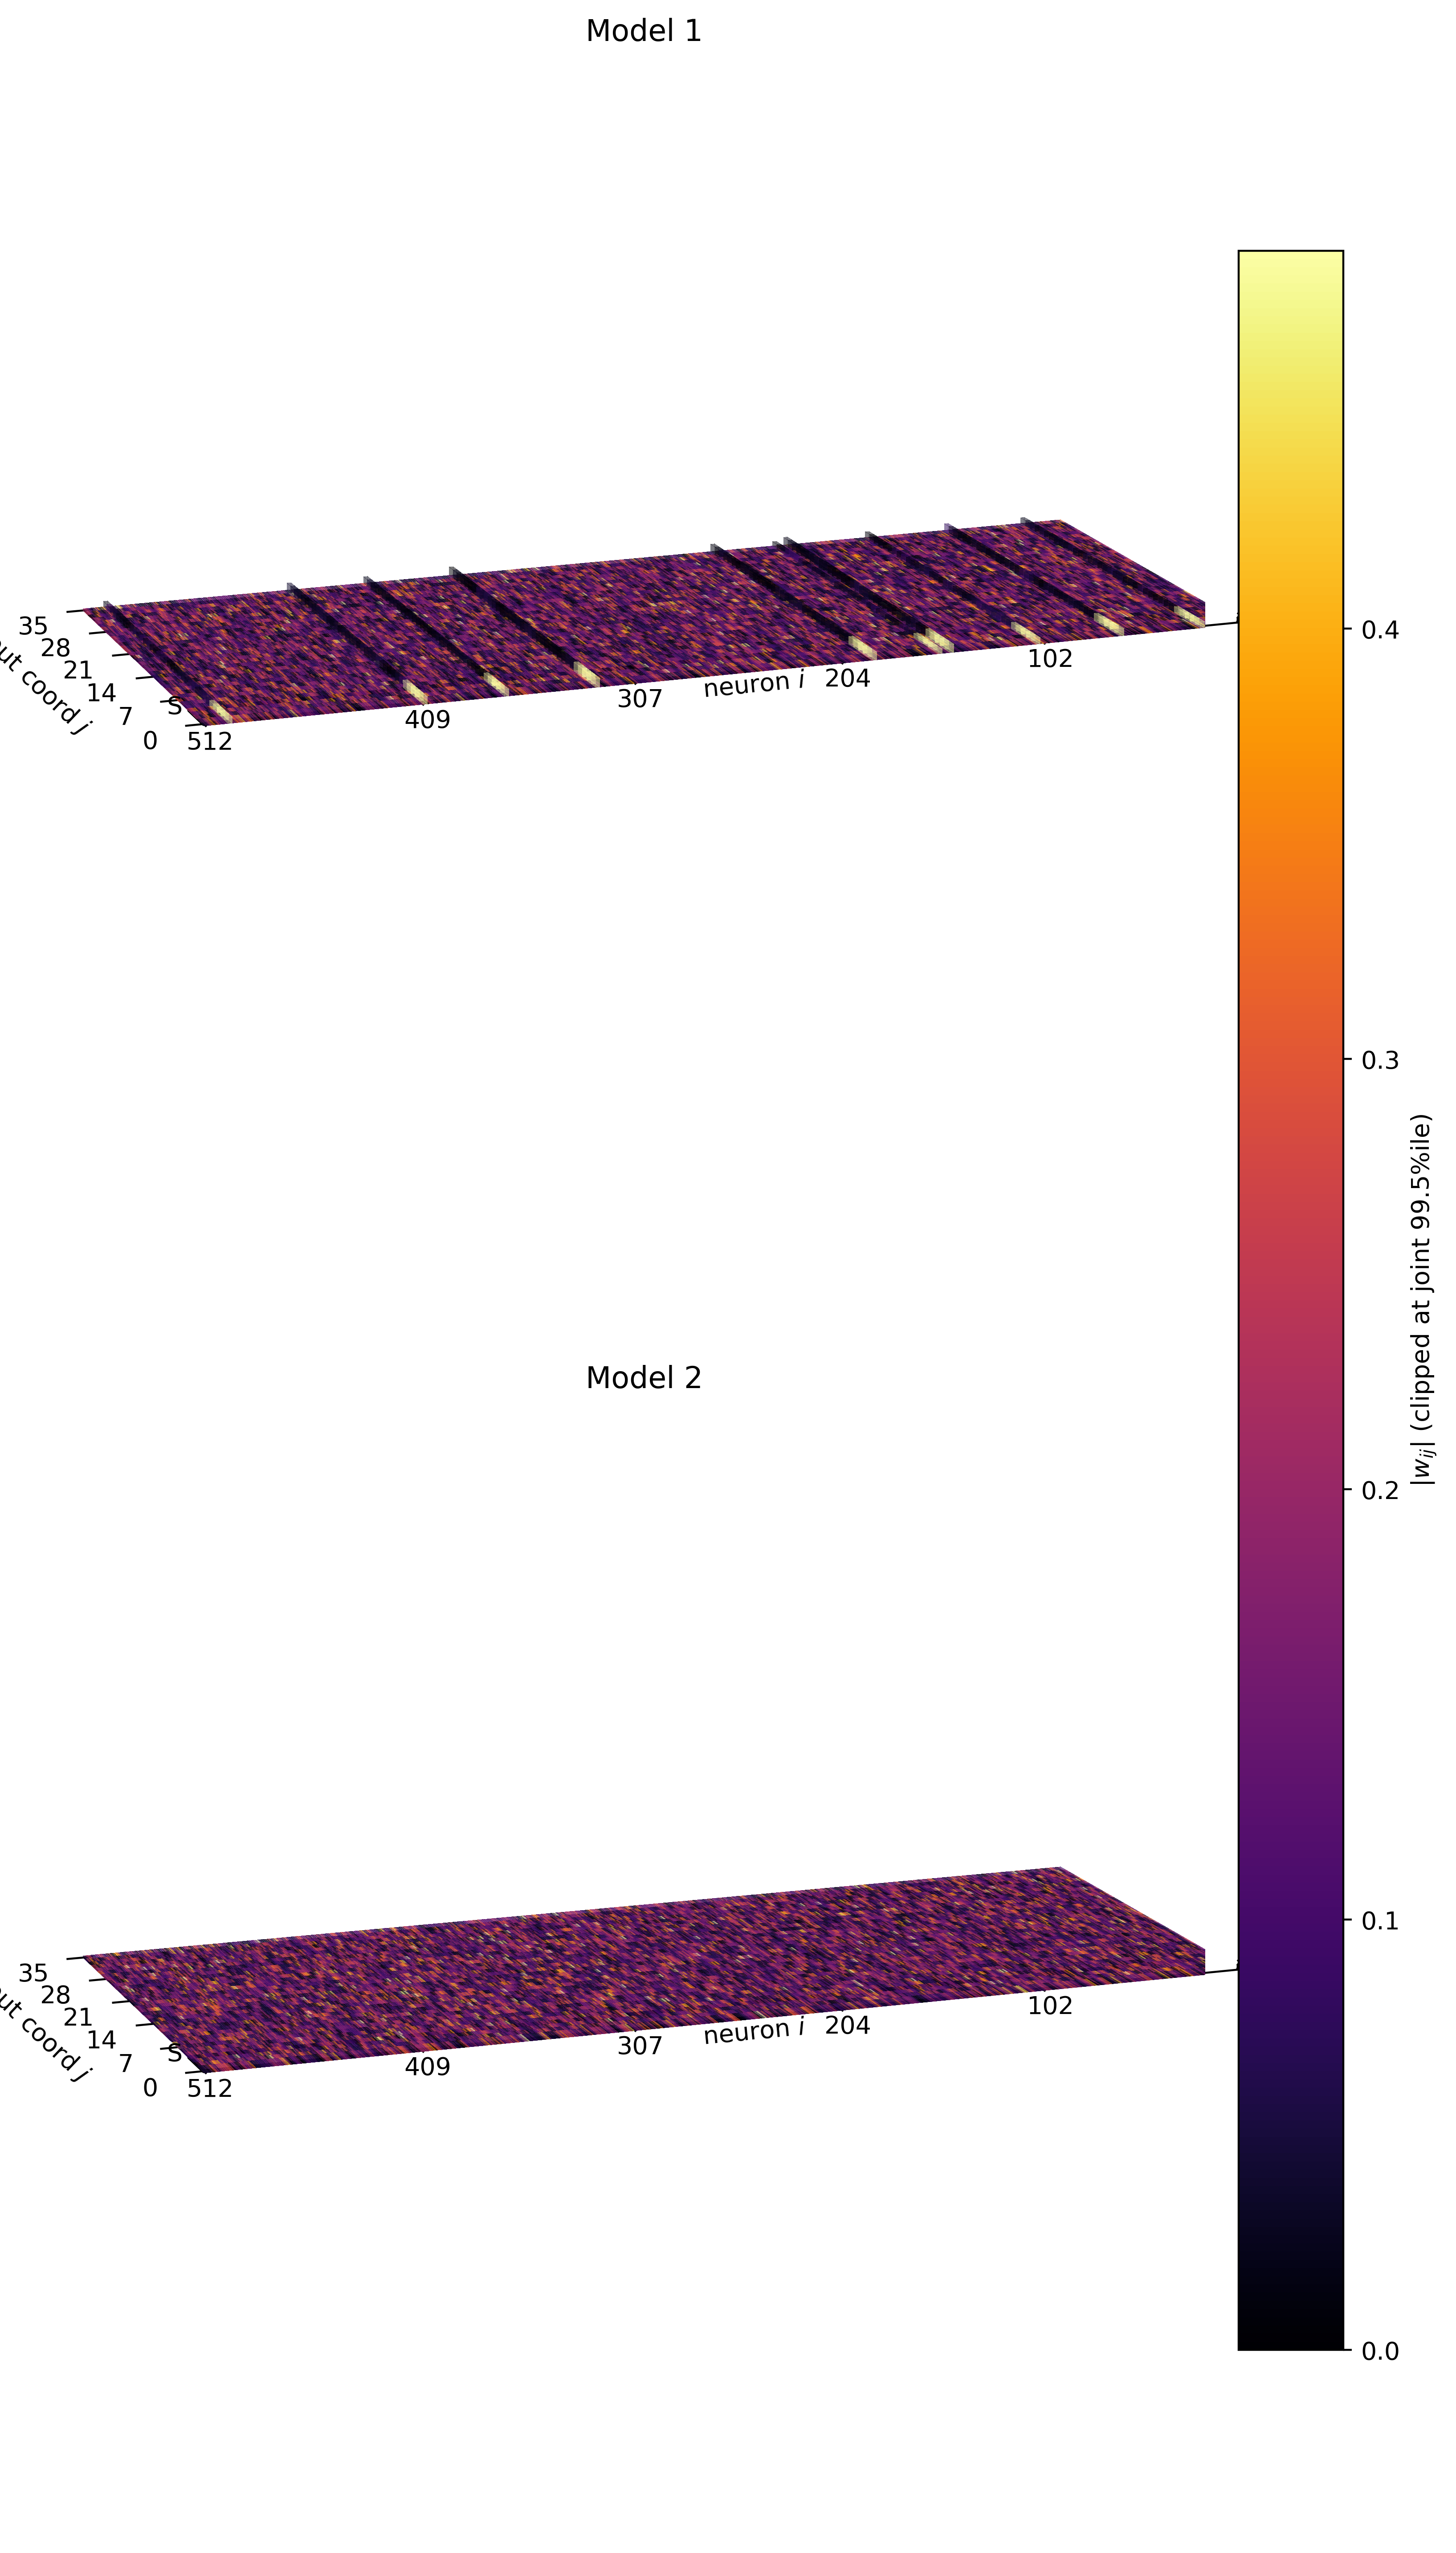

In [3]:
# --- 3D cuboid pillars: two-figure stack with shared colormap/colorbar AND shared m_S height (SVG) ---
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize, LinearSegmentedColormap
from matplotlib.cm import ScalarMappable
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

# Keep text as real text in SVG (smaller files)
mpl.rcParams['svg.fonttype'] = 'none'

# ---------------- I/O ----------------
def load_WA_from_state_dict(path, map_location="cpu"):
    sd = torch.load(path, map_location=map_location)
    if isinstance(sd, dict) and 'w' in sd and 'a' in sd:
        W, a = sd['w'].detach().cpu(), sd['a'].detach().cpu()
    elif isinstance(sd, dict) and 'state_dict' in sd:
        st = sd['state_dict']; W, a = st['w'].detach().cpu(), st['a'].detach().cpu()
    else:
        keys = list(sd.keys())
        key_w = next(k for k in keys if k.endswith('w') and sd[k].ndim == 2)
        key_a = next(k for k in keys if k.endswith('a') and sd[k].ndim >= 1)
        W, a = sd[key_w].detach().cpu(), sd[key_a].detach().cpu()
    if a.ndim > 1:
        a = a.view(-1)
    return W, a

# --------------- utils ----------------
def _sorted_unique_ints(idxs, lo=0, hi=None):
    arr = np.array(list(idxs), dtype=np.int64).ravel()
    if hi is not None:
        arr = arr[(arr >= lo) & (arr < hi)]
    else:
        arr = arr[(arr >= lo)]
    return np.unique(arr)

def _sym_diff_indices(A, B, d=None):
    """Return sorted symmetric difference of two index collections (mod 2 in {±1})."""
    setA = set(int(x) for x in A) if A is not None else set()
    setB = set(int(x) for x in B) if B is not None else set()
    out = setA.symmetric_difference(setB)
    if d is not None:
        out = {i for i in out if 0 <= i < d}
    return np.array(sorted(out), dtype=np.int64)

def neuron_specialization_scores(W_np, a_np, S, mode="abs-sum"):
    d, N = W_np.shape
    S_idx = _sorted_unique_ints(S, lo=0, hi=d)
    if S_idx.size == 0:
        return np.abs(a_np)
    WS = W_np[S_idx, :]
    if mode == "abs-sum":
        return np.abs(a_np) * np.sum(np.abs(WS), axis=0)
    if mode == "signed-sum":
        return np.abs(a_np * np.sum(WS, axis=0))
    if mode == "l2":
        return np.abs(a_np) * np.sqrt(np.sum(WS * WS, axis=0))
    if mode == "a-only":
        return np.abs(a_np)
    raise ValueError("unknown mode")

def create_cuboid(x0, y0, z0, dx, dy, dz):
    v = [
        [x0,      y0,      z0],
        [x0+dx,   y0,      z0],
        [x0+dx,   y0+dy,   z0],
        [x0,      y0+dy,   z0],
        [x0,      y0,      z0+dz],
        [x0+dx,   y0,      z0+dz],
        [x0+dx,   y0+dy,   z0+dz],
        [x0,      y0+dy,   z0+dz],
    ]
    return [
        [v[0], v[1], v[5], v[4]],  # +x
        [v[2], v[3], v[7], v[6]],  # -x
        [v[0], v[3], v[7], v[4]],  # +y
        [v[1], v[2], v[6], v[5]],  # -y
        [v[0], v[1], v[2], v[3]],  # bottom
        [v[4], v[5], v[6], v[7]],  # top
    ]

def make_two_color_cmap(hex_left="#0000ff", hex_right="#ffcc00", name="twohex"):
    return LinearSegmentedColormap.from_list(name, [hex_left, hex_right])

# --- Walsh-like coefficient m_S heights (no a_i; optional extra I) ---
def _get_phi(phi):
    """Return an activation callable. Accepts a callable or one of:
       'relu', 'tanh', 'erf', 'sigmoid', 'gelu', 'identity'."""
    if callable(phi):
        return phi
    name = str(phi).lower()
    if name == "relu":
        return torch.relu
    if name == "tanh":
        return torch.tanh
    if name == "erf":
        return torch.erf
    if name == "sigmoid":
        return torch.sigmoid
    if name == "gelu":
        return F.gelu
    if name in ("identity", "linear"):
        return lambda x: x
    raise ValueError(f"unknown phi '{phi}'")

def estimate_walsh_mS(
    W, a, S, *,
    I=None,                         # NEW: optional extra index or index set; uses symmetric difference with S
    num_samples=131072,             # Monte Carlo samples over x in {±1}^d
    phi="relu",
    seed=0,
    device="cpu",
    batch_size=None,
):
    """
    Returns m_S(i) = E_x[ phi(w_i^T x) * chi_{S Δ I}(x) ] for each neuron i,
    where x ~ Rademacher^d (independent ±1). Note: NO multiply by a_i.
    If I is None, this reduces to E[phi(w_i^T x) * chi_S(x)].
    """
    W_t = torch.as_tensor(W, dtype=torch.float32, device=device)
    d, N = W_t.shape
    phi_fn = _get_phi(phi)

    # Indices for chi_{S Δ I}
    SDI_idx = _sym_diff_indices(S, I, d=d)
    SDI_idx_t = torch.as_tensor(SDI_idx, dtype=torch.long, device=device) if SDI_idx.size else None

    M = int(num_samples)
    bs = int(batch_size) if batch_size else M
    gen = torch.Generator(device=device)
    gen.manual_seed(int(seed))

    acc = torch.zeros(N, dtype=torch.float32, device=device)
    made = 0
    while made < M:
        m = min(bs, M - made)
        # Rademacher ±1
        X = torch.where(
            torch.rand((m, d), generator=gen, device=device) < 0.5,
            torch.tensor(-1.0, device=device),
            torch.tensor(1.0, device=device),
        )
        if SDI_idx_t is not None:
            chi = X.index_select(1, SDI_idx_t).prod(dim=1, keepdim=True)  # (m,1)
        else:
            chi = torch.ones((m, 1), device=device)

        dots = X @ W_t                      # (m, N)
        vals = phi_fn(dots) * chi           # (m, N), chi broadcasts
        acc += vals.sum(dim=0)              # sum over samples in this batch
        made += m

    mS = (acc / M)                          # NO a_i multiply
    return mS.detach().cpu().numpy()        # shape: (N,)

# --------------- core renderer (draws onto a given 3D axis) ----------------
def draw_W_cuboids_on_axis(
    ax,
    W, a, S,
    *,
    norm, cmap,                            # shared across plots
    spec_mode="abs-sum",                   # (kept for API compat; unused for heights now)
    height_percentile=99.0,
    height_scale=25.0,
    alpha=0.35,
    # ground geometry
    cell_size_x=3.0,
    cell_size_y=0.5,
    width_frac_x=2.0,
    width_frac_y=2.0,
    edgecolor="black",
    linewidth=0.05,
    elev=55, azim=160,
    axis_index_ticks=True,
    title=None,
    # --- SVG friendliness ---
    rasterize_cuboids=True,        # rasterize heavy geometry into the SVG
    rasterize_dpi=300,             # effective resolution for rasterized layer
    antialiased=False,             # reduce SVG verbosity a bit
    # --- MC settings for m_S (only used if precomputed_mS_abs is None) ---
    phi="relu",
    num_mc_samples=131072,
    mc_seed=0,
    mc_batch_size=None,
    I=None,                        # NEW: extra index set for chi_{S Δ I}
    # --- NEW: allow overriding the Y extent so both figures share the same y-axis
    y_max_override=None,
    # --- NEW: share m_S scaling across plots ---
    precomputed_mS_abs=None,            # if provided, use these |m_S(i)| directly
    height_denom_override=None,         # if provided, divide by this instead of percentile per-plot
    z_max_override=None,                # if provided, fix the z-limit (shared across axes)
    # --- NEW: log z-axis support ---
    use_log_z=False,
    z_min_override=None,                # lower z limit if using log scale
    z_base_override=None,               # base z0 for pillars if using log scale
):
    # arrays
    W_np = W.detach().cpu().numpy() if torch.is_tensor(W) else np.asarray(W)
    a_np = a.detach().cpu().numpy() if torch.is_tensor(a) else np.asarray(a).reshape(-1)
    d, N = W_np.shape
    absW = np.abs(W_np)

    # --- heights: |m_S(i)| with NO a_i and NO log transform here ---
    if precomputed_mS_abs is None:
        mS = estimate_walsh_mS(
            W_np, a_np, S,
            I=I,
            num_samples=num_mc_samples,
            phi=phi, seed=mc_seed, device="cpu",
            batch_size=mc_batch_size,
        )
        z_raw = np.abs(mS)
    else:
        z_raw = np.asarray(precomputed_mS_abs).reshape(-1)

    if height_denom_override is not None:
        denom = float(height_denom_override)
    else:
        denom = max(np.percentile(z_raw, height_percentile), 1e-12)

    z_heights = height_scale * (z_raw / denom)

    # pillar footprint
    px = float(cell_size_x) * float(width_frac_x)
    py = float(cell_size_y) * float(width_frac_y)

    js = np.arange(d)
    is_ = np.arange(N)

    ax.view_init(elev=elev, azim=azim)

    # Determine z-base and limits
    if use_log_z:
        pos = z_heights[z_heights > 0]
        min_pos = float(np.min(pos)) if pos.size else 1e-12
        z_base = float(z_base_override) if z_base_override is not None else max(1e-12, 0.5 * min_pos)
        Zmin = float(z_min_override) if z_min_override is not None else z_base
    else:
        z_base = 0.0
        Zmin = 0.0

    # build all cuboids
    all_faces, face_colors = [], []
    for i in is_:
        z = float(z_heights[i])
        if z < 1e-12:
            continue
        y_cell0 = i * cell_size_y
        y0 = y_cell0 + (cell_size_y - py) / 2.0
        for j in js:
            x_cell0 = j * cell_size_x
            x0 = x_cell0 + (cell_size_x - px) / 2.0
            faces = create_cuboid(x0, y0, z_base, px, py, z)
            all_faces.extend(faces)
            rgba = list(cmap(norm(absW[j, i]))); rgba[3] = alpha
            face_colors.extend([rgba] * 6)

    coll = Poly3DCollection(
        all_faces,
        facecolors=face_colors,
        edgecolors=edgecolor,
        linewidths=linewidth,
        antialiased=antialiased,
    )
    if rasterize_cuboids:
        # This turns the entire collection into a single embedded bitmap in the SVG.
        coll.set_rasterized(True)
    ax.add_collection3d(coll)

    # remove all panes / grids
    for p in (ax.xaxis.pane, ax.yaxis.pane, ax.zaxis.pane):
        p.set_visible(False)
    ax.grid(False)

    # limits in *physical* units
    Xmax = d * cell_size_x
    Ymax_local = N * cell_size_y
    Ymax = float(y_max_override) if (y_max_override is not None) else Ymax_local
    if z_max_override is not None:
        Zmax = float(z_max_override)
    else:
        Zmax = max(z_base + (np.max(z_heights) if len(z_heights) else 0.0), 1.0) * (1.1 if not use_log_z else 1.0)

    ax.set_xlim(0, Xmax)
    ax.set_ylim(0, Ymax)
    if use_log_z:
        ax.set_zscale('log')
        # ensure valid log limits
        Zmin = max(Zmin, 1e-12)
        Zmax = max(Zmax, Zmin * 10.0)
        ax.set_zlim(Zmin, Zmax)
    else:
        ax.set_zlim(0, Zmax)

    ax.set_box_aspect([Xmax, Ymax, Zmax])

    # labels
    if title:
        ax.set_title(title, pad=10)
    ax.set_xlabel("input coord $j$")
    ax.set_ylabel("neuron $i$")
    #ax.set_zlabel(r"$|m_S^{(i)}|=\big|\mathbb{E}_x[\phi(w_i^\top x)\,\chi_{S\Delta I}(x)]\big|$")

    # re-label ticks as indices
    if axis_index_ticks:
        xt = np.linspace(0, Xmax, 6)
        ax.set_xticks(xt)
        ax.set_xticklabels((xt / cell_size_x).astype(int))
        yt = np.linspace(0, Ymax, 6)
        ax.set_yticks(yt)
        ax.set_yticklabels((yt / cell_size_y).astype(int))

    # bracket S on ground
    S_idx = _sorted_unique_ints(S, lo=0, hi=d)
    if S_idx.size:
        j0, j1 = int(S_idx.min()), int(S_idx.max())
        x0, x1 = j0 * cell_size_x, (j1 + 1) * cell_size_x
        ax.plot([x0, x1, x1, x0, x0],
                [0,   0,  Ymax, Ymax, 0],
                [z_base, z_base, z_base, z_base, z_base], color='k', linewidth=1.6)
        ax.text((x0 + x1) / 2.0, Ymax + 0.02 * Ymax, z_base,
                "S", ha="center", va="bottom")

    # If rasterizing, set figure DPI to control embedded image resolution
    if rasterize_cuboids:
        plt.gcf().set_dpi(rasterize_dpi)

# --------------- convenience wrapper: single or two models with shared colorbar + shared m_S heights ---------------
def plot_one_or_two_models(
    model1, S, *,
    model2=None,
    # colormap & normalization
    cmap_name="inferno",         # default back to inferno
    hex_left=None, hex_right=None,  # set both to use a 2-hex gradient instead
    vmax_percentile=99.5,
    # rendering (passed to draw function)
    spec_mode="abs-sum",
    height_percentile=99.0,       # used only if height_denom_override is not provided
    height_scale=25.0,
    alpha=0.35,
    cell_size_x=3.0,
    cell_size_y=0.5,
    width_frac_x=2.0,
    width_frac_y=2.0,
    edgecolor='black',
    linewidth=0.05,
    elev=55, azim=160,
    axis_index_ticks=True,
    # SVG friendliness
    rasterize_cuboids=True,
    rasterize_dpi=300,
    # figure options
    figsize=(12, 18),
    save_svg_path=None,
    save_svgz=False,            # write compressed SVG (.svgz)
    # --- m_S estimation controls (optional) ---
    phi="relu",
    num_mc_samples=131072,
    mc_seed=0,
    mc_batch_size=None,
    # --- NEW: optional extra I for chi_{S Δ I}
    extra_I=None,
    # --- NEW: toggle log z-axis globally
    log_z_axis=False,
):
    """model1, model2: either (W, a) tuple or a filepath to load.

    CHANGE: m_S pillar heights are now shared across subplots by computing a
    single joint percentile denominator from |m_S| across all provided models,
    and a single shared Z limit. Heights are based on
    m_S^{(i)} = E[phi(w_i^T x) * chi_{S Δ I}(x)] (no a_i).
    """
    # Load tensors
    if isinstance(model1, str):
        W1, a1 = load_WA_from_state_dict(model1)
        title1 = "Model 1"
    else:
        W1, a1 = model1
        title1 = "Model 1"

    W2 = a2 = None
    if model2 is not None:
        if isinstance(model2, str):
            W2, a2 = load_WA_from_state_dict(model2)
            title2 = "Model 2"
        else:
            W2, a2 = model2
            title2 = "Model 2"

    # Colormap + normalization from joint |W|
    if hex_left is not None and hex_right is not None:
        cmap = make_two_color_cmap(hex_left, hex_right)
    else:
        cmap = plt.get_cmap(cmap_name)

    absW1 = np.abs(W1.detach().cpu().numpy())
    if W2 is not None:
        absW2 = np.abs(W2.detach().cpu().numpy())
        joint_W = np.concatenate([absW1.ravel(), absW2.ravel()])
    else:
        joint_W = absW1.ravel()

    vmax = np.percentile(joint_W, vmax_percentile) if joint_W.size else 1.0
    if not np.isfinite(vmax) or vmax <= 0:
        vmax = 1.0
    norm = Normalize(0.0, float(vmax))

    # --- ensure both plots use the SAME y-axis extent ---
    N1 = W1.shape[1]
    if W2 is not None:
        N2 = W2.shape[1]
        Ymax_common = max(N1, N2) * cell_size_y
    else:
        Ymax_common = N1 * cell_size_y

    # === precompute m_S for each model and share the *same* height scaling ===
    mS1 = estimate_walsh_mS(
        W1, a1, S,
        I=extra_I,
        num_samples=num_mc_samples,
        phi=phi, seed=mc_seed, device="cpu",
        batch_size=mc_batch_size,
    )
    abs_mS1 = np.abs(mS1)

    if W2 is not None:
        mS2 = estimate_walsh_mS(
            W2, a2, S,
            I=extra_I,
            num_samples=num_mc_samples,
            phi=phi, seed=mc_seed, device="cpu",
            batch_size=mc_batch_size,
        )
        abs_mS2 = np.abs(mS2)
        joint_mS = np.concatenate([abs_mS1, abs_mS2])
    else:
        abs_mS2 = None
        joint_mS = abs_mS1

    # Joint denominator for height scaling
    denom_joint = max(np.percentile(joint_mS, height_percentile), 1e-12)

    # Shared Z limit so the axes are directly comparable (linear-space max)
    max_joint_abs_mS = float(np.max(joint_mS)) if joint_mS.size else 0.0
    Zmax_common = (height_scale * (max_joint_abs_mS / denom_joint) * 1.1) if max_joint_abs_mS > 0 else 1.0

    # If using log z, choose a common positive base and lower limit
    if log_z_axis:
        # compute min positive *height* across both models after scaling
        def min_pos_scaled(arr):
            pos = arr[arr > 0]
            return float(np.min(height_scale * (pos / denom_joint))) if pos.size else 1e-12
        min_pos1 = min_pos_scaled(abs_mS1)
        min_pos2 = min_pos_scaled(abs_mS2) if abs_mS2 is not None else np.inf
        min_pos_common = min(min_pos1, min_pos2)
        z_base_common = max(1e-12, 0.5 * (min_pos_common if np.isfinite(min_pos_common) else 1e-12))
        Zmin_common = z_base_common
    else:
        z_base_common = None
        Zmin_common = None

    # Figure and axes
    if W2 is None:
        fig = plt.figure(figsize=(figsize[0], figsize[1] / 2))
        ax1 = fig.add_subplot(111, projection='3d')
        draw_W_cuboids_on_axis(
            ax1, W1, a1, S,
            norm=norm, cmap=cmap,
            spec_mode=spec_mode,
            height_percentile=height_percentile,
            height_scale=height_scale,
            alpha=alpha,
            cell_size_x=cell_size_x, cell_size_y=cell_size_y,
            width_frac_x=width_frac_x, width_frac_y=width_frac_y,
            edgecolor=edgecolor, linewidth=linewidth,
            elev=elev, azim=azim,
            axis_index_ticks=axis_index_ticks,
            title="Model 1",
            rasterize_cuboids=rasterize_cuboids,
            rasterize_dpi=rasterize_dpi,
            # enforce shared y extent
            y_max_override=Ymax_common,
            # shared height scaling
            precomputed_mS_abs=abs_mS1,
            height_denom_override=denom_joint,
            z_max_override=Zmax_common,
            # log z handling
            use_log_z=log_z_axis,
            z_min_override=Zmin_common,
            z_base_override=z_base_common,
            # pass extra I for completeness (unused when precomputed is provided)
            I=extra_I,
        )
        axes = [ax1]
    else:
        fig = plt.figure(figsize=figsize)
        gs = fig.add_gridspec(nrows=2, ncols=1, height_ratios=[1, 1])
        ax1 = fig.add_subplot(gs[0, 0], projection='3d')
        ax2 = fig.add_subplot(gs[1, 0], projection='3d')

        draw_W_cuboids_on_axis(
            ax1, W1, a1, S,
            norm=norm, cmap=cmap,
            spec_mode=spec_mode,
            height_percentile=height_percentile,
            height_scale=height_scale,
            alpha=alpha,
            cell_size_x=cell_size_x, cell_size_y=cell_size_y,
            width_frac_x=width_frac_x, width_frac_y=width_frac_y,
            edgecolor=edgecolor, linewidth=linewidth,
            elev=elev, azim=azim,
            axis_index_ticks=axis_index_ticks,
            title=title1,
            rasterize_cuboids=rasterize_cuboids,
            rasterize_dpi=rasterize_dpi,
            # shared y extent and m_S scaling
            y_max_override=Ymax_common,
            precomputed_mS_abs=abs_mS1,
            height_denom_override=denom_joint,
            z_max_override=Zmax_common,
            # log z handling
            use_log_z=log_z_axis,
            z_min_override=Zmin_common,
            z_base_override=z_base_common,
            I=extra_I,
        )
        draw_W_cuboids_on_axis(
            ax2, W2, a2, S,
            norm=norm, cmap=cmap,
            spec_mode=spec_mode,
            height_percentile=height_percentile,
            height_scale=height_scale,
            alpha=alpha,
            cell_size_x=cell_size_x, cell_size_y=cell_size_y,
            width_frac_x=width_frac_x, width_frac_y=width_frac_y,
            edgecolor=edgecolor, linewidth=linewidth,
            elev=elev, azim=azim,
            axis_index_ticks=axis_index_ticks,
            title=title2,
            rasterize_cuboids=rasterize_cuboids,
            rasterize_dpi=rasterize_dpi,
            # shared y extent and m_S scaling
            y_max_override=Ymax_common,
            precomputed_mS_abs=abs_mS2,
            height_denom_override=denom_joint,
            z_max_override=Zmax_common,
            # log z handling
            use_log_z=log_z_axis,
            z_min_override=Zmin_common,
            z_base_override=z_base_common,
            I=extra_I,
        )
        axes = [ax1, ax2]

    # Single shared colorbar (escape {ij} for .format)
    sm = ScalarMappable(norm=norm, cmap=cmap); sm.set_array([])
    cbar = fig.colorbar(sm, ax=axes, shrink=0.85, pad=0.02)
    cbar.set_label(r"$|w_{{ij}}|$ (clipped at joint {}%ile)".format(vmax_percentile))

    plt.tight_layout()
    if save_svg_path:
        if save_svgz_path := (save_svg_path + "z" if save_svgz and not save_svg_path.endswith("z") else
                              save_svg_path if not save_svgz else save_svg_path):
            fmt = "svgz" if save_svgz else "svg"
            fig.savefig(save_svgz_path, format=fmt, dpi=rasterize_dpi,
                        bbox_inches="tight", facecolor="white")
    plt.show()
    return fig

# ------------------------ Example usage --------------------------------------
if __name__ == "__main__":
    MODEL_FILE_1 = "/home/goring/mean_field_langevin/Langevin_training/results_paper1/d35_k4_lrdecay_5e-3test2/d35_k4/final_model_P_10000_d_35_k_4_exp_2_kappa_0.005000_eta0_2.000000e-03_etaf_5.000000e-04_gamma_0.500000.pt"
    MODEL_FILE_2 = "/home/goring/mean_field_langevin/Langevin_training/results_paper1/d35_k4_lrdecay_5e-3test2/d35_k4/final_model_P_10_d_35_k_4_exp_2_kappa_0.005000_eta0_2.000000e-03_etaf_5.000000e-04_gamma_0.500000.pt"
    S = [0, 1, 2, 3]

    # NEW: choose an extra index set I to multiply in (uses symmetric difference with S).
    # For a single coordinate I=j, set EXTRA_I = [j]. To disable, set to None.
    EXTRA_I = None  # e.g., [5] to compute E[phi(w_i^T x) * x_5 * chi_S(x)]

    # NEW: single boolean to log the z-axis (shared across both subplots)
    LOG_Z_AXIS = True  # set True to use a log z-axis

    SAVE_SVG = "/home/goring/mean_field_langevin/plots/plots/sgld_W_cuboids2.svg"

    plot_one_or_two_models(
        MODEL_FILE_1, S,
        model2=MODEL_FILE_2,
        cmap_name="inferno",
        vmax_percentile=99.5,
        spec_mode="abs-sum",
        height_percentile=99,
        height_scale=0.05,
        alpha=0.3,
        cell_size_x=3.0,
        cell_size_y=0.5,
        width_frac_x=2.0,
        width_frac_y=2.0,
        edgecolor='None',        # drop edges: much smaller SVG
        linewidth=0.0,
        elev=15, azim=160,
        axis_index_ticks=True,
        figsize=(12, 18),
        save_svg_path=SAVE_SVG,
        save_svgz=False,          # write compressed SVG (.svgz)
        rasterize_cuboids=True,   # embed cuboids as a bitmap
        rasterize_dpi=400,        # adjust for quality/size tradeoff
        # m_S estimation controls (optional)
        phi="relu",               # activation φ used in m_S
        num_mc_samples=131072,    # Monte Carlo samples over x ~ {±1}^d
        mc_seed=0,                # reproducibility
        mc_batch_size=None,       # set to e.g. 16384 if memory is tight
        # NEW options:
        extra_I=EXTRA_I,          # pass the extra index set I (uses S Δ I)
        log_z_axis=LOG_Z_AXIS,    # toggle true log z-axis
    )


/tmp/ipykernel_100762/2435212634.py:501: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipykernel_100762/2435212634.py:501: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


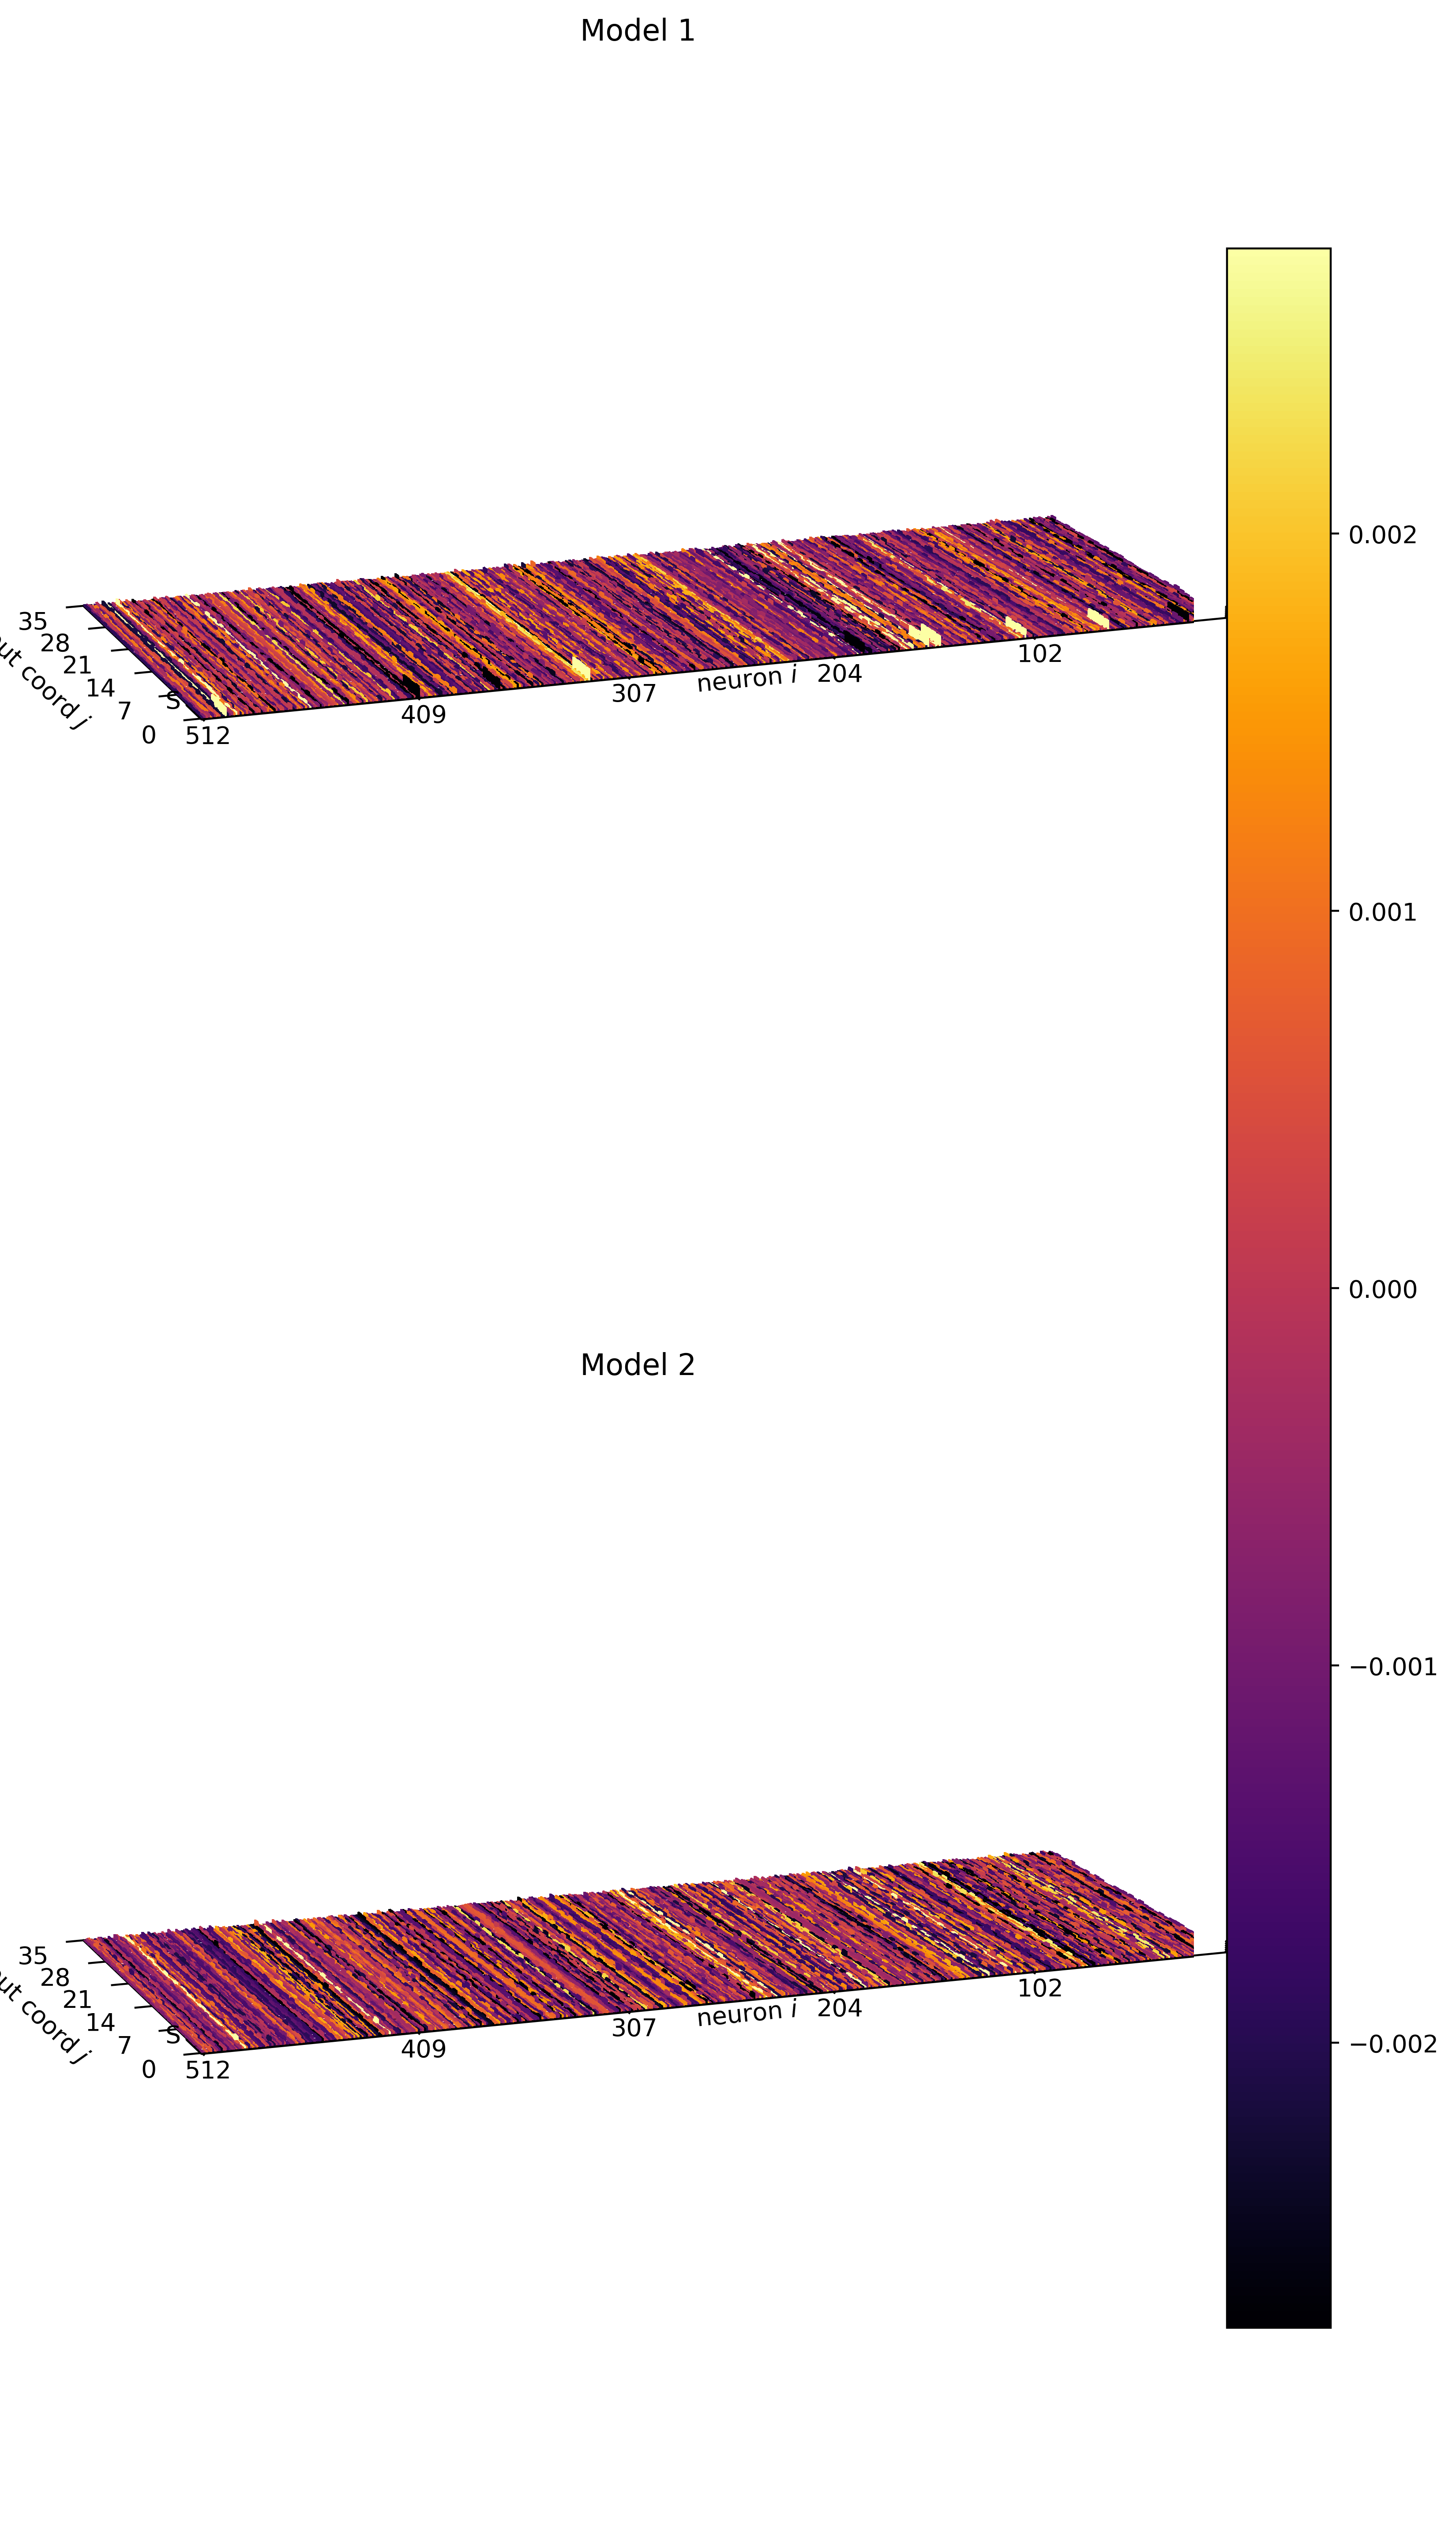

In [1]:
# --- 3D cuboid pillars: two-figure stack with shared colorbar (E[...]) AND shared |W| height (SVG) ---
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize, LinearSegmentedColormap, TwoSlopeNorm
from matplotlib.cm import ScalarMappable
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

# Keep text as real text in SVG (smaller files)
mpl.rcParams['svg.fonttype'] = 'none'

# ---------------- I/O ----------------
def load_WA_from_state_dict(path, map_location="cpu"):
    sd = torch.load(path, map_location=map_location)
    if isinstance(sd, dict) and 'w' in sd and 'a' in sd:
        W, a = sd['w'].detach().cpu(), sd['a'].detach().cpu()
    elif isinstance(sd, dict) and 'state_dict' in sd:
        st = sd['state_dict']; W, a = st['w'].detach().cpu(), st['a'].detach().cpu()
    else:
        keys = list(sd.keys())
        key_w = next(k for k in keys if k.endswith('w') and sd[k].ndim == 2)
        key_a = next(k for k in keys if k.endswith('a') and sd[k].ndim >= 1)
        W, a = sd[key_w].detach().cpu(), sd[key_a].detach().cpu()
    if a.ndim > 1:
        a = a.view(-1)
    return W, a

# --------------- utils ----------------
def _sorted_unique_ints(idxs, lo=0, hi=None):
    arr = np.array(list(idxs), dtype=np.int64).ravel()
    if hi is not None:
        arr = arr[(arr >= lo) & (arr < hi)]
    else:
        arr = arr[(arr >= lo)]
    return np.unique(arr)

def create_cuboid(x0, y0, z0, dx, dy, dz):
    v = [
        [x0,      y0,      z0],
        [x0+dx,   y0,      z0],
        [x0+dx,   y0+dy,   z0],
        [x0,      y0+dy,   z0],
        [x0,      y0,      z0+dz],
        [x0+dx,   y0,      z0+dz],
        [x0+dx,   y0+dy,   z0+dz],
        [x0,      y0+dy,   z0+dz],
    ]
    return [
        [v[0], v[1], v[5], v[4]],  # +x
        [v[2], v[3], v[7], v[6]],  # -x
        [v[0], v[3], v[7], v[4]],  # +y
        [v[1], v[2], v[6], v[5]],  # -y
        [v[0], v[1], v[2], v[3]],  # bottom
        [v[4], v[5], v[6], v[7]],  # top
    ]

def make_two_color_cmap(hex_left="#0000ff", hex_right="#ffcc00", name="twohex"):
    return LinearSegmentedColormap.from_list(name, [hex_left, hex_right])

# --- E[phi(w_i^T x) chi_S(x)] per neuron (signed) ---
def _get_phi(phi):
    """Return an activation callable. Accepts a callable or one of:
       'relu', 'tanh', 'erf', 'sigmoid', 'gelu', 'identity'."""
    if callable(phi):
        return phi
    name = str(phi).lower()
    if name == "relu":
        return torch.relu
    if name == "tanh":
        return torch.tanh
    if name == "erf":
        return torch.erf
    if name == "sigmoid":
        return torch.sigmoid
    if name == "gelu":
        return F.gelu
    if name in ("identity", "linear"):
        return lambda x: x
    raise ValueError(f"unknown phi '{phi}'")

def estimate_walsh_mS(
    W, a, S, *,
    num_samples=131072,         # Monte Carlo samples over x in {±1}^d
    phi="relu",
    seed=0,
    device="cpu",
    batch_size=None,
):
    """
    Returns m_S(i) = E_x[ phi(w_i^T x) * chi_S(x) ] for each neuron i (NO a_i).
    x ~ Rademacher^d (independent ±1), chi_S(x)=∏_{j∈S} x_j.
    """
    W_t = torch.as_tensor(W, dtype=torch.float32, device=device)
    d, N = W_t.shape
    S_idx = _sorted_unique_ints(S, lo=0, hi=d)
    S_idx_t = torch.as_tensor(S_idx, dtype=torch.long, device=device) if S_idx.size else None
    phi_fn = _get_phi(phi)

    M = int(num_samples)
    bs = int(batch_size) if batch_size else M
    gen = torch.Generator(device=device)
    gen.manual_seed(int(seed))

    acc = torch.zeros(N, dtype=torch.float32, device=device)
    made = 0
    while made < M:
        m = min(bs, M - made)
        # Rademacher ±1
        X = torch.where(
            torch.rand((m, d), generator=gen, device=device) < 0.5,
            torch.tensor(-1.0, device=device),
            torch.tensor(1.0, device=device),
        )
        if S_idx_t is not None:
            chi = X.index_select(1, S_idx_t).prod(dim=1, keepdim=True)  # (m,1)
        else:
            chi = torch.ones((m, 1), device=device)

        dots = X @ W_t                      # (m, N)
        vals = phi_fn(dots) * chi           # (m, N), chi broadcasts
        acc += vals.sum(dim=0)              # sum over samples in this batch
        made += m

    mS = (acc / M)                          # NO a_i multiply
    return mS.detach().cpu().numpy()        # shape: (N,)

# --------------- core renderer (draws onto a given 3D axis) ----------------
def draw_W_cuboids_on_axis(
    ax,
    W, a, S,
    *,
    norm, cmap,                            # --- color normalization for m_S (diverging)
    # heights (from |W|)
    height_percentile=99.0,                # used if height_denom_override is None
    height_scale=25.0,
    alpha=0.35,
    # ground geometry
    cell_size_x=3.0,
    cell_size_y=0.5,
    width_frac_x=2.0,
    width_frac_y=2.0,
    edgecolor="black",
    linewidth=0.05,
    elev=55, azim=160,
    axis_index_ticks=True,
    title=None,
    # --- SVG friendliness ---
    rasterize_cuboids=True,
    rasterize_dpi=300,
    antialiased=False,
    # --- MC settings for m_S (only used if precomputed_mS_signed is None) ---
    phi="relu",
    num_mc_samples=131072,
    mc_seed=0,
    mc_batch_size=None,
    # --- y extent sharing ---
    y_max_override=None,
    # --- shared scaling overrides ---
    precomputed_mS_signed=None,       # if provided, color uses these m_S(i) directly (signed)
    height_denom_override=None,       # if provided, divide |w_ji| by this (shared across axes)
    z_max_override=None,              # shared z limit
    # --- log z-axis support ---
    use_log_z=False,
    z_min_override=None,              # for log
    z_base_override=None,             # for log
):
    # arrays
    W_np = W.detach().cpu().numpy() if torch.is_tensor(W) else np.asarray(W)
    d, N = W_np.shape
    absW = np.abs(W_np)               # shape (d, N)

    # --- color field: m_S(i) signed ---
    if precomputed_mS_signed is None:
        mS = estimate_walsh_mS(
            W_np, None, S,
            num_samples=num_mc_samples,
            phi=phi, seed=mc_seed, device="cpu",
            batch_size=mc_batch_size,
        )
    else:
        mS = np.asarray(precomputed_mS_signed).reshape(-1)

    # --- heights from |w_ji| ---
    if height_denom_override is not None:
        denom = float(height_denom_override)
    else:
        denom = max(np.percentile(absW, height_percentile), 1e-12)
    z_heights = height_scale * (absW / denom)  # shape (d, N)

    # pillar footprint
    px = float(cell_size_x) * float(width_frac_x)
    py = float(cell_size_y) * float(width_frac_y)

    js = np.arange(d)
    is_ = np.arange(N)

    ax.view_init(elev=elev, azim=azim)

    # Determine z-base and limits
    zmax_here = float(z_heights.max()) if z_heights.size else 1.0
    if use_log_z:
        pos = z_heights[z_heights > 0]
        min_pos = float(np.min(pos)) if pos.size else 1e-12
        z_base = float(z_base_override) if z_base_override is not None else max(1e-12, 0.5 * min_pos)
        Zmin = float(z_min_override) if z_min_override is not None else z_base
        Zmax = float(z_max_override) if z_max_override is not None else max(z_base + zmax_here, z_base * 10.0)
    else:
        z_base = 0.0
        Zmin = 0.0
        Zmax = float(z_max_override) if z_max_override is not None else max(zmax_here * 1.1, 1.0)

    # build all cuboids
    all_faces, face_colors = [], []
    for i in is_:
        # one neuron color across all its (j, i) cuboids
        rgba_i = list(cmap(norm(float(mS[i]))))
        rgba_i[3] = alpha
        y_cell0 = i * cell_size_y
        y0 = y_cell0 + (cell_size_y - py) / 2.0
        for j in js:
            z = float(z_heights[j, i])
            if z <= 1e-12:
                continue
            x_cell0 = j * cell_size_x
            x0 = x_cell0 + (cell_size_x - px) / 2.0
            faces = create_cuboid(x0, y0, z_base, px, py, z)
            all_faces.extend(faces)
            face_colors.extend([rgba_i] * 6)

    coll = Poly3DCollection(
        all_faces,
        facecolors=face_colors,
        edgecolors=edgecolor,
        linewidths=linewidth,
        antialiased=antialiased,
    )
    if rasterize_cuboids:
        # This turns the entire collection into a single embedded bitmap in the SVG.
        coll.set_rasterized(True)
    ax.add_collection3d(coll)

    # remove all panes / grids
    for p in (ax.xaxis.pane, ax.yaxis.pane, ax.zaxis.pane):
        p.set_visible(False)
    ax.grid(False)

    # limits in *physical* units
    Xmax = d * cell_size_x
    Ymax_local = N * cell_size_y
    Ymax = float(y_max_override) if (y_max_override is not None) else Ymax_local

    ax.set_xlim(0, Xmax)
    ax.set_ylim(0, Ymax)
    if use_log_z:
        ax.set_zscale('log')
        Zmin = max(Zmin, 1e-12)
        Zmax = max(Zmax, Zmin * 10.0)
        ax.set_zlim(Zmin, Zmax)
    else:
        ax.set_zlim(0, Zmax)
    ax.set_box_aspect([Xmax, Ymax, Zmax])

    # labels
    if title:
        ax.set_title(title, pad=10)
    ax.set_xlabel("input coord $j$")
    ax.set_ylabel("neuron $i$")
    #ax.set_zlabel(r"$|w_{ji}|$ (scaled)")

    # re-label ticks as indices
    if axis_index_ticks:
        xt = np.linspace(0, Xmax, 6)
        ax.set_xticks(xt)
        ax.set_xticklabels((xt / cell_size_x).astype(int))
        yt = np.linspace(0, Ymax, 6)
        ax.set_yticks(yt)
        ax.set_yticklabels((yt / cell_size_y).astype(int))

    # bracket S on ground
    S_idx = _sorted_unique_ints(S, lo=0, hi=d)
    if S_idx.size:
        j0, j1 = int(S_idx.min()), int(S_idx.max())
        x0, x1 = j0 * cell_size_x, (j1 + 1) * cell_size_x
        ax.plot([x0, x1, x1, x0, x0],
                [0,   0,  Ymax, Ymax, 0],
                [z_base, z_base, z_base, z_base, z_base], color='k', linewidth=1.6)
        ax.text((x0 + x1) / 2.0, Ymax + 0.02 * Ymax, z_base,
                "S", ha="center", va="bottom")

    # If rasterizing, set figure DPI to control embedded image resolution
    if rasterize_cuboids:
        plt.gcf().set_dpi(rasterize_dpi)

# --------------- convenience wrapper: two models with shared colorbar + shared |W| heights ---------------
def plot_one_or_two_models(
    model1, S, *,
    model2=None,
    # colormap for signed m_S
    cmap_name="coolwarm",
    vmax_percentile=99.5,        # percentile for |m_S| color clipping (diverging, centered at 0)
    # height scaling from |W|
    height_percentile=99.0,      # percentile for |W| scaling (higher => shorter pillars overall)
    height_scale=25.0,
    alpha=0.35,
    cell_size_x=3.0,
    cell_size_y=0.5,
    width_frac_x=2.0,
    width_frac_y=2.0,
    edgecolor='black',
    linewidth=0.05,
    elev=55, azim=160,
    axis_index_ticks=True,
    # SVG friendliness
    rasterize_cuboids=True,
    rasterize_dpi=300,
    # figure options
    figsize=(12, 18),
    save_svg_path=None,
    save_svgz=False,            # write compressed SVG (.svgz)
    # --- MC controls for E[...] ---
    phi="relu",
    num_mc_samples=131072,
    mc_seed=0,
    mc_batch_size=None,
    # --- log z-axis toggle ---
    log_z_axis=False,
):
    """model1, model2: either (W, a) tuple or a filepath to load.

    Color per neuron: m_S^{(i)} = E[phi(w_i^T x) * chi_S(x)] (signed; diverging colormap).
    Height per (j,i): |w_{ji}| (scaled by joint percentile).
    """
    # Load tensors
    if isinstance(model1, str):
        W1, a1 = load_WA_from_state_dict(model1)
        title1 = "Model 1"
    else:
        W1, a1 = model1
        title1 = "Model 1"

    W2 = a2 = None
    if model2 is not None:
        if isinstance(model2, str):
            W2, a2 = load_WA_from_state_dict(model2)
            title2 = "Model 2"
        else:
            W2, a2 = model2
            title2 = "Model 2"

    # --- joint |W| for height scaling ---
    absW1 = np.abs(W1.detach().cpu().numpy())
    if W2 is not None:
        absW2 = np.abs(W2.detach().cpu().numpy())
        joint_absW = np.concatenate([absW1.ravel(), absW2.ravel()])
    else:
        joint_absW = absW1.ravel()
    denom_height = max(np.percentile(joint_absW, height_percentile), 1e-12)
    max_absW = float(np.max(joint_absW)) if joint_absW.size else 0.0
    Zmax_common = (height_scale * (max_absW / denom_height) * 1.1) if max_absW > 0 else 1.0

    # If using log z, choose a common positive base and lower limit based on |W|
    if log_z_axis:
        def min_pos_scaled(arr):
            arrp = arr[arr > 0]
            return float(np.min(height_scale * (arrp / denom_height))) if arrp.size else 1e-12
        min_pos1 = min_pos_scaled(absW1)
        min_pos2 = min_pos_scaled(absW2) if model2 is not None else np.inf
        min_pos_common = min(min_pos1, min_pos2)
        z_base_common = max(1e-12, 0.5 * (min_pos_common if np.isfinite(min_pos_common) else 1e-12))
        Zmin_common = z_base_common
    else:
        z_base_common = None
        Zmin_common = None

    # --- compute m_S for color (signed), and build joint for color normalization ---
    mS1 = estimate_walsh_mS(
        W1, a1, S,
        num_samples=num_mc_samples,
        phi=phi, seed=mc_seed, device="cpu",
        batch_size=mc_batch_size,
    )
    if W2 is not None:
        mS2 = estimate_walsh_mS(
            W2, a2, S,
            num_samples=num_mc_samples,
            phi=phi, seed=mc_seed, device="cpu",
            batch_size=mc_batch_size,
        )
        joint_abs_mS = np.concatenate([np.abs(mS1), np.abs(mS2)])
    else:
        mS2 = None
        joint_abs_mS = np.abs(mS1)

    # --- diverging color normalization centered at 0 (shared across subplots) ---
    v_abs = np.percentile(joint_abs_mS, vmax_percentile) if joint_abs_mS.size else 1.0
    if not np.isfinite(v_abs) or v_abs <= 0:
        v_abs = 1.0
    color_norm = TwoSlopeNorm(vmin=-float(v_abs), vcenter=0.0, vmax=float(v_abs))
    cmap = plt.get_cmap(cmap_name)

    # --- ensure both plots use the SAME y-axis extent ---
    N1 = W1.shape[1]
    if W2 is not None:
        N2 = W2.shape[1]
        Ymax_common = max(N1, N2) * cell_size_y
    else:
        Ymax_common = N1 * cell_size_y

    # Figure and axes
    if W2 is None:
        fig = plt.figure(figsize=(figsize[0], figsize[1] / 2))
        ax1 = fig.add_subplot(111, projection='3d')
        draw_W_cuboids_on_axis(
            ax1, W1, a1, S,
            norm=color_norm, cmap=cmap,
            height_percentile=height_percentile,
            height_scale=height_scale,
            alpha=alpha,
            cell_size_x=cell_size_x, cell_size_y=cell_size_y,
            width_frac_x=width_frac_x, width_frac_y=width_frac_y,
            edgecolor=edgecolor, linewidth=linewidth,
            elev=elev, azim=azim,
            axis_index_ticks=axis_index_ticks,
            title=title1,
            rasterize_cuboids=rasterize_cuboids,
            rasterize_dpi=rasterize_dpi,
            # shared y extent and |W| scaling
            y_max_override=Ymax_common,
            precomputed_mS_signed=mS1,
            height_denom_override=denom_height,
            z_max_override=Zmax_common,
            # log z handling
            use_log_z=log_z_axis,
            z_min_override=Zmin_common,
            z_base_override=z_base_common,
            # MC args (unused because precomputed provided, but pass for API completeness)
            phi=phi, num_mc_samples=num_mc_samples, mc_seed=mc_seed, mc_batch_size=mc_batch_size,
        )
        axes = [ax1]
    else:
        fig = plt.figure(figsize=figsize)
        gs = fig.add_gridspec(nrows=2, ncols=1, height_ratios=[1, 1])
        ax1 = fig.add_subplot(gs[0, 0], projection='3d')
        ax2 = fig.add_subplot(gs[1, 0], projection='3d')

        draw_W_cuboids_on_axis(
            ax1, W1, a1, S,
            norm=color_norm, cmap=cmap,
            height_percentile=height_percentile,
            height_scale=height_scale,
            alpha=alpha,
            cell_size_x=cell_size_x, cell_size_y=cell_size_y,
            width_frac_x=width_frac_x, width_frac_y=width_frac_y,
            edgecolor=edgecolor, linewidth=linewidth,
            elev=elev, azim=azim,
            axis_index_ticks=axis_index_ticks,
            title=title1,
            rasterize_cuboids=rasterize_cuboids,
            rasterize_dpi=rasterize_dpi,
            y_max_override=Ymax_common,
            precomputed_mS_signed=mS1,
            height_denom_override=denom_height,
            z_max_override=Zmax_common,
            use_log_z=log_z_axis,
            z_min_override=Zmin_common,
            z_base_override=z_base_common,
            phi=phi, num_mc_samples=num_mc_samples, mc_seed=mc_seed, mc_batch_size=mc_batch_size,
        )
        draw_W_cuboids_on_axis(
            ax2, W2, a2, S,
            norm=color_norm, cmap=cmap,
            height_percentile=height_percentile,
            height_scale=height_scale,
            alpha=alpha,
            cell_size_x=cell_size_x, cell_size_y=cell_size_y,
            width_frac_x=width_frac_x, width_frac_y=width_frac_y,
            edgecolor=edgecolor, linewidth=linewidth,
            elev=elev, azim=azim,
            axis_index_ticks=axis_index_ticks,
            title=title2,
            rasterize_cuboids=rasterize_cuboids,
            rasterize_dpi=rasterize_dpi,
            y_max_override=Ymax_common,
            precomputed_mS_signed=mS2,
            height_denom_override=denom_height,
            z_max_override=Zmax_common,
            use_log_z=log_z_axis,
            z_min_override=Zmin_common,
            z_base_override=z_base_common,
            phi=phi, num_mc_samples=num_mc_samples, mc_seed=mc_seed, mc_batch_size=mc_batch_size,
        )
        axes = [ax1, ax2]

    # Single shared colorbar for signed m_S
    sm = ScalarMappable(norm=color_norm, cmap=cmap); sm.set_array([])
    cbar = fig.colorbar(sm, ax=axes, shrink=0.85, pad=0.02)
    #cbar.set_label(r"$\mathbb{E}\!\left[\phi(w_i^\top x)\,\chi_S(x)\right]$ (clipped at joint {}%ile of $|m_S|$)".format(vmax_percentile))

    plt.tight_layout()
    if save_svg_path:
        if save_svgz_path := (save_svg_path + "z" if save_svgz and not save_svg_path.endswith("z") else
                              save_svg_path if not save_svgz else save_svg_path):
            fmt = "svgz" if save_svgz else "svg"
            fig.savefig(save_svgz_path, format=fmt, dpi=rasterize_dpi,
                        bbox_inches="tight", facecolor="white")
    plt.show()
    return fig

# ------------------------ Example usage --------------------------------------
if __name__ == "__main__":
    MODEL_FILE_1 = "/home/goring/mean_field_langevin/Langevin_training/results_paper1/d35_k4_lrdecay_5e-3test2/d35_k4/final_model_P_10000_d_35_k_4_exp_2_kappa_0.005000_eta0_2.000000e-03_etaf_5.000000e-04_gamma_0.500000.pt"
    MODEL_FILE_2 = "/home/goring/mean_field_langevin/Langevin_training/results_paper1/d35_k4_lrdecay_5e-3test2/d35_k_4/final_model_P_10_d_35_k_4_exp_2_kappa_0.005000_eta0_2.000000e-03_etaf_5.000000e-04_gamma_0.500000.pt".replace("k_4/", "k4/")  # fix path if needed
    S = [0, 1, 2, 3]

    # Toggle a true log z-axis (heights are |W| so always nonnegative)
    LOG_Z_AXIS = False

    SAVE_SVG = "/home/goring/mean_field_langevin/plots/plots/sgld_W_cuboids2.svg"

    plot_one_or_two_models(
        MODEL_FILE_1, S,
        model2=MODEL_FILE_2,
        # color (signed expectation)
        cmap_name="inferno",
        vmax_percentile=94.0,   # color clipping for |m_S|
        # height (|W|)
        height_percentile=99.0, # scaling denom from joint |W|
        height_scale=1.0,
        alpha=1.0,
        cell_size_x=3.0,
        cell_size_y=0.5,
        width_frac_x=0.8,
        width_frac_y=0.8,
        edgecolor='None',        # drop edges: much smaller SVG
        linewidth=2.5,
        elev=15, azim=160,
        axis_index_ticks=True,
        figsize=(12, 18),
        save_svg_path=SAVE_SVG,
        save_svgz=False,          # write compressed SVG (.svgz)
        rasterize_cuboids=True,   # embed cuboids as a bitmap
        rasterize_dpi=400,        # quality/size tradeoff
        # MC settings for the color field
        phi="relu",
        num_mc_samples=131072,
        mc_seed=0,
        mc_batch_size=None,
        # log z
        log_z_axis=LOG_Z_AXIS,
    )
